# 01 Ã¢â‚¬â€ SQL Analysis

## Healthcare Claims & Revenue Analytics

This notebook contains reproducible SQL-based analysis of the cleaned
CMS DE-SynPUF Sample 1 healthcare claims data.

### Objectives

- Analyze overall claim volume and service mix.
- Analyze claim payment patterns.
- Compare inpatient and outpatient financial performance.
- Analyze provider claim volume and payments.
- Identify high-utilization beneficiaries.
- Analyze high-payment beneficiaries.
- Examine inpatient length of stay and payment relationships.
- Identify payment-integrity investigation signals.
- Produce business-oriented SQL outputs suitable for Power BI and reporting.

### Source Data

SQL analysis will use the cleaned datasets stored in:

`02_Cleaned_Data/`

Primary datasets:

- `Inpatient_Claims_Cleaned.csv`
- `Outpatient_Claims_Cleaned.csv`
- `Beneficiary_2008_Cleaned.csv`
- `Beneficiary_2009_Cleaned.csv`
- `Beneficiary_2010_Cleaned.csv`

### Analytical Principle

All SQL analysis will use the definitions established during:

1. Data Validation
2. Data Quality Assessment
3. Data Cleaning
4. Exploratory Data Analysis

No analytical result should contradict the established data-quality findings.

### Important Limitations

- CMS DE-SynPUF is synthetic Medicare claims data.
- No dedicated claim denial-status field was identified.
- Zero payment must not be interpreted as a denial.
- Negative payments should be investigated rather than automatically removed.
- Provider identifiers are synthetic.
- SQL findings are descriptive and do not establish causality.

### SQL Environment

DuckDB will be used for SQL analysis because it can query CSV files directly
and is well suited to analytical workloads on local healthcare datasets.

In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "duckdb"
])

0

In [2]:
import duckdb
print("DuckDB version:", duckdb.__version__)

DuckDB version: 1.5.6


In [3]:
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics"
)

CLEANED_DIR = PROJECT_ROOT / "02_Cleaned_Data"
SQL_DIR = PROJECT_ROOT / "04_SQL"

print("Project root:")
print(PROJECT_ROOT)

print("\nCleaned data directory:")
print(CLEANED_DIR)

print("\nSQL directory:")
print(SQL_DIR)

print("\nCleaned data directory exists:", CLEANED_DIR.exists())
print("SQL directory exists:", SQL_DIR.exists())

Project root:
C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics

Cleaned data directory:
C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\02_Cleaned_Data

SQL directory:
C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL

Cleaned data directory exists: True
SQL directory exists: True


In [4]:
files = {
    "beneficiary_2008": CLEANED_DIR / "Beneficiary_2008_Cleaned.csv",
    "beneficiary_2009": CLEANED_DIR / "Beneficiary_2009_Cleaned.csv",
    "beneficiary_2010": CLEANED_DIR / "Beneficiary_2010_Cleaned.csv",
    "inpatient": CLEANED_DIR / "Inpatient_Claims_Cleaned.csv",
    "outpatient": CLEANED_DIR / "Outpatient_Claims_Cleaned.csv",
}

for name, path in files.items():
    print(f"{name}:")
    print(f"  {path}")
    print(f"  Exists: {path.exists()}")

beneficiary_2008:
  C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\02_Cleaned_Data\Beneficiary_2008_Cleaned.csv
  Exists: True
beneficiary_2009:
  C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\02_Cleaned_Data\Beneficiary_2009_Cleaned.csv
  Exists: True
beneficiary_2010:
  C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\02_Cleaned_Data\Beneficiary_2010_Cleaned.csv
  Exists: True
inpatient:
  C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\02_Cleaned_Data\Inpatient_Claims_Cleaned.csv
  Exists: True
outpatient:
  C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\02_Cleaned_Data\Outpatient_Claims_Cleaned.csv
  Exists: True


In [5]:
import duckdb

DB_PATH = SQL_DIR / "healthcare_claims_analytics.duckdb"

con = duckdb.connect(str(DB_PATH))

print("Database created/connected:")
print(DB_PATH)

print("\nDatabase exists:", DB_PATH.exists())

Database created/connected:
C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\healthcare_claims_analytics.duckdb

Database exists: True


In [6]:
result = con.execute("""
    SELECT
        'Healthcare Claims & Revenue Analytics' AS Project,
        current_date AS Analysis_Date
""").fetchdf()

display(result)

,Project,Analysis_Date
0,Healthcare Claims & Revenue Analytics,2026-10-06


In [7]:
con.execute(f"""
    CREATE OR REPLACE TABLE inpatient_claims AS
    SELECT *
    FROM read_csv(
        '{files["inpatient"].as_posix()}',
        header = true,
        auto_detect = true
    )
""")

inpatient_count = con.execute("""
    SELECT COUNT(*) AS row_count
    FROM inpatient_claims
""").fetchdf()

display(inpatient_count)

,row_count
0,66773


In [8]:
con.execute(f"""
    CREATE OR REPLACE TABLE outpatient_claims AS
    SELECT *
    FROM read_csv(
        '{files["outpatient"].as_posix()}',
        header = true,
        auto_detect = true,
        all_varchar = true
    )
""")

outpatient_count = con.execute("""
    SELECT COUNT(*) AS row_count
    FROM outpatient_claims
""").fetchdf()

display(outpatient_count)

,row_count
0,790790


In [9]:
claims_table_check = con.execute("""
    SELECT
        'Inpatient' AS claim_type,
        COUNT(*) AS claim_count
    FROM inpatient_claims

    UNION ALL

    SELECT
        'Outpatient' AS claim_type,
        COUNT(*) AS claim_count
    FROM outpatient_claims
""").fetchdf()

display(claims_table_check)

,claim_type,claim_count
0,Inpatient,66773
1,Outpatient,790790


In [10]:
for year in ["2008", "2009", "2010"]:
    table_name = f"beneficiary_{year}"
    file_key = f"beneficiary_{year}"

    con.execute(f"""
        CREATE OR REPLACE TABLE {table_name} AS
        SELECT *
        FROM read_csv(
            '{files[file_key].as_posix()}',
            header = true,
            auto_detect = true,
            all_varchar = true
        )
    """)

beneficiary_table_check = con.execute("""
    SELECT
        '2008' AS year,
        COUNT(*) AS beneficiary_count
    FROM beneficiary_2008

    UNION ALL

    SELECT
        '2009' AS year,
        COUNT(*) AS beneficiary_count
    FROM beneficiary_2009

    UNION ALL

    SELECT
        '2010' AS year,
        COUNT(*) AS beneficiary_count
    FROM beneficiary_2010
""").fetchdf()

display(beneficiary_table_check)

,year,beneficiary_count
0,2008,116352
1,2009,114538
2,2010,112754


In [11]:
tables = con.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").fetchdf()

display(tables)

,table_name
0,beneficiary_2008
1,beneficiary_2009
2,beneficiary_2010
3,claims_all
4,inpatient_claims
5,outpatient_claims


In [12]:
inpatient_schema = con.execute("""
    DESCRIBE inpatient_claims
""").fetchdf()

display(inpatient_schema)

,column_name,column_type,null,key,default,extra
0,DESYNPUF_ID,VARCHAR,YES,None,None,None
1,CLM_ID,BIGINT,YES,None,None,None
2,SEGMENT,BIGINT,YES,None,None,None
3,CLM_FROM_DT,DATE,YES,None,None,None
4,CLM_THRU_DT,DATE,YES,None,None,None
...,...,...,...,...,...,...
76,HCPCS_CD_41,VARCHAR,YES,None,None,None
77,HCPCS_CD_42,VARCHAR,YES,None,None,None
78,HCPCS_CD_43,VARCHAR,YES,None,None,None
79,HCPCS_CD_44,VARCHAR,YES,None,None,None


In [13]:
financial_schema = con.execute("""
    SELECT
        column_name,
        column_type
    FROM (
        DESCRIBE inpatient_claims
    )
    WHERE column_name IN (
        'CLM_PMT_AMT',
        'NCH_PRMRY_PYR_CLM_PD_AMT',
        'CLM_UTLZTN_DAY_CNT'
    )
    ORDER BY column_name
""").fetchdf()

display(financial_schema)

,column_name,column_type
0,CLM_PMT_AMT,DOUBLE
1,CLM_UTLZTN_DAY_CNT,DOUBLE
2,NCH_PRMRY_PYR_CLM_PD_AMT,DOUBLE


In [14]:
con.execute("""
    CREATE OR REPLACE VIEW claims_all AS

    SELECT
        'Inpatient' AS claim_type,
        DESYNPUF_ID AS beneficiary_id,
        CAST(CLM_ID AS VARCHAR) AS claim_id,
        CAST(SEGMENT AS VARCHAR) AS segment,
        CLM_FROM_DT AS claim_from_date,
        CLM_THRU_DT AS claim_thru_date,
        PRVDR_NUM AS provider_id,
        CAST(CLM_PMT_AMT AS DOUBLE) AS payment,
        CAST(CLM_UTLZTN_DAY_CNT AS DOUBLE) AS utilization_days,
        CAST(ICD9_DGNS_CD_1 AS VARCHAR) AS primary_diagnosis
    FROM inpatient_claims

    UNION ALL

    SELECT
        'Outpatient' AS claim_type,
        DESYNPUF_ID AS beneficiary_id,
        CLM_ID AS claim_id,
        SEGMENT AS segment,
        TRY_CAST(CLM_FROM_DT AS DATE) AS claim_from_date,
        TRY_CAST(CLM_THRU_DT AS DATE) AS claim_thru_date,
        PRVDR_NUM AS provider_id,
        TRY_CAST(CLM_PMT_AMT AS DOUBLE) AS payment,
        NULL AS utilization_days,
        ICD9_DGNS_CD_1 AS primary_diagnosis
    FROM outpatient_claims
""")

view_check = con.execute("""
    SELECT
        claim_type,
        COUNT(*) AS claim_count,
        ROUND(SUM(payment), 2) AS total_payment
    FROM claims_all
    GROUP BY claim_type
    ORDER BY claim_type
""").fetchdf()

display(view_check)

,claim_type,claim_count,total_payment
0,Inpatient,66773,639260180.0
1,Outpatient,790790,224524710.0


In [15]:
beneficiary_summary = con.execute("""
    SELECT
        beneficiary_id,

        COUNT(*) AS claim_count,

        SUM(
            CASE
                WHEN claim_type = 'Inpatient'
                THEN 1
                ELSE 0
            END
        ) AS inpatient_claims,

        SUM(
            CASE
                WHEN claim_type = 'Outpatient'
                THEN 1
                ELSE 0
            END
        ) AS outpatient_claims,

        ROUND(
            SUM(payment),
            2
        ) AS total_payment,

        ROUND(
            AVG(payment),
            2
        ) AS average_payment_per_claim

    FROM claims_all

    WHERE beneficiary_id IS NOT NULL

    GROUP BY beneficiary_id
""").fetchdf()

display(beneficiary_summary.head(20))

,beneficiary_id,claim_count,inpatient_claims,outpatient_claims,total_payment,average_payment_per_claim
0,001AFA59A08ABBF1,14,3.0,11.0,35900.0,2564.29
1,002354398A00234E,11,1.0,10.0,13200.0,1200.00
2,00244B6D9AB50F9B,7,2.0,5.0,46830.0,6690.00
3,00292D3DBB23CE44,14,2.0,12.0,12600.0,900.00
4,002AB71D3224BE66,14,5.0,9.0,79850.0,5703.57
5,0045A5AFF076CBE6,21,1.0,20.0,20910.0,995.71
6,006C7FC30305A339,12,1.0,11.0,9720.0,810.00
7,007C99D466D0E3A6,4,2.0,2.0,8100.0,2025.00
8,0094AF69581046B7,16,2.0,14.0,17110.0,1069.38
9,00A6A2FA958A3703,7,1.0,6.0,11770.0,1681.43


In [16]:
beneficiary_summary_validation = con.execute("""
    SELECT
        COUNT(*) AS beneficiary_count,

        SUM(claim_count) AS total_claims,

        SUM(inpatient_claims) AS total_inpatient_claims,

        SUM(outpatient_claims) AS total_outpatient_claims,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment,

        SUM(
            CASE
                WHEN claim_count <= 0
                THEN 1
                ELSE 0
            END
        ) AS invalid_claim_count,

        SUM(
            CASE
                WHEN inpatient_claims + outpatient_claims <> claim_count
                THEN 1
                ELSE 0
            END
        ) AS service_mix_mismatch

    FROM beneficiary_summary
""").fetchdf()

display(beneficiary_summary_validation)

,beneficiary_count,total_claims,total_inpatient_claims,total_outpatient_claims,total_payment,invalid_claim_count,service_mix_mismatch
0,86738,857563.0,66773.0,790790.0,863784890.0,0.0,0.0


In [17]:
utilization_segments = con.execute("""
    WITH segmented AS (

        SELECT
            beneficiary_id,
            claim_count,
            total_payment,

            CASE
                WHEN claim_count BETWEEN 1 AND 4
                    THEN 'Low utilization'
                WHEN claim_count BETWEEN 5 AND 9
                    THEN 'Moderate utilization'
                WHEN claim_count BETWEEN 10 AND 26
                    THEN 'High utilization'
                WHEN claim_count >= 27
                    THEN 'Very high utilization'
            END AS utilization_segment

        FROM beneficiary_summary
    ),

    overall AS (
        SELECT
            COUNT(*) AS total_beneficiaries,
            SUM(claim_count) AS total_claims,
            SUM(total_payment) AS total_payment
        FROM segmented
    )

    SELECT
        s.utilization_segment,

        COUNT(*) AS beneficiary_count,

        SUM(s.claim_count) AS claim_count,

        ROUND(
            SUM(s.total_payment),
            2
        ) AS total_payment,

        ROUND(
            AVG(s.claim_count),
            2
        ) AS average_claims_per_beneficiary,

        ROUND(
            AVG(s.total_payment),
            2
        ) AS average_payment_per_beneficiary,

        ROUND(
            SUM(s.claim_count) * 100.0
            / MAX(o.total_claims),
            2
        ) AS claim_share_pct,

        ROUND(
            SUM(s.total_payment) * 100.0
            / MAX(o.total_payment),
            2
        ) AS payment_share_pct

    FROM segmented s
    CROSS JOIN overall o

    GROUP BY
        s.utilization_segment

    ORDER BY
        CASE s.utilization_segment
            WHEN 'Low utilization' THEN 1
            WHEN 'Moderate utilization' THEN 2
            WHEN 'High utilization' THEN 3
            WHEN 'Very high utilization' THEN 4
        END
""").fetchdf()

display(utilization_segments)

,utilization_segment,beneficiary_count,claim_count,total_payment,average_claims_per_beneficiary,average_payment_per_beneficiary,claim_share_pct,payment_share_pct
0,Low utilization,30356,68114.0,103982280.0,2.24,3425.43,7.94,12.04
1,Moderate utilization,20541,141211.0,152074560.0,6.87,7403.46,16.47,17.61
2,High utilization,31111,490864.0,427858730.0,15.78,13752.65,57.24,49.53
3,Very high utilization,4730,157374.0,179869320.0,33.27,38027.34,18.35,20.82


In [18]:
utilization_segment_validation = con.execute("""
    SELECT
        COUNT(*) AS segment_count,

        SUM(beneficiary_count) AS total_beneficiaries,

        SUM(claim_count) AS total_claims,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment,

        ROUND(
            SUM(claim_share_pct),
            2
        ) AS claim_share_sum_pct,

        ROUND(
            SUM(payment_share_pct),
            2
        ) AS payment_share_sum_pct

    FROM utilization_segments
""").fetchdf()

display(utilization_segment_validation)

,segment_count,total_beneficiaries,total_claims,total_payment,claim_share_sum_pct,payment_share_sum_pct
0,4,86738.0,857563.0,863784890.0,100.0,100.0


In [19]:
beneficiary_priority_segments = con.execute("""
    WITH threshold AS (

        SELECT
            QUANTILE_CONT(
                total_payment,
                0.95
            ) AS payment_95th_percentile

        FROM beneficiary_summary
    ),

    classified AS (

        SELECT
            b.beneficiary_id,
            b.claim_count,
            b.total_payment,

            CASE
                WHEN b.claim_count >= 27
                    THEN 'High utilization'
                ELSE 'Lower utilization'
            END AS utilization_group,

            CASE
                WHEN b.total_payment >= t.payment_95th_percentile
                    THEN 'High payment'
                ELSE 'Lower payment'
            END AS payment_group

        FROM beneficiary_summary b

        CROSS JOIN threshold t
    )

    SELECT
        utilization_group,
        payment_group,

        COUNT(*) AS beneficiary_count,

        SUM(claim_count) AS claim_count,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment,

        ROUND(
            AVG(claim_count),
            2
        ) AS average_claims_per_beneficiary,

        ROUND(
            AVG(total_payment),
            2
        ) AS average_payment_per_beneficiary

    FROM classified

    GROUP BY
        utilization_group,
        payment_group

    ORDER BY
        CASE utilization_group
            WHEN 'Lower utilization' THEN 1
            WHEN 'High utilization' THEN 2
        END,

        CASE payment_group
            WHEN 'Lower payment' THEN 1
            WHEN 'High payment' THEN 2
        END
""").fetchdf()

display(beneficiary_priority_segments)

,utilization_group,payment_group,beneficiary_count,claim_count,total_payment,average_claims_per_beneficiary,average_payment_per_beneficiary
0,Lower utilization,Lower payment,79225,659974.0,511110770.0,8.33,6451.38
1,Lower utilization,High payment,2783,40215.0,172804800.0,14.45,62092.99
2,High utilization,Lower payment,3176,98432.0,54462990.0,30.99,17148.30
3,High utilization,High payment,1554,58942.0,125406330.0,37.93,80699.05


In [20]:
priority_segment_validation = con.execute("""
    SELECT
        COUNT(*) AS segment_count,

        SUM(beneficiary_count) AS total_beneficiaries,

        SUM(claim_count) AS total_claims,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment

    FROM beneficiary_priority_segments
""").fetchdf()

display(priority_segment_validation)

,segment_count,total_beneficiaries,total_claims,total_payment
0,4,86738.0,857563.0,863784890.0


In [21]:
utilization_service_mix = con.execute("""
    WITH segmented_beneficiaries AS (

        SELECT
            beneficiary_id,

            CASE
                WHEN claim_count BETWEEN 1 AND 4
                    THEN 'Low utilization'
                WHEN claim_count BETWEEN 5 AND 9
                    THEN 'Moderate utilization'
                WHEN claim_count BETWEEN 10 AND 26
                    THEN 'High utilization'
                WHEN claim_count >= 27
                    THEN 'Very high utilization'
            END AS utilization_segment

        FROM beneficiary_summary
    ),

    service_summary AS (

        SELECT
            s.utilization_segment,
            c.claim_type,
            COUNT(*) AS claim_count,
            ROUND(
                SUM(c.payment),
                2
            ) AS total_payment

        FROM claims_all c

        INNER JOIN segmented_beneficiaries s
            ON c.beneficiary_id = s.beneficiary_id

        GROUP BY
            s.utilization_segment,
            c.claim_type
    ),

    segment_totals AS (

        SELECT
            utilization_segment,
            SUM(claim_count) AS segment_claims,
            SUM(total_payment) AS segment_payment

        FROM service_summary

        GROUP BY
            utilization_segment
    )

    SELECT
        s.utilization_segment,
        s.claim_type,
        s.claim_count,
        ROUND(
            s.claim_count * 100.0
            / t.segment_claims,
            2
        ) AS claim_share_pct,
        s.total_payment,
        ROUND(
            s.total_payment * 100.0
            / t.segment_payment,
            2
        ) AS payment_share_pct

    FROM service_summary s

    INNER JOIN segment_totals t
        ON s.utilization_segment = t.utilization_segment

    ORDER BY
        CASE s.utilization_segment
            WHEN 'Low utilization' THEN 1
            WHEN 'Moderate utilization' THEN 2
            WHEN 'High utilization' THEN 3
            WHEN 'Very high utilization' THEN 4
        END,

        CASE s.claim_type
            WHEN 'Inpatient' THEN 1
            WHEN 'Outpatient' THEN 2
        END
""").fetchdf()

display(utilization_service_mix)

,utilization_segment,claim_type,claim_count,claim_share_pct,total_payment,payment_share_pct
0,Low utilization,Inpatient,9079,13.33,88785640.0,85.39
1,Low utilization,Outpatient,59035,86.67,15196640.0,14.61
2,Moderate utilization,Inpatient,12662,8.97,123428670.0,81.16
3,Moderate utilization,Outpatient,128549,91.03,28645890.0,18.84
4,High utilization,Inpatient,34108,6.95,319748530.0,74.73
5,High utilization,Outpatient,456756,93.05,108110200.0,25.27
6,Very high utilization,Inpatient,10924,6.94,107297340.0,59.65
7,Very high utilization,Outpatient,146450,93.06,72571980.0,40.35


In [22]:
service_mix_validation = con.execute("""
    SELECT
        utilization_segment,

        SUM(claim_count) AS total_claims,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment,

        ROUND(
            SUM(claim_share_pct),
            2
        ) AS claim_share_sum_pct,

        ROUND(
            SUM(payment_share_pct),
            2
        ) AS payment_share_sum_pct

    FROM utilization_service_mix

    GROUP BY
        utilization_segment

    ORDER BY
        CASE utilization_segment
            WHEN 'Low utilization' THEN 1
            WHEN 'Moderate utilization' THEN 2
            WHEN 'High utilization' THEN 3
            WHEN 'Very high utilization' THEN 4
        END
""").fetchdf()

display(service_mix_validation)

,utilization_segment,total_claims,total_payment,claim_share_sum_pct,payment_share_sum_pct
0,Low utilization,68114.0,103982280.0,100.0,100.0
1,Moderate utilization,141211.0,152074560.0,100.0,100.0
2,High utilization,490864.0,427858730.0,100.0,100.0
3,Very high utilization,157374.0,179869320.0,100.0,100.0


In [23]:
inpatient_payment_profile = con.execute("""
    WITH beneficiary_service_summary AS (

        SELECT
            beneficiary_id,

            COUNT(*) AS total_claims,

            SUM(
                CASE
                    WHEN claim_type = 'Inpatient'
                    THEN 1
                    ELSE 0
                END
            ) AS inpatient_claims,

            SUM(
                CASE
                    WHEN claim_type = 'Outpatient'
                    THEN 1
                    ELSE 0
                END
            ) AS outpatient_claims,

            SUM(payment) AS total_payment,

            SUM(
                CASE
                    WHEN claim_type = 'Inpatient'
                    THEN payment
                    ELSE 0
                END
            ) AS inpatient_payment,

            SUM(
                CASE
                    WHEN claim_type = 'Outpatient'
                    THEN payment
                    ELSE 0
                END
            ) AS outpatient_payment

        FROM claims_all

        WHERE beneficiary_id IS NOT NULL

        GROUP BY beneficiary_id
    )

    SELECT
        beneficiary_id,
        total_claims,
        inpatient_claims,
        outpatient_claims,

        ROUND(
            total_payment,
            2
        ) AS total_payment,

        ROUND(
            inpatient_payment,
            2
        ) AS inpatient_payment,

        ROUND(
            outpatient_payment,
            2
        ) AS outpatient_payment,

        ROUND(
            inpatient_payment * 100.0
            / NULLIF(total_payment, 0),
            2
        ) AS inpatient_payment_share_pct

    FROM beneficiary_service_summary

    WHERE
        total_claims >= 5
        AND inpatient_payment > 0

    ORDER BY
        inpatient_payment_share_pct DESC,
        total_payment DESC

    LIMIT 20
""").fetchdf()

display(inpatient_payment_profile)

,beneficiary_id,total_claims,inpatient_claims,outpatient_claims,total_payment,inpatient_payment,outpatient_payment,inpatient_payment_share_pct
0,C092BE06E3B0CE59,7,7.0,0.0,148000.0,148000.0,0.0,100.00
1,A2439711FC1AEA1D,5,5.0,0.0,113000.0,113000.0,0.0,100.00
2,9EB307D53BEBF952,7,7.0,0.0,110000.0,110000.0,0.0,100.00
3,CA4261F139B89928,6,6.0,0.0,93000.0,93000.0,0.0,100.00
4,0F4EA63F00686338,5,5.0,0.0,84000.0,84000.0,0.0,100.00
5,4DEE2828F71CB0EE,6,6.0,0.0,77000.0,77000.0,0.0,100.00
6,80F1299DB608AB18,5,5.0,0.0,75000.0,75000.0,0.0,100.00
7,17ED228AD5D930EF,7,7.0,0.0,64000.0,64000.0,0.0,100.00
8,94F8860167F7FB4F,5,5.0,0.0,59000.0,59000.0,0.0,100.00
9,DC0A6ED8BAC9F8E3,6,6.0,0.0,59000.0,59000.0,0.0,100.00


In [24]:
payment_mix_segments = con.execute("""
    WITH beneficiary_service_summary AS (

        SELECT
            beneficiary_id,

            COUNT(*) AS total_claims,

            SUM(payment) AS total_payment,

            SUM(
                CASE
                    WHEN claim_type = 'Inpatient'
                    THEN payment
                    ELSE 0
                END
            ) AS inpatient_payment

        FROM claims_all

        WHERE beneficiary_id IS NOT NULL

        GROUP BY beneficiary_id
    ),

    classified AS (

        SELECT
            beneficiary_id,
            total_claims,
            total_payment,
            inpatient_payment,

            CASE
                WHEN inpatient_payment * 100.0
                     / NULLIF(total_payment, 0) >= 75
                    THEN 'Inpatient-dominant'

                WHEN inpatient_payment * 100.0
                     / NULLIF(total_payment, 0) >= 25
                    THEN 'Mixed'

                ELSE 'Outpatient-dominant'
            END AS payment_mix_segment

        FROM beneficiary_service_summary

        WHERE
            total_claims >= 5
            AND total_payment > 0
    )

    SELECT
        payment_mix_segment,

        COUNT(*) AS beneficiary_count,

        SUM(total_claims) AS claim_count,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment,

        ROUND(
            AVG(total_claims),
            2
        ) AS avg_claims_per_beneficiary,

        ROUND(
            AVG(total_payment),
            2
        ) AS avg_payment_per_beneficiary

    FROM classified

    GROUP BY
        payment_mix_segment

    ORDER BY
        CASE payment_mix_segment
            WHEN 'Inpatient-dominant' THEN 1
            WHEN 'Mixed' THEN 2
            WHEN 'Outpatient-dominant' THEN 3
        END
""").fetchdf()

display(payment_mix_segments)

,payment_mix_segment,beneficiary_count,claim_count,total_payment,avg_claims_per_beneficiary,avg_payment_per_beneficiary
0,Inpatient-dominant,19411,264672.0,496885310.0,13.64,25598.13
1,Mixed,9787,191713.0,168050260.0,19.59,17170.76
2,Outpatient-dominant,27183,333056.0,94867770.0,12.25,3489.97


In [25]:
payment_mix_validation = con.execute("""
    SELECT
        COUNT(*) AS segment_count,

        SUM(beneficiary_count) AS total_beneficiaries,

        SUM(claim_count) AS total_claims,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment

    FROM payment_mix_segments
""").fetchdf()

display(payment_mix_validation)

,segment_count,total_beneficiaries,total_claims,total_payment
0,3,56381.0,789441.0,759803340.0


In [26]:
payment_mix_population = con.execute("""
    WITH beneficiary_summary_base AS (

        SELECT
            beneficiary_id,
            claim_count,
            total_payment
        FROM beneficiary_summary
    )

    SELECT
        COUNT(*) AS total_beneficiaries,

        SUM(
            CASE
                WHEN claim_count >= 5
                     AND total_payment > 0
                THEN 1
                ELSE 0
            END
        ) AS included_beneficiaries,

        SUM(
            CASE
                WHEN claim_count < 5
                     OR total_payment <= 0
                THEN 1
                ELSE 0
            END
        ) AS excluded_beneficiaries,

        ROUND(
            SUM(
                CASE
                    WHEN claim_count >= 5
                         AND total_payment > 0
                    THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS included_share_pct,

        ROUND(
            SUM(
                CASE
                    WHEN claim_count < 5
                         OR total_payment <= 0
                    THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS excluded_share_pct

    FROM beneficiary_summary_base
""").fetchdf()

display(payment_mix_population)

,total_beneficiaries,included_beneficiaries,excluded_beneficiaries,included_share_pct,excluded_share_pct
0,86738,56381.0,30357.0,65.0,35.0


In [27]:
payment_mix_exclusion_reasons = con.execute("""
    SELECT
        CASE
            WHEN claim_count < 5
                 AND total_payment <= 0
                THEN 'Both: <5 claims and non-positive payment'

            WHEN claim_count < 5
                THEN 'Fewer than 5 claims'

            WHEN total_payment <= 0
                THEN 'Non-positive total payment'

            ELSE 'Included'
        END AS population_group,

        COUNT(*) AS beneficiary_count

    FROM beneficiary_summary

    GROUP BY
        population_group

    ORDER BY
        CASE population_group
            WHEN 'Included' THEN 1
            WHEN 'Fewer than 5 claims' THEN 2
            WHEN 'Non-positive total payment' THEN 3
            WHEN 'Both: <5 claims and non-positive payment' THEN 4
        END
""").fetchdf()

display(payment_mix_exclusion_reasons)

,population_group,beneficiary_count
0,Included,56381
1,Fewer than 5 claims,29888
2,Non-positive total payment,1
3,Both: <5 claims and non-positive payment,468


In [28]:
payment_mix_final = con.execute("""
    WITH totals AS (

        SELECT
            SUM(beneficiary_count) AS total_beneficiaries,
            SUM(claim_count) AS total_claims,
            SUM(total_payment) AS total_payment

        FROM payment_mix_segments
    )

    SELECT
        p.payment_mix_segment,

        p.beneficiary_count,

        ROUND(
            p.beneficiary_count * 100.0
            / t.total_beneficiaries,
            2
        ) AS beneficiary_share_pct,

        p.claim_count,

        ROUND(
            p.claim_count * 100.0
            / t.total_claims,
            2
        ) AS claim_share_pct,

        p.total_payment,

        ROUND(
            p.total_payment * 100.0
            / t.total_payment,
            2
        ) AS payment_share_pct,

        p.avg_claims_per_beneficiary,

        p.avg_payment_per_beneficiary

    FROM payment_mix_segments p

    CROSS JOIN totals t

    ORDER BY
        CASE p.payment_mix_segment
            WHEN 'Inpatient-dominant' THEN 1
            WHEN 'Mixed' THEN 2
            WHEN 'Outpatient-dominant' THEN 3
        END
""").fetchdf()

display(payment_mix_final)

,payment_mix_segment,beneficiary_count,beneficiary_share_pct,claim_count,claim_share_pct,total_payment,payment_share_pct,avg_claims_per_beneficiary,avg_payment_per_beneficiary
0,Inpatient-dominant,19411,34.43,264672.0,33.53,496885310.0,65.40,13.64,25598.13
1,Mixed,9787,17.36,191713.0,24.28,168050260.0,22.12,19.59,17170.76
2,Outpatient-dominant,27183,48.21,333056.0,42.19,94867770.0,12.49,12.25,3489.97


In [29]:
payment_mix_percentage_validation = con.execute("""
    SELECT
        ROUND(
            SUM(beneficiary_share_pct),
            2
        ) AS beneficiary_share_sum_pct,

        ROUND(
            SUM(claim_share_pct),
            2
        ) AS claim_share_sum_pct,

        ROUND(
            SUM(payment_share_pct),
            2
        ) AS payment_share_sum_pct

    FROM payment_mix_final
""").fetchdf()

display(payment_mix_percentage_validation)

,beneficiary_share_sum_pct,claim_share_sum_pct,payment_share_sum_pct
0,100.0,100.0,100.01


In [30]:
payment_mix_exact_validation = con.execute("""
    WITH totals AS (

        SELECT
            SUM(beneficiary_count) AS total_beneficiaries,
            SUM(claim_count) AS total_claims,
            SUM(total_payment) AS total_payment
        FROM payment_mix_segments
    )

    SELECT
        SUM(p.beneficiary_count) = t.total_beneficiaries
            AS beneficiaries_reconciled,

        SUM(p.claim_count) = t.total_claims
            AS claims_reconciled,

        SUM(p.total_payment) = t.total_payment
            AS payments_reconciled,

        SUM(p.beneficiary_count) AS segment_beneficiaries,
        t.total_beneficiaries,

        SUM(p.claim_count) AS segment_claims,
        t.total_claims,

        SUM(p.total_payment) AS segment_payment,
        t.total_payment

    FROM payment_mix_segments p

    CROSS JOIN totals t

    GROUP BY
        t.total_beneficiaries,
        t.total_claims,
        t.total_payment
""").fetchdf()

display(payment_mix_exact_validation)

,beneficiaries_reconciled,claims_reconciled,payments_reconciled,segment_beneficiaries,total_beneficiaries,segment_claims,total_claims,segment_payment,total_payment
0,True,True,True,56381.0,56381.0,789441.0,789441.0,759803340.0,759803340.0


In [31]:
beneficiary_financial_summary = con.execute("""
    SELECT
        COUNT(*) AS beneficiaries_with_claims,

        SUM(claim_count) AS total_claims,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment,

        ROUND(
            AVG(claim_count),
            2
        ) AS avg_claims_per_beneficiary,

        ROUND(
            AVG(total_payment),
            2
        ) AS avg_payment_per_beneficiary,

        ROUND(
            MEDIAN(total_payment),
            2
        ) AS median_payment_per_beneficiary,

        ROUND(
            QUANTILE_CONT(total_payment, 0.95),
            2
        ) AS p95_payment_per_beneficiary,

        MAX(claim_count) AS max_claims_per_beneficiary,

        ROUND(
            MAX(total_payment),
            2
        ) AS max_payment_per_beneficiary

    FROM beneficiary_summary
""").fetchdf()

display(beneficiary_financial_summary)

,beneficiaries_with_claims,total_claims,total_payment,avg_claims_per_beneficiary,avg_payment_per_beneficiary,median_payment_per_beneficiary,p95_payment_per_beneficiary,max_claims_per_beneficiary,max_payment_per_beneficiary
0,86738,857563.0,863784890.0,9.89,9958.55,3480.0,42331.5,79,244180.0


In [32]:
priority_schema = con.execute("""
    DESCRIBE beneficiary_priority_segments
""").fetchdf()

display(priority_schema)

,column_name,column_type,null,key,default,extra
0,utilization_group,VARCHAR,YES,None,None,None
1,payment_group,VARCHAR,YES,None,None,None
2,beneficiary_count,BIGINT,YES,None,None,None
3,claim_count,DOUBLE,YES,None,None,None
4,total_payment,DOUBLE,YES,None,None,None
5,average_claims_per_beneficiary,DOUBLE,YES,None,None,None
6,average_payment_per_beneficiary,DOUBLE,YES,None,None,None


In [33]:
beneficiary_priority_final = con.execute("""
    WITH totals AS (

        SELECT
            COUNT(*) AS total_beneficiaries,
            SUM(claim_count) AS total_claims,
            ROUND(SUM(total_payment), 2) AS total_payment

        FROM beneficiary_summary
    ),

    priority_groups AS (

        SELECT
            CASE
                WHEN utilization_group = 'High utilization'
                     AND payment_group = 'High payment'
                    THEN 'High utilization + High payment'

                WHEN utilization_group = 'High utilization'
                     AND payment_group = 'Lower payment'
                    THEN 'High utilization + Lower payment'

                WHEN utilization_group = 'Lower utilization'
                     AND payment_group = 'High payment'
                    THEN 'Lower utilization + High payment'

                WHEN utilization_group = 'Lower utilization'
                     AND payment_group = 'Lower payment'
                    THEN 'Lower utilization + Lower payment'
            END AS priority_segment,

            beneficiary_count,
            claim_count,
            total_payment,
            average_claims_per_beneficiary,
            average_payment_per_beneficiary

        FROM beneficiary_priority_segments
    )

    SELECT
        p.priority_segment,

        p.beneficiary_count,

        ROUND(
            p.beneficiary_count * 100.0
            / t.total_beneficiaries,
            2
        ) AS beneficiary_share_pct,

        p.claim_count,

        ROUND(
            p.claim_count * 100.0
            / t.total_claims,
            2
        ) AS claim_share_pct,

        p.total_payment,

        ROUND(
            p.total_payment * 100.0
            / t.total_payment,
            2
        ) AS payment_share_pct,

        ROUND(
            p.average_claims_per_beneficiary,
            2
        ) AS avg_claims_per_beneficiary,

        ROUND(
            p.average_payment_per_beneficiary,
            2
        ) AS avg_payment_per_beneficiary

    FROM priority_groups p

    CROSS JOIN totals t

    ORDER BY
        CASE p.priority_segment
            WHEN 'High utilization + High payment' THEN 1
            WHEN 'High utilization + Lower payment' THEN 2
            WHEN 'Lower utilization + High payment' THEN 3
            WHEN 'Lower utilization + Lower payment' THEN 4
        END
""").fetchdf()

display(beneficiary_priority_final)

,priority_segment,beneficiary_count,beneficiary_share_pct,claim_count,claim_share_pct,total_payment,payment_share_pct,avg_claims_per_beneficiary,avg_payment_per_beneficiary
0,High utilization + High payment,1554,1.79,58942.0,6.87,125406330.0,14.52,37.93,80699.05
1,High utilization + Lower payment,3176,3.66,98432.0,11.48,54462990.0,6.31,30.99,17148.30
2,Lower utilization + High payment,2783,3.21,40215.0,4.69,172804800.0,20.01,14.45,62092.99
3,Lower utilization + Lower payment,79225,91.34,659974.0,76.96,511110770.0,59.17,8.33,6451.38


In [34]:
beneficiary_priority_validation = con.execute("""
    SELECT
        COUNT(*) AS segment_count,

        SUM(beneficiary_count) AS total_beneficiaries,

        SUM(claim_count) AS total_claims,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment,

        ROUND(
            SUM(beneficiary_share_pct),
            2
        ) AS beneficiary_share_sum_pct,

        ROUND(
            SUM(claim_share_pct),
            2
        ) AS claim_share_sum_pct,

        ROUND(
            SUM(payment_share_pct),
            2
        ) AS payment_share_sum_pct

    FROM beneficiary_priority_final
""").fetchdf()

display(beneficiary_priority_validation)

,segment_count,total_beneficiaries,total_claims,total_payment,beneficiary_share_sum_pct,claim_share_sum_pct,payment_share_sum_pct
0,4,86738.0,857563.0,863784890.0,100.0,100.0,100.01


In [35]:
provider_baseline = con.execute("""
    WITH provider_summary AS (

        SELECT
            claim_type,
            provider_id,

            COUNT(*) AS claim_count,

            ROUND(
                SUM(payment),
                2
            ) AS total_payment,

            ROUND(
                AVG(payment),
                2
            ) AS average_payment_per_claim

        FROM claims_all

        WHERE provider_id IS NOT NULL

        GROUP BY
            claim_type,
            provider_id
    )

    SELECT
        claim_type,

        COUNT(*) AS provider_count,

        SUM(claim_count) AS claim_count,

        ROUND(
            SUM(total_payment),
            2
        ) AS total_payment,

        ROUND(
            AVG(average_payment_per_claim),
            2
        ) AS avg_provider_payment_per_claim

    FROM provider_summary

    GROUP BY
        claim_type

    ORDER BY
        CASE claim_type
            WHEN 'Inpatient' THEN 1
            WHEN 'Outpatient' THEN 2
        END
""").fetchdf()

display(provider_baseline)

,claim_type,provider_count,claim_count,total_payment,avg_provider_payment_per_claim
0,Inpatient,2675,66773.0,639260180.0,9553.88
1,Outpatient,6294,790790.0,224524710.0,275.90


In [36]:
provider_volume_ranking = con.execute("""
    WITH provider_summary AS (

        SELECT
            claim_type,
            provider_id,

            COUNT(*) AS claim_count,

            SUM(payment) AS total_payment,

            AVG(payment) AS average_payment_per_claim

        FROM claims_all

        WHERE provider_id IS NOT NULL

        GROUP BY
            claim_type,
            provider_id
    ),

    service_totals AS (

        SELECT
            claim_type,

            SUM(claim_count) AS total_claims,

            SUM(total_payment) AS total_payment

        FROM provider_summary

        GROUP BY claim_type
    ),

    ranked_providers AS (

        SELECT
            p.*,

            ROUND(
                p.claim_count * 100.0
                / t.total_claims,
                2
            ) AS claim_share_pct,

            ROUND(
                p.total_payment * 100.0
                / t.total_payment,
                2
            ) AS payment_share_pct,

            ROW_NUMBER() OVER (
                PARTITION BY p.claim_type
                ORDER BY
                    p.claim_count DESC,
                    p.total_payment DESC
            ) AS provider_rank

        FROM provider_summary p

        INNER JOIN service_totals t
            ON p.claim_type = t.claim_type
    )

    SELECT
        claim_type,
        provider_rank,
        provider_id,
        claim_count,

        claim_share_pct,

        ROUND(
            total_payment,
            2
        ) AS total_payment,

        payment_share_pct,

        ROUND(
            average_payment_per_claim,
            2
        ) AS average_payment_per_claim

    FROM ranked_providers

    WHERE provider_rank <= 20

    ORDER BY
        CASE claim_type
            WHEN 'Inpatient' THEN 1
            WHEN 'Outpatient' THEN 2
        END,

        provider_rank
""").fetchdf()

display(provider_volume_ranking)

,claim_type,provider_rank,provider_id,claim_count,claim_share_pct,total_payment,payment_share_pct,average_payment_per_claim
0,Inpatient,1,23006G,772,1.16,7280500.0,1.14,9430.70
1,Inpatient,2,1000AH,634,0.95,6116900.0,0.96,9648.11
2,Inpatient,3,3600NG,537,0.80,5645000.0,0.88,10512.10
3,Inpatient,4,1401RR,431,0.65,3859280.0,0.60,8954.25
4,Inpatient,5,2600ZT,422,0.63,3919890.0,0.61,9288.84
5,Inpatient,6,2100WC,400,0.60,4046000.0,0.63,10115.00
6,Inpatient,7,3400XN,396,0.59,3841000.0,0.60,9699.49
7,Inpatient,8,0501MA,359,0.54,3718000.0,0.58,10356.55
8,Inpatient,9,4500DP,337,0.50,3315800.0,0.52,9839.17
9,Inpatient,10,1002DC,325,0.49,3255400.0,0.51,10016.62


In [37]:
provider_payment_concentration = con.execute("""
    WITH provider_summary AS (

        SELECT
            claim_type,
            provider_id,
            SUM(payment) AS total_payment

        FROM claims_all

        WHERE provider_id IS NOT NULL

        GROUP BY
            claim_type,
            provider_id
    ),

    ranked_providers AS (

        SELECT
            claim_type,
            provider_id,
            total_payment,

            ROW_NUMBER() OVER (
                PARTITION BY claim_type
                ORDER BY total_payment DESC
            ) AS provider_rank

        FROM provider_summary
    ),

    cumulative_providers AS (

        SELECT
            claim_type,
            provider_id,
            provider_rank,
            total_payment,

            SUM(total_payment) OVER (
                PARTITION BY claim_type
                ORDER BY provider_rank
                ROWS BETWEEN UNBOUNDED PRECEDING
                     AND CURRENT ROW
            ) AS cumulative_payment

        FROM ranked_providers
    ),

    service_totals AS (

        SELECT
            claim_type,
            SUM(total_payment) AS service_total_payment

        FROM provider_summary

        GROUP BY claim_type
    )

    SELECT
        c.claim_type,
        c.provider_rank,

        ROUND(
            c.cumulative_payment,
            2
        ) AS cumulative_payment,

        ROUND(
            c.cumulative_payment * 100.0
            / t.service_total_payment,
            2
        ) AS cumulative_payment_share_pct

    FROM cumulative_providers c

    INNER JOIN service_totals t
        ON c.claim_type = t.claim_type

    WHERE c.provider_rank IN (
        1, 5, 10, 25, 50, 100
    )

    ORDER BY
        CASE c.claim_type
            WHEN 'Inpatient' THEN 1
            WHEN 'Outpatient' THEN 2
        END,
        c.provider_rank
""").fetchdf()

display(provider_payment_concentration)

,claim_type,provider_rank,cumulative_payment,cumulative_payment_share_pct
0,Inpatient,1,7280500.0,1.14
1,Inpatient,5,27008290.0,4.22
2,Inpatient,10,45309970.0,7.09
3,Inpatient,25,86278660.0,13.50
4,Inpatient,50,135516100.0,21.20
5,Inpatient,100,208579210.0,32.63
6,Outpatient,1,2892110.0,1.29
7,Outpatient,5,8854350.0,3.94
8,Outpatient,10,14049510.0,6.26
9,Outpatient,25,25806100.0,11.49


In [38]:
provider_payment_intensity = con.execute("""
    WITH provider_summary AS (

        SELECT
            claim_type,
            provider_id,

            COUNT(*) AS claim_count,

            SUM(payment) AS total_payment,

            AVG(payment) AS avg_payment_per_claim

        FROM claims_all

        WHERE provider_id IS NOT NULL

        GROUP BY
            claim_type,
            provider_id
    ),

    service_benchmarks AS (

        SELECT
            claim_type,

            SUM(payment) / COUNT(*) AS benchmark_payment_per_claim

        FROM claims_all

        GROUP BY claim_type
    )

    SELECT
        p.claim_type,
        p.provider_id,
        p.claim_count,

        ROUND(p.total_payment, 2) AS total_payment,

        ROUND(p.avg_payment_per_claim, 2)
            AS avg_payment_per_claim,

        ROUND(b.benchmark_payment_per_claim, 2)
            AS service_benchmark,

        ROUND(
            (
                p.avg_payment_per_claim
                - b.benchmark_payment_per_claim
            )
            * 100.0
            / NULLIF(b.benchmark_payment_per_claim, 0),
            2
        ) AS above_benchmark_pct

    FROM provider_summary p

    INNER JOIN service_benchmarks b
        ON p.claim_type = b.claim_type

    WHERE p.claim_count >= 50

    ORDER BY
        p.claim_type,
        p.avg_payment_per_claim DESC
""").fetchdf()

display(provider_payment_intensity.head(20))

,claim_type,provider_id,claim_count,total_payment,avg_payment_per_claim,service_benchmark,above_benchmark_pct
0,Inpatient,1500KD,57,816000.0,14315.79,9573.63,49.53
1,Inpatient,3600VA,50,668000.0,13360.00,9573.63,39.55
2,Inpatient,3100GR,56,727000.0,12982.14,9573.63,35.60
3,Inpatient,10S0NQ,52,657000.0,12634.62,9573.63,31.97
4,Inpatient,33038A,73,885600.0,12131.51,9573.63,26.72
5,Inpatient,0600PR,79,955000.0,12088.61,9573.63,26.27
6,Inpatient,0506TS,55,650000.0,11818.18,9573.63,23.45
7,Inpatient,67006C,58,683000.0,11775.86,9573.63,23.00
8,Inpatient,2801QQ,62,727000.0,11725.81,9573.63,22.48
9,Inpatient,3302VG,210,2444600.0,11640.95,9573.63,21.59


In [39]:
provider_intensity_los = con.execute("""
    SELECT
        provider_id,

        COUNT(*) AS claim_count,

        ROUND(SUM(payment), 2) AS total_payment,

        ROUND(SUM(utilization_days), 2) AS total_utilization_days,

        ROUND(AVG(utilization_days), 2) AS avg_los,

        ROUND(
            SUM(payment)
            / NULLIF(SUM(utilization_days), 0),
            2
        ) AS payment_per_utilization_day

    FROM claims_all

    WHERE claim_type = 'Inpatient'
      AND provider_id IS NOT NULL
      AND utilization_days IS NOT NULL

    GROUP BY
        provider_id

    HAVING COUNT(*) >= 50
       AND SUM(utilization_days) > 0

    ORDER BY
        payment_per_utilization_day DESC
""").fetchdf()

display(provider_intensity_los.head(20))

,provider_id,claim_count,total_payment,total_utilization_days,avg_los,payment_per_utilization_day
0,4508MT,71,711000.0,271.0,3.82,2623.62
1,0400DH,52,573000.0,227.0,4.37,2524.23
2,27006D,60,538400.0,224.0,3.73,2403.57
3,1500KD,57,816000.0,347.0,6.09,2351.59
4,2200TM,100,1095900.0,467.0,4.67,2346.68
5,4500YG,103,1132400.0,489.0,4.75,2315.75
6,1600MG,71,678000.0,298.0,4.20,2275.17
7,0504BP,74,778000.0,342.0,4.62,2274.85
8,33038A,73,885600.0,391.0,5.36,2264.96
9,1001WM,130,1386040.0,616.0,4.74,2250.06


In [40]:
provider_intensity_benchmark = con.execute("""
    WITH provider_intensity AS (

        SELECT
            provider_id,

            COUNT(*) AS claim_count,

            SUM(payment) AS total_payment,

            SUM(utilization_days) AS total_utilization_days,

            AVG(utilization_days) AS avg_los,

            SUM(payment)
                / NULLIF(SUM(utilization_days), 0)
                AS payment_per_utilization_day

        FROM claims_all

        WHERE claim_type = 'Inpatient'
          AND provider_id IS NOT NULL
          AND utilization_days IS NOT NULL

        GROUP BY
            provider_id

        HAVING COUNT(*) >= 50
           AND SUM(utilization_days) > 0
    ),

    benchmark AS (

        SELECT
            SUM(payment)
                / NULLIF(SUM(utilization_days), 0)
                AS benchmark_payment_per_day

        FROM claims_all

        WHERE claim_type = 'Inpatient'
          AND utilization_days IS NOT NULL
          AND utilization_days > 0
    )

    SELECT
        p.provider_id,
        p.claim_count,

        ROUND(p.total_payment, 2)
            AS total_payment,

        ROUND(p.total_utilization_days, 2)
            AS total_utilization_days,

        ROUND(p.avg_los, 2)
            AS avg_los,

        ROUND(p.payment_per_utilization_day, 2)
            AS payment_per_utilization_day,

        ROUND(b.benchmark_payment_per_day, 2)
            AS service_benchmark_per_day,

        ROUND(
            (
                p.payment_per_utilization_day
                - b.benchmark_payment_per_day
            ) * 100.0
            / NULLIF(b.benchmark_payment_per_day, 0),
            2
        ) AS above_benchmark_pct

    FROM provider_intensity p

    CROSS JOIN benchmark b

    ORDER BY
        p.payment_per_utilization_day DESC
""").fetchdf()

display(provider_intensity_benchmark.head(20))

,provider_id,claim_count,total_payment,total_utilization_days,avg_los,payment_per_utilization_day,service_benchmark_per_day,above_benchmark_pct
0,4508MT,71,711000.0,271.0,3.82,2623.62,1656.08,58.42
1,0400DH,52,573000.0,227.0,4.37,2524.23,1656.08,52.42
2,27006D,60,538400.0,224.0,3.73,2403.57,1656.08,45.14
3,1500KD,57,816000.0,347.0,6.09,2351.59,1656.08,42.00
4,2200TM,100,1095900.0,467.0,4.67,2346.68,1656.08,41.70
5,4500YG,103,1132400.0,489.0,4.75,2315.75,1656.08,39.83
6,1600MG,71,678000.0,298.0,4.20,2275.17,1656.08,37.38
7,0504BP,74,778000.0,342.0,4.62,2274.85,1656.08,37.36
8,33038A,73,885600.0,391.0,5.36,2264.96,1656.08,36.77
9,1001WM,130,1386040.0,616.0,4.74,2250.06,1656.08,35.87


In [41]:
provider_intensity_los_relationship = con.execute("""
    WITH provider_intensity AS (

        SELECT
            provider_id,

            COUNT(*) AS claim_count,

            SUM(payment) AS total_payment,

            SUM(utilization_days) AS total_utilization_days,

            AVG(utilization_days) AS avg_los,

            SUM(payment)
                / NULLIF(SUM(utilization_days), 0)
                AS payment_per_utilization_day

        FROM claims_all

        WHERE claim_type = 'Inpatient'
          AND provider_id IS NOT NULL
          AND utilization_days IS NOT NULL

        GROUP BY
            provider_id

        HAVING COUNT(*) >= 50
           AND SUM(utilization_days) > 0
    )

    SELECT
        ROUND(
            CORR(
                avg_los,
                payment_per_utilization_day
            ),
            4
        ) AS correlation_los_vs_payment_intensity

    FROM provider_intensity
""").fetchdf()

display(provider_intensity_los_relationship)

,correlation_los_vs_payment_intensity
0,-0.6493


In [42]:
provider_los_scatter = con.execute("""
    SELECT
        provider_id,

        COUNT(*) AS claim_count,

        ROUND(AVG(utilization_days), 2) AS avg_los,

        ROUND(
            SUM(payment)
            / NULLIF(SUM(utilization_days), 0),
            2
        ) AS payment_per_utilization_day

    FROM claims_all

    WHERE claim_type = 'Inpatient'
      AND provider_id IS NOT NULL
      AND utilization_days IS NOT NULL

    GROUP BY
        provider_id

    HAVING COUNT(*) >= 50
       AND SUM(utilization_days) > 0

    ORDER BY
        avg_los
""").fetchdf()

print("Providers included:", len(provider_los_scatter))
display(provider_los_scatter.head(10))

Providers included: 319


,provider_id,claim_count,avg_los,payment_per_utilization_day
0,27006D,60,3.73,2403.57
1,4508MT,71,3.82,2623.62
2,11S1PS,65,4.03,2096.56
3,1600MG,71,4.20,2275.17
4,1402QV,77,4.23,2042.02
5,3302DC,60,4.25,2078.43
6,3400BT,99,4.26,2172.99
7,1830CD,55,4.27,2100.00
8,2301XS,83,4.31,1779.33
9,0400DH,52,4.37,2524.23


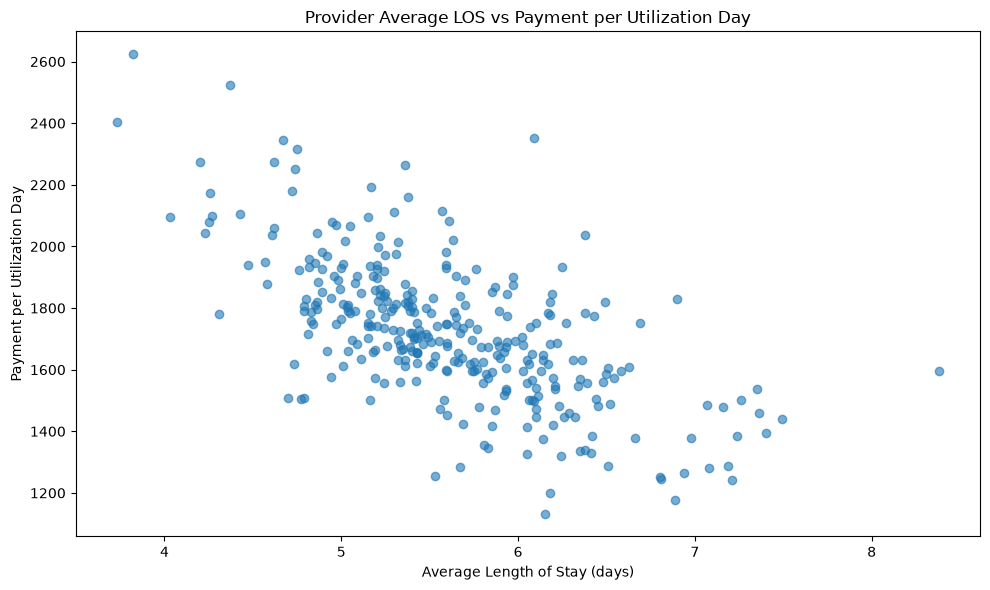

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    provider_los_scatter["avg_los"],
    provider_los_scatter["payment_per_utilization_day"],
    alpha=0.6
)

plt.xlabel("Average Length of Stay (days)")
plt.ylabel("Payment per Utilization Day")
plt.title(
    "Provider Average LOS vs Payment per Utilization Day"
)

plt.tight_layout()
plt.show()

In [44]:
provider_benchmark = con.execute("""
    WITH provider_summary AS (
        SELECT
            provider_id,
            COUNT(*) AS claim_count,
            SUM(payment) AS total_payment,
            AVG(payment) AS avg_payment_per_claim,
            SUM(utilization_days) AS total_utilization_days,
            AVG(utilization_days) AS avg_los
        FROM claims_all
        WHERE claim_type = 'Inpatient'
          AND provider_id IS NOT NULL
        GROUP BY provider_id
    ),

    benchmark AS (
        SELECT
            SUM(payment)
                / NULLIF(SUM(utilization_days), 0)
                AS benchmark_payment_per_day,
            AVG(payment) AS benchmark_payment_per_claim
        FROM claims_all
        WHERE claim_type = 'Inpatient'
          AND utilization_days IS NOT NULL
          AND utilization_days > 0
    )

    SELECT
        p.provider_id,
        p.claim_count,
        ROUND(p.total_payment, 2) AS total_payment,
        ROUND(p.avg_payment_per_claim, 2) AS avg_payment_per_claim,
        ROUND(p.avg_los, 2) AS avg_los,

        ROUND(
            p.total_payment
            / NULLIF(p.total_utilization_days, 0),
            2
        ) AS payment_per_utilization_day,

        ROUND(
            b.benchmark_payment_per_claim,
            2
        ) AS benchmark_payment_per_claim,

        ROUND(
            b.benchmark_payment_per_day,
            2
        ) AS benchmark_payment_per_day,

        ROUND(
            (
                p.avg_payment_per_claim
                - b.benchmark_payment_per_claim
            ) * 100.0
            / NULLIF(b.benchmark_payment_per_claim, 0),
            2
        ) AS payment_per_claim_vs_benchmark_pct,

        ROUND(
            (
                (
                    p.total_payment
                    / NULLIF(p.total_utilization_days, 0)
                )
                - b.benchmark_payment_per_day
            ) * 100.0
            / NULLIF(b.benchmark_payment_per_day, 0),
            2
        ) AS payment_per_day_vs_benchmark_pct

    FROM provider_summary p
    CROSS JOIN benchmark b

    WHERE p.claim_count >= 50
      AND p.total_utilization_days > 0

    ORDER BY
        payment_per_day_vs_benchmark_pct DESC
""").fetchdf()

print("Providers included:", len(provider_benchmark))
display(provider_benchmark.head(20))

Providers included: 319


,provider_id,claim_count,total_payment,avg_payment_per_claim,avg_los,payment_per_utilization_day,benchmark_payment_per_claim,benchmark_payment_per_day,payment_per_claim_vs_benchmark_pct,payment_per_day_vs_benchmark_pct
0,4508MT,71,711000.0,10014.08,3.82,2623.62,9570.84,1656.08,4.63,58.42
1,0400DH,52,573000.0,11019.23,4.37,2524.23,9570.84,1656.08,15.13,52.42
2,27006D,60,538400.0,8973.33,3.73,2403.57,9570.84,1656.08,-6.24,45.14
3,1500KD,57,816000.0,14315.79,6.09,2351.59,9570.84,1656.08,49.58,42.00
4,2200TM,100,1095900.0,10959.00,4.67,2346.68,9570.84,1656.08,14.50,41.70
5,4500YG,103,1132400.0,10994.17,4.75,2315.75,9570.84,1656.08,14.87,39.83
6,1600MG,71,678000.0,9549.30,4.20,2275.17,9570.84,1656.08,-0.23,37.38
7,0504BP,74,778000.0,10513.51,4.62,2274.85,9570.84,1656.08,9.85,37.36
8,1001WM,131,1398040.0,10672.06,4.74,2269.55,9570.84,1656.08,11.51,37.04
9,33038A,73,885600.0,12131.51,5.36,2264.96,9570.84,1656.08,26.75,36.77


In [45]:
provider_benchmark_classified = con.execute("""
    SELECT
        *,
        CASE
            WHEN payment_per_day_vs_benchmark_pct < -10
                THEN 'Below Benchmark'
            WHEN payment_per_day_vs_benchmark_pct <= 10
                THEN 'Near Benchmark'
            WHEN payment_per_day_vs_benchmark_pct <= 25
                THEN 'Above Benchmark'
            ELSE 'High Intensity'
        END AS intensity_category

    FROM provider_benchmark

    ORDER BY
        payment_per_day_vs_benchmark_pct DESC
""").fetchdf()

print("Providers classified:", len(provider_benchmark_classified))

display(
    provider_benchmark_classified[
        [
            "provider_id",
            "claim_count",
            "avg_los",
            "payment_per_utilization_day",
            "payment_per_day_vs_benchmark_pct",
            "intensity_category"
        ]
    ].head(20)
)

Providers classified: 319


,provider_id,claim_count,avg_los,payment_per_utilization_day,payment_per_day_vs_benchmark_pct,intensity_category
0,4508MT,71,3.82,2623.62,58.42,High Intensity
1,0400DH,52,4.37,2524.23,52.42,High Intensity
2,27006D,60,3.73,2403.57,45.14,High Intensity
3,1500KD,57,6.09,2351.59,42.00,High Intensity
4,2200TM,100,4.67,2346.68,41.70,High Intensity
5,4500YG,103,4.75,2315.75,39.83,High Intensity
6,1600MG,71,4.20,2275.17,37.38,High Intensity
7,0504BP,74,4.62,2274.85,37.36,High Intensity
8,1001WM,131,4.74,2269.55,37.04,High Intensity
9,33038A,73,5.36,2264.96,36.77,High Intensity


In [46]:
provider_category_summary = con.execute("""
    SELECT
        intensity_category,
        COUNT(*) AS provider_count,
        ROUND(
            COUNT(*) * 100.0
            / SUM(COUNT(*)) OVER (),
            2
        ) AS provider_share_pct,

        ROUND(AVG(claim_count), 2) AS avg_claim_count,

        ROUND(
            AVG(payment_per_utilization_day),
            2
        ) AS avg_payment_per_utilization_day,

        ROUND(
            AVG(payment_per_day_vs_benchmark_pct),
            2
        ) AS avg_vs_benchmark_pct

    FROM provider_benchmark_classified

    GROUP BY intensity_category

    ORDER BY
        CASE intensity_category
            WHEN 'Below Benchmark' THEN 1
            WHEN 'Near Benchmark' THEN 2
            WHEN 'Above Benchmark' THEN 3
            WHEN 'High Intensity' THEN 4
        END
""").fetchdf()

display(provider_category_summary)

print(
    "Total providers:",
    provider_category_summary["provider_count"].sum()
)

print(
    "Total provider share:",
    round(
        provider_category_summary["provider_share_pct"].sum(),
        2
    )
)

,intensity_category,provider_count,provider_share_pct,avg_claim_count,avg_payment_per_utilization_day,avg_vs_benchmark_pct
0,Below Benchmark,44,13.79,82.59,1370.46,-17.25
1,Near Benchmark,182,57.05,133.50,1675.18,1.15
2,Above Benchmark,68,21.32,121.81,1918.81,15.86
3,High Intensity,25,7.84,91.84,2220.51,34.08


Total providers: 319
Total provider share: 100.0


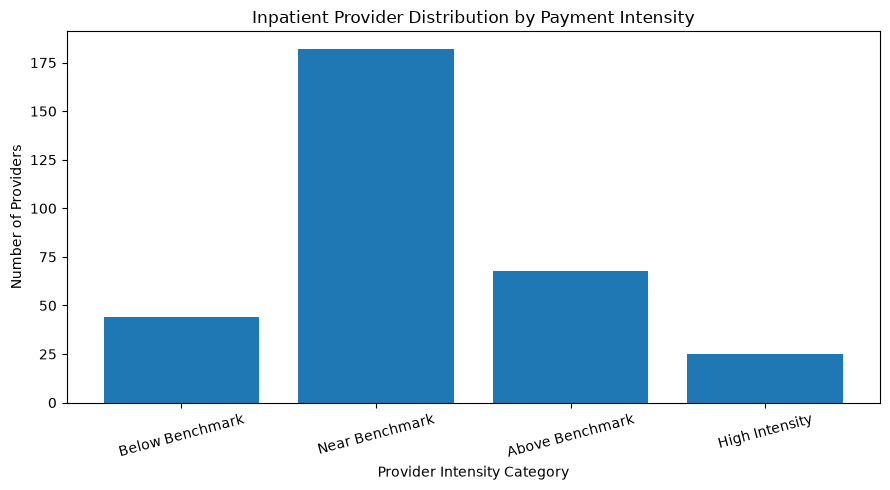

In [47]:
import matplotlib.pyplot as plt

chart_data = provider_category_summary.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    chart_data["intensity_category"],
    chart_data["provider_count"]
)

plt.xlabel("Provider Intensity Category")
plt.ylabel("Number of Providers")
plt.title("Inpatient Provider Distribution by Payment Intensity")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [48]:
PROVIDER_OUTPUT = SQL_DIR / "provider_benchmark.csv"

provider_benchmark_classified.to_csv(
    PROVIDER_OUTPUT,
    index=False
)

print("Saved:", PROVIDER_OUTPUT)
print("Rows:", len(provider_benchmark_classified))
print("Columns:", len(provider_benchmark_classified.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\provider_benchmark.csv
Rows: 319
Columns: 11


In [49]:
import pandas as pd

provider_check = pd.read_csv(PROVIDER_OUTPUT)

print("Rows:", len(provider_check))
print("Columns:", len(provider_check.columns))

print(
    "\nMissing provider IDs:",
    provider_check["provider_id"].isna().sum()
)

print(
    "Missing intensity categories:",
    provider_check["intensity_category"].isna().sum()
)

print("\nIntensity categories:")
print(
    provider_check["intensity_category"]
    .value_counts()
    .sort_index()
)

Rows: 319
Columns: 11

Missing provider IDs: 0
Missing intensity categories: 0

Intensity categories:
intensity_category
Above Benchmark     68
Below Benchmark     44
High Intensity      25
Near Benchmark     182
Name: count, dtype: int64


## Provider Benchmarking Ã¢â‚¬â€ Business Interpretation

Provider-level benchmarking was performed for inpatient providers with at least
50 claims and positive utilization days, resulting in 319 providers.

The overall inpatient benchmark was Ã¢â€šÂ¹1,656.08 per utilization day.

Providers were classified using analytical thresholds:

- Below Benchmark: <10% below the benchmark
- Near Benchmark: within Ã‚Â±10% of the benchmark
- Above Benchmark: >10% to 25% above the benchmark
- High Intensity: >25% above the benchmark

The resulting distribution was:

- Below Benchmark: 44 providers (13.79%)
- Near Benchmark: 182 providers (57.05%)
- Above Benchmark: 68 providers (21.32%)
- High Intensity: 25 providers (7.84%)

Overall, 29.16% of the analyzed providers were above the benchmark,
including 7.84% classified as High Intensity.

A provider-level correlation analysis found a correlation of -0.6493 between
average length of stay and payment per utilization day. This indicates that,
within the analyzed provider population, providers with longer average stays
tended to have lower payment intensity per utilization day.

These findings are descriptive benchmarking signals only. They do not establish
that a provider is overbilling, inefficient, fraudulent, or clinically
inappropriate. Provider differences may reflect case mix, service mix,
utilization patterns, payment structure, or other factors.

The CMS DE-SynPUF dataset is synthetic, so these results should not be
interpreted as real-world provider performance.

In [50]:
payment_integrity_summary = con.execute("""
    SELECT
        claim_type,

        COUNT(*) AS total_claims,

        SUM(
            CASE
                WHEN payment < 0 THEN 1
                ELSE 0
            END
        ) AS negative_payment_claims,

        SUM(
            CASE
                WHEN payment = 0 THEN 1
                ELSE 0
            END
        ) AS zero_payment_claims,

        SUM(
            CASE
                WHEN payment <= 0 THEN 1
                ELSE 0
            END
        ) AS non_positive_claims,

        ROUND(
            SUM(
                CASE
                    WHEN payment < 0 THEN payment
                    ELSE 0
                END
            ),
            2
        ) AS negative_payment_amount,

        ROUND(
            SUM(payment),
            2
        ) AS total_payment

    FROM claims_all

    GROUP BY claim_type

    ORDER BY claim_type
""").fetchdf()

display(payment_integrity_summary)

,claim_type,total_claims,negative_payment_claims,zero_payment_claims,non_positive_claims,negative_payment_amount,total_payment
0,Inpatient,66773,55.0,2160.0,2215.0,-33540.0,639260180.0
1,Outpatient,790790,2566.0,30105.0,32671.0,-80410.0,224524710.0


In [51]:
payment_integrity_rates = con.execute("""
    SELECT
        claim_type,

        COUNT(*) AS total_claims,

        SUM(
            CASE
                WHEN payment < 0 THEN 1
                ELSE 0
            END
        ) AS negative_payment_claims,

        SUM(
            CASE
                WHEN payment = 0 THEN 1
                ELSE 0
            END
        ) AS zero_payment_claims,

        SUM(
            CASE
                WHEN payment <= 0 THEN 1
                ELSE 0
            END
        ) AS non_positive_claims,

        ROUND(
            SUM(
                CASE
                    WHEN payment < 0 THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS negative_payment_rate_pct,

        ROUND(
            SUM(
                CASE
                    WHEN payment = 0 THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS zero_payment_rate_pct,

        ROUND(
            SUM(
                CASE
                    WHEN payment <= 0 THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS non_positive_rate_pct

    FROM claims_all

    GROUP BY claim_type

    ORDER BY claim_type
""").fetchdf()

display(payment_integrity_rates)

,claim_type,total_claims,negative_payment_claims,zero_payment_claims,non_positive_claims,negative_payment_rate_pct,zero_payment_rate_pct,non_positive_rate_pct
0,Inpatient,66773,55.0,2160.0,2215.0,0.08,3.23,3.32
1,Outpatient,790790,2566.0,30105.0,32671.0,0.32,3.81,4.13


In [52]:
provider_payment_integrity = con.execute("""
    SELECT
        claim_type,
        provider_id,

        COUNT(*) AS total_claims,

        SUM(
            CASE
                WHEN payment < 0 THEN 1
                ELSE 0
            END
        ) AS negative_payment_claims,

        SUM(
            CASE
                WHEN payment = 0 THEN 1
                ELSE 0
            END
        ) AS zero_payment_claims,

        SUM(
            CASE
                WHEN payment <= 0 THEN 1
                ELSE 0
            END
        ) AS non_positive_claims,

        ROUND(
            SUM(
                CASE
                    WHEN payment < 0 THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS negative_payment_rate_pct,

        ROUND(
            SUM(
                CASE
                    WHEN payment = 0 THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS zero_payment_rate_pct,

        ROUND(
            SUM(
                CASE
                    WHEN payment <= 0 THEN 1
                    ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS non_positive_rate_pct,

        ROUND(
            SUM(payment),
            2
        ) AS total_payment

    FROM claims_all

    WHERE provider_id IS NOT NULL

    GROUP BY
        claim_type,
        provider_id

    HAVING COUNT(*) >= 100

    ORDER BY
        non_positive_rate_pct DESC
""").fetchdf()

print(
    "Providers included:",
    len(provider_payment_integrity)
)

display(
    provider_payment_integrity.head(20)
)

Providers included: 1740


,claim_type,provider_id,total_claims,negative_payment_claims,zero_payment_claims,non_positive_claims,negative_payment_rate_pct,zero_payment_rate_pct,non_positive_rate_pct,total_payment
0,Outpatient,4400BA,105,1.0,12.0,13.0,0.95,11.43,12.38,25590.0
1,Outpatient,1701DN,153,0.0,16.0,16.0,0.00,10.46,10.46,29590.0
2,Outpatient,3100SP,128,1.0,12.0,13.0,0.78,9.38,10.16,38730.0
3,Outpatient,3902MT,101,0.0,10.0,10.0,0.00,9.90,9.90,36390.0
4,Outpatient,4900HR,166,1.0,15.0,16.0,0.60,9.04,9.64,37410.0
5,Outpatient,0400WD,128,0.0,12.0,12.0,0.00,9.38,9.38,22920.0
6,Outpatient,3400KG,129,1.0,11.0,12.0,0.78,8.53,9.30,35850.0
7,Inpatient,2200JA,110,0.0,10.0,10.0,0.00,9.09,9.09,943000.0
8,Outpatient,0600ZV,114,0.0,10.0,10.0,0.00,8.77,8.77,36490.0
9,Outpatient,4513MP,103,1.0,8.0,9.0,0.97,7.77,8.74,18670.0


In [53]:
provider_payment_integrity_flagged = con.execute("""
    SELECT
        *,
        CASE
            WHEN non_positive_rate_pct >= 10
                THEN 'High Signal'
            WHEN non_positive_rate_pct >= 5
                THEN 'Elevated'
            ELSE 'Standard'
        END AS integrity_signal

    FROM provider_payment_integrity

    ORDER BY
        non_positive_rate_pct DESC,
        total_claims DESC
""").fetchdf()

print(
    "Provider/service combinations:",
    len(provider_payment_integrity_flagged)
)

display(
    provider_payment_integrity_flagged.head(20)
)

Provider/service combinations: 1740


,claim_type,provider_id,total_claims,negative_payment_claims,zero_payment_claims,non_positive_claims,negative_payment_rate_pct,zero_payment_rate_pct,non_positive_rate_pct,total_payment,integrity_signal
0,Outpatient,4400BA,105,1.0,12.0,13.0,0.95,11.43,12.38,25590.0,High Signal
1,Outpatient,1701DN,153,0.0,16.0,16.0,0.00,10.46,10.46,29590.0,High Signal
2,Outpatient,3100SP,128,1.0,12.0,13.0,0.78,9.38,10.16,38730.0,High Signal
3,Outpatient,3902MT,101,0.0,10.0,10.0,0.00,9.90,9.90,36390.0,Elevated
4,Outpatient,4900HR,166,1.0,15.0,16.0,0.60,9.04,9.64,37410.0,Elevated
5,Outpatient,0400WD,128,0.0,12.0,12.0,0.00,9.38,9.38,22920.0,Elevated
6,Outpatient,3400KG,129,1.0,11.0,12.0,0.78,8.53,9.30,35850.0,Elevated
7,Inpatient,2200JA,110,0.0,10.0,10.0,0.00,9.09,9.09,943000.0,Elevated
8,Outpatient,0600ZV,114,0.0,10.0,10.0,0.00,8.77,8.77,36490.0,Elevated
9,Outpatient,4513MP,103,1.0,8.0,9.0,0.97,7.77,8.74,18670.0,Elevated


In [54]:
integrity_signal_summary = con.execute("""
    SELECT
        claim_type,
        integrity_signal,

        COUNT(*) AS provider_count,

        ROUND(
            COUNT(*) * 100.0
            / SUM(COUNT(*)) OVER (PARTITION BY claim_type),
            2
        ) AS provider_share_pct,

        ROUND(
            AVG(non_positive_rate_pct),
            2
        ) AS avg_non_positive_rate_pct,

        SUM(total_claims) AS claims_represented,

        SUM(non_positive_claims) AS non_positive_claims

    FROM provider_payment_integrity_flagged

    GROUP BY
        claim_type,
        integrity_signal

    ORDER BY
        claim_type,
        CASE integrity_signal
            WHEN 'Standard' THEN 1
            WHEN 'Elevated' THEN 2
            WHEN 'High Signal' THEN 3
        END
""").fetchdf()

display(integrity_signal_summary)

,claim_type,integrity_signal,provider_count,provider_share_pct,avg_non_positive_rate_pct,claims_represented,non_positive_claims
0,Inpatient,Standard,115,82.73,2.93,22587.0,668.0
1,Inpatient,Elevated,24,17.27,6.09,3562.0,214.0
2,Outpatient,Standard,1226,76.58,3.57,550392.0,21160.0
3,Outpatient,Elevated,372,23.24,5.99,95845.0,5514.0
4,Outpatient,High Signal,3,0.19,11.00,386.0,42.0


In [55]:
high_signal_providers = con.execute("""
    SELECT
        claim_type,
        provider_id,
        total_claims,
        negative_payment_claims,
        zero_payment_claims,
        non_positive_claims,
        negative_payment_rate_pct,
        zero_payment_rate_pct,
        non_positive_rate_pct,
        total_payment
    FROM provider_payment_integrity_flagged
    WHERE integrity_signal = 'High Signal'
    ORDER BY non_positive_rate_pct DESC
""").fetchdf()

display(high_signal_providers)

,claim_type,provider_id,total_claims,negative_payment_claims,zero_payment_claims,non_positive_claims,negative_payment_rate_pct,zero_payment_rate_pct,non_positive_rate_pct,total_payment
0,Outpatient,4400BA,105,1.0,12.0,13.0,0.95,11.43,12.38,25590.0
1,Outpatient,1701DN,153,0.0,16.0,16.0,0.00,10.46,10.46,29590.0
2,Outpatient,3100SP,128,1.0,12.0,13.0,0.78,9.38,10.16,38730.0


In [56]:
PAYMENT_INTEGRITY_OUTPUT = SQL_DIR / "provider_payment_integrity.csv"

provider_payment_integrity_flagged.to_csv(
    PAYMENT_INTEGRITY_OUTPUT,
    index=False
)

print("Saved:", PAYMENT_INTEGRITY_OUTPUT)
print("Rows:", len(provider_payment_integrity_flagged))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\provider_payment_integrity.csv
Rows: 1740


## Payment Integrity Screening Ã¢â‚¬â€ Business Interpretation

Payment-integrity screening was performed using negative, zero, and non-positive
claim payments.

The analysis identified:

- 2,621 negative-payment claims across all claims (0.31%).
- 32,265 zero-payment claims.
- 32,265 claims with zero payment should not be interpreted as denied claims
  because no dedicated denial-status field was identified.
- Negative payments were retained because they may represent legitimate
  payment adjustments or other financial activity and require investigation
  rather than automatic removal.

For provider-level screening, providers with at least 100 claims were evaluated,
resulting in 1,740 provider/service combinations.

Providers were classified using analytical screening thresholds:

- Standard: non-positive payment rate <5%
- Elevated: non-positive payment rate 5% to <10%
- High Signal: non-positive payment rate >=10%

Among inpatient providers:

- 115 providers (82.73%) were classified as Standard.
- 24 providers (17.27%) were classified as Elevated.
- No inpatient provider reached the High Signal threshold.

Among outpatient providers:

- 1,226 providers (76.58%) were classified as Standard.
- 372 providers (23.24%) were classified as Elevated.
- 3 providers (0.19%) were classified as High Signal.

The three highest outpatient screening signals were:

- Provider 4400BA: 12.38% non-positive payments.
- Provider 1701DN: 10.46% non-positive payments.
- Provider 3100SP: 10.16% non-positive payments.

These results are screening signals only. They do not establish that a provider
has denied claims, billing errors, fraud, overpayment, or inappropriate billing.

The thresholds used in this analysis are custom analytical thresholds and are
not official CMS classifications.

Because the CMS DE-SynPUF dataset is synthetic, provider-level payment-integrity
patterns should not be interpreted as real-world provider performance.

The provider-level screening results were exported to:

`04_SQL/provider_payment_integrity.csv`

In [57]:
payment_integrity_reconciliation = con.execute("""
    SELECT
        (SELECT COUNT(*) FROM claims_all) AS total_claims,
        
        (SELECT COUNT(*)
         FROM claims_all
         WHERE payment < 0) AS total_negative_claims,
        
        (SELECT COUNT(*)
         FROM claims_all
         WHERE payment = 0) AS total_zero_payment_claims,
        
        (SELECT COUNT(*)
         FROM claims_all
         WHERE payment <= 0) AS total_non_positive_claims,
        
        (SELECT SUM(total_claims)
         FROM provider_payment_integrity) AS screened_provider_claims,
        
        (SELECT SUM(non_positive_claims)
         FROM provider_payment_integrity) AS screened_non_positive_claims
""").fetchdf()

display(payment_integrity_reconciliation)

,total_claims,total_negative_claims,total_zero_payment_claims,total_non_positive_claims,screened_provider_claims,screened_non_positive_claims
0,857563,2621,32265,34886,672772.0,27598.0


### Payment Integrity Reconciliation

The overall claims population contains 857,563 claims, including:

- 2,621 negative-payment claims.
- 32,265 zero-payment claims.
- 34,886 non-positive-payment claims.

The provider-level payment-integrity screening covers 672,772 claims.
This is intentionally lower than the full claims population because the
provider analysis was restricted to provider/service combinations with at
least 100 claims.

Therefore, the provider-level screening results should be interpreted as a
high-volume-provider screening analysis rather than a complete assessment of
every provider or claim.

The reconciliation confirms that:

`negative claims + zero-payment claims = non-positive claims`

and that the provider-level screening operates within the defined analytical
scope.

In [58]:
claims_financial_summary = con.execute("""
    SELECT
        claim_type,

        COUNT(*) AS total_claims,

        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,

        COUNT(DISTINCT provider_id) AS unique_providers,

        ROUND(SUM(payment), 2) AS total_payment,

        ROUND(AVG(payment), 2) AS average_payment_per_claim,

        
        ROUND(
            MEDIAN(payment),
            2
        ) AS median_payment_per_claim,

        ROUND(
            SUM(CASE WHEN payment > 0 THEN payment ELSE 0 END),
            2
        ) AS positive_payment_amount,

        ROUND(
            SUM(CASE WHEN payment < 0 THEN payment ELSE 0 END),
            2
        ) AS negative_payment_amount,

        SUM(CASE WHEN payment > 0 THEN 1 ELSE 0 END)
            AS positive_payment_claims,

        SUM(CASE WHEN payment = 0 THEN 1 ELSE 0 END)
            AS zero_payment_claims,

        SUM(CASE WHEN payment < 0 THEN 1 ELSE 0 END)
            AS negative_payment_claims

    FROM claims_all

    GROUP BY claim_type

    ORDER BY claim_type
""").fetchdf()

display(claims_financial_summary)

,claim_type,total_claims,unique_beneficiaries,unique_providers,total_payment,average_payment_per_claim,median_payment_per_claim,positive_payment_amount,negative_payment_amount,positive_payment_claims,zero_payment_claims,negative_payment_claims
0,Inpatient,66773,37780,2675,639260180.0,9573.63,7000.0,639293720.0,-33540.0,64558.0,2160.0,55.0
1,Outpatient,790790,85272,6294,224524710.0,283.92,80.0,224605120.0,-80410.0,758119.0,30105.0,2566.0


### Claims Financial Summary Ã¢â‚¬â€ Business Interpretation

The combined financial summary highlights a major difference between inpatient
and outpatient services.

Inpatient claims represent a relatively small share of total claim volume but
account for the majority of total payments:

- 66,773 inpatient claims.
- 639.26 million in total payments.
- Average payment per claim: 9,573.63.
- Median payment per claim: 7,000.

Outpatient claims represent the majority of claim volume:

- 790,790 outpatient claims.
- 224.52 million in total payments.
- Average payment per claim: 283.92.
- Median payment per claim: 80.

This indicates that inpatient services have substantially higher financial
intensity per claim, while outpatient services generate much greater claim
volume.

The difference between average and median payments also indicates right-skewed
payment distributions, particularly for inpatient claims.

Negative and zero-payment claims are retained in the analysis. Zero payment
does not represent a confirmed denial because no dedicated denial-status field
was identified.

These findings are descriptive and are based on the synthetic CMS DE-SynPUF
dataset.

In [59]:
claim_payment_concentration = con.execute("""
    WITH ranked_claims AS (
        SELECT
            claim_type,
            claim_id,
            beneficiary_id,
            payment,
            ROW_NUMBER() OVER (
                PARTITION BY claim_type
                ORDER BY payment DESC
            ) AS claim_rank,
            COUNT(*) OVER (
                PARTITION BY claim_type
            ) AS total_claims
        FROM claims_all
        WHERE payment > 0
    ),
    concentration AS (
        SELECT
            claim_type,

            total_claims,

            SUM(payment) AS total_positive_payment,

            SUM(
                CASE
                    WHEN claim_rank <= CEIL(total_claims * 0.01)
                    THEN payment
                    ELSE 0
                END
            ) AS top_1_pct_payment,

            SUM(
                CASE
                    WHEN claim_rank <= CEIL(total_claims * 0.05)
                    THEN payment
                    ELSE 0
                END
            ) AS top_5_pct_payment,

            SUM(
                CASE
                    WHEN claim_rank <= CEIL(total_claims * 0.10)
                    THEN payment
                    ELSE 0
                END
            ) AS top_10_pct_payment

        FROM ranked_claims
        GROUP BY
            claim_type,
            total_claims
    )
    SELECT
        claim_type,
        total_claims,
        ROUND(total_positive_payment, 2) AS total_positive_payment,

        ROUND(top_1_pct_payment, 2) AS top_1_pct_payment,
        ROUND(
            top_1_pct_payment * 100.0
            / total_positive_payment,
            2
        ) AS top_1_payment_share_pct,

        ROUND(top_5_pct_payment, 2) AS top_5_pct_payment,
        ROUND(
            top_5_pct_payment * 100.0
            / total_positive_payment,
            2
        ) AS top_5_payment_share_pct,

        ROUND(top_10_pct_payment, 2) AS top_10_pct_payment,
        ROUND(
            top_10_pct_payment * 100.0
            / total_positive_payment,
            2
        ) AS top_10_payment_share_pct

    FROM concentration
    ORDER BY claim_type
""").fetchdf()

display(claim_payment_concentration)

,claim_type,total_claims,total_positive_payment,top_1_pct_payment,top_1_payment_share_pct,top_5_pct_payment,top_5_payment_share_pct,top_10_pct_payment,top_10_payment_share_pct
0,Inpatient,64558,639293720.0,36822000.0,5.76,134912000.0,21.10,210924000.0,32.99
1,Outpatient,758119,224605120.0,25020600.0,11.14,93919900.0,41.82,136119700.0,60.60


### Claim Payment Concentration Ã¢â‚¬â€ Business Interpretation

Claim-level payment concentration was assessed using positive-payment claims
only. This excludes zero and negative payments from the concentration ranking.

The results show different payment concentration patterns between inpatient and
outpatient services.

#### Inpatient

- Top 1% of positive-payment claims account for 5.76% of positive payments.
- Top 5% account for 21.10%.
- Top 10% account for 32.99%.

#### Outpatient

- Top 1% of positive-payment claims account for 11.14% of positive payments.
- Top 5% account for 41.82%.
- Top 10% account for 60.60%.

Outpatient payment is therefore substantially more concentrated among the
highest-value individual claims than inpatient payment.

This analysis complements beneficiary-level payment concentration:

- Claim-level concentration identifies high-value individual claims.
- Beneficiary-level concentration identifies beneficiaries associated with
  high cumulative payments.

The concentration results are descriptive and should not be interpreted as
evidence of inappropriate billing or payment problems. The CMS DE-SynPUF data
is synthetic and the observed payment distribution may reflect the structure
of the synthetic dataset.

In [60]:
top_payment_claims = con.execute("""
    SELECT
        claim_type,
        claim_id,
        segment,
        beneficiary_id,
        provider_id,
        claim_from_date,
        claim_thru_date,
        payment,
        utilization_days,
        primary_diagnosis,

        ROW_NUMBER() OVER (
            ORDER BY payment DESC
        ) AS payment_rank

    FROM claims_all

    WHERE payment > 0

    ORDER BY payment DESC

    LIMIT 20
""").fetchdf()

display(top_payment_claims)

,claim_type,claim_id,segment,beneficiary_id,provider_id,claim_from_date,claim_thru_date,payment,utilization_days,primary_diagnosis,payment_rank
0,Inpatient,196731177014919,1,002AB71D3224BE66,1000AH,2008-08-01,2008-08-12,57000.0,11.0,4372,1
1,Inpatient,196011176959552,1,0289ABA0311E49CC,3302VG,2009-08-01,2009-08-15,57000.0,14.0,3962,8
2,Inpatient,196491177001624,1,008DC0117CD70DAB,0100YT,2010-05-29,2010-06-21,57000.0,23.0,51189,3
3,Inpatient,196591176975746,1,03AF37A2BB4241CE,3600NG,2009-10-12,2009-10-20,57000.0,8.0,40391,11
4,Inpatient,196911176970111,1,03AEAF24B59C6DE2,1501ZA,2010-05-14,2010-05-21,57000.0,7.0,42823,10
5,Inpatient,196491176992131,1,00C91B5EEA137225,10S0NQ,2010-01-18,2010-02-22,57000.0,74.0,41071,4
6,Inpatient,196661176998969,1,027839B0716598D0,3600TU,2010-03-08,2010-04-12,57000.0,42.0,41041,7
7,Inpatient,196481176993529,1,0417AA533598FCB6,1701MN,2009-06-19,2009-07-07,57000.0,18.0,4239,14
8,Inpatient,196751176974596,1,04050030537DEE20,2600AP,2010-03-22,2010-04-05,57000.0,14.0,486,13
9,Inpatient,196941176996237,1,0307CF5EFBABB6F0,01S1YV,2008-12-14,2008-12-26,57000.0,12.0,4210,9


In [61]:
max_payment_pattern = con.execute("""
    WITH inpatient_positive AS (
        SELECT
            payment
        FROM claims_all
        WHERE claim_type = 'Inpatient'
          AND payment > 0
    ),
    max_payment AS (
        SELECT
            MAX(payment) AS maximum_payment
        FROM inpatient_positive
    )
    SELECT
        m.maximum_payment,

        COUNT(*) AS claims_at_max_payment,

        ROUND(
            COUNT(*) * 100.0
            / (SELECT COUNT(*) FROM inpatient_positive),
            2
        ) AS share_of_positive_inpatient_claims_pct,

        ROUND(
            SUM(m.maximum_payment),
            2
        ) AS total_payment_at_max_value,

        ROUND(
            SUM(m.maximum_payment) * 100.0
            / (SELECT SUM(payment) FROM inpatient_positive),
            2
        ) AS share_of_positive_inpatient_payment_pct

    FROM inpatient_positive p
    CROSS JOIN max_payment m
    WHERE p.payment = m.maximum_payment

    GROUP BY
        m.maximum_payment
""").fetchdf()

display(max_payment_pattern)

,maximum_payment,claims_at_max_payment,share_of_positive_inpatient_claims_pct,total_payment_at_max_value,share_of_positive_inpatient_payment_pct
0,57000.0,679,1.05,38703000.0,6.05


### Repeated Maximum Payment Pattern Ã¢â‚¬â€ Business Interpretation

The maximum positive inpatient payment is 57,000.

A total of 679 inpatient claims have exactly this payment value, representing:

- 1.05% of positive inpatient claims.
- 6.05% of positive inpatient payments.
- 38.703 million in total payments.

The repeated occurrence of the maximum payment value indicates that the
synthetic dataset contains a discrete upper payment boundary or repeated
maximum-value pattern.

This should not be interpreted as evidence of duplicate billing, fraud,
overpayment, or inappropriate claims.

The finding is useful for payment-distribution analysis and should be considered
when interpreting high-value claim concentrations in the CMS DE-SynPUF dataset.

In [62]:
outpatient_max_payment_pattern = con.execute("""
    WITH outpatient_positive AS (
        SELECT
            payment
        FROM claims_all
        WHERE claim_type = 'Outpatient'
          AND payment > 0
    ),
    max_payment AS (
        SELECT
            MAX(payment) AS maximum_payment
        FROM outpatient_positive
    )
    SELECT
        m.maximum_payment,

        COUNT(*) AS claims_at_max_payment,

        ROUND(
            COUNT(*) * 100.0
            / (SELECT COUNT(*) FROM outpatient_positive),
            2
        ) AS share_of_positive_outpatient_claims_pct,

        ROUND(
            SUM(m.maximum_payment),
            2
        ) AS total_payment_at_max_value,

        ROUND(
            SUM(m.maximum_payment) * 100.0
            / (SELECT SUM(payment) FROM outpatient_positive),
            2
        ) AS share_of_positive_outpatient_payment_pct

    FROM outpatient_positive p
    CROSS JOIN max_payment m
    WHERE p.payment = m.maximum_payment

    GROUP BY
        m.maximum_payment
""").fetchdf()

display(outpatient_max_payment_pattern)

,maximum_payment,claims_at_max_payment,share_of_positive_outpatient_claims_pct,total_payment_at_max_value,share_of_positive_outpatient_payment_pct
0,3300.0,8494,1.12,28030200.0,12.48


In [63]:
outpatient_payment_check = con.execute("""
    SELECT
        COUNT(*) AS outpatient_claims,
        COUNT(CASE WHEN payment > 0 THEN 1 END) AS positive_claims,
        MIN(CASE WHEN payment > 0 THEN payment END) AS minimum_positive_payment,
        MAX(CASE WHEN payment > 0 THEN payment END) AS maximum_positive_payment,
        ROUND(SUM(CASE WHEN payment > 0 THEN payment ELSE 0 END), 2)
            AS total_positive_payment
    FROM claims_all
    WHERE claim_type = 'Outpatient'
""").fetchdf()

display(outpatient_payment_check)

,outpatient_claims,positive_claims,minimum_positive_payment,maximum_positive_payment,total_positive_payment
0,790790,758119,10.0,3300.0,224605120.0


### Repeated Maximum Outpatient Payment Pattern Ã¢â‚¬â€ Business Interpretation

The maximum positive outpatient payment is 3,300.

A total of 8,494 outpatient claims have exactly this payment value,
representing:

- 1.12% of positive outpatient claims.
- 12.48% of positive outpatient payments.
- 28.0302 million in total payments.

The repeated occurrence of the maximum payment value indicates a discrete
upper payment boundary or repeated maximum-value pattern in the synthetic
dataset.

This should not be interpreted as evidence of duplicate billing, fraud,
overpayment, or inappropriate claims.

The finding is useful for understanding outpatient payment concentration and
for interpreting the high-value claim distribution in the CMS DE-SynPUF data.

In [64]:
claim_payment_concentration_output = SQL_DIR / "claim_payment_concentration.csv"
max_payment_pattern_output = SQL_DIR / "maximum_payment_patterns.csv"

claim_payment_concentration.to_csv(
    claim_payment_concentration_output,
    index=False
)

max_payment_patterns = pd.concat(
    [
        max_payment_pattern.assign(claim_type="Inpatient"),
        outpatient_max_payment_pattern.assign(claim_type="Outpatient")
    ],
    ignore_index=True
)

max_payment_patterns = max_payment_patterns[
    [
        "claim_type",
        "maximum_payment",
        "claims_at_max_payment",
        "share_of_positive_inpatient_claims_pct",
        "share_of_positive_inpatient_payment_pct",
        "share_of_positive_outpatient_claims_pct",
        "share_of_positive_outpatient_payment_pct",
        "total_payment_at_max_value"
    ]
]

max_payment_patterns.to_csv(
    max_payment_pattern_output,
    index=False
)

print("Saved:", claim_payment_concentration_output)
print("Saved:", max_payment_pattern_output)
print("Claim concentration rows:", len(claim_payment_concentration))
print("Maximum payment pattern rows:", len(max_payment_patterns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\claim_payment_concentration.csv
Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\maximum_payment_patterns.csv
Claim concentration rows: 2
Maximum payment pattern rows: 2


In [65]:
display(
    max_payment_patterns[
        [
            "claim_type",
            "maximum_payment",
            "claims_at_max_payment",
            "total_payment_at_max_value"
        ]
    ]
)

,claim_type,maximum_payment,claims_at_max_payment,total_payment_at_max_value
0,Inpatient,57000.0,679,38703000.0
1,Outpatient,3300.0,8494,28030200.0


In [66]:
claim_payment_bands = con.execute("""
    WITH classified_claims AS (
        SELECT
            claim_type,
            payment,

            CASE
                WHEN payment <= 100 THEN '0-100'
                WHEN payment <= 500 THEN '101-500'
                WHEN payment <= 1000 THEN '501-1,000'
                WHEN payment <= 5000 THEN '1,001-5,000'
                WHEN payment <= 10000 THEN '5,001-10,000'
                WHEN payment <= 25000 THEN '10,001-25,000'
                WHEN payment <= 50000 THEN '25,001-50,000'
                ELSE '50,001+'
            END AS payment_band

        FROM claims_all
        WHERE payment > 0
    )

    SELECT
        claim_type,
        payment_band,

        COUNT(*) AS claim_count,

        ROUND(
            COUNT(*) * 100.0
            / SUM(COUNT(*)) OVER (
                PARTITION BY claim_type
            ),
            2
        ) AS claim_share_pct,

        ROUND(
            SUM(payment),
            2
        ) AS total_payment,

        ROUND(
            SUM(payment) * 100.0
            / SUM(SUM(payment)) OVER (
                PARTITION BY claim_type
            ),
            2
        ) AS payment_share_pct,

        ROUND(
            AVG(payment),
            2
        ) AS average_payment

    FROM classified_claims

    GROUP BY
        claim_type,
        payment_band

    ORDER BY
        claim_type,
        CASE payment_band
            WHEN '0-100' THEN 1
            WHEN '101-500' THEN 2
            WHEN '501-1,000' THEN 3
            WHEN '1,001-5,000' THEN 4
            WHEN '5,001-10,000' THEN 5
            WHEN '10,001-25,000' THEN 6
            WHEN '25,001-50,000' THEN 7
            WHEN '50,001+' THEN 8
        END
""").fetchdf()

display(claim_payment_bands)

,claim_type,payment_band,claim_count,claim_share_pct,total_payment,payment_share_pct,average_payment
0,Inpatient,0-100,67,0.10,5020.0,0.00,74.93
1,Inpatient,101-500,215,0.33,71300.0,0.01,331.63
2,Inpatient,"501-1,000",559,0.87,512400.0,0.08,916.64
3,Inpatient,"1,001-5,000",23094,35.77,88870000.0,13.90,3848.19
4,Inpatient,"5,001-10,000",21735,33.67,168270000.0,26.32,7741.89
5,Inpatient,"10,001-25,000",14768,22.88,222259000.0,34.77,15050.04
6,Inpatient,"25,001-50,000",3231,5.00,109393000.0,17.11,33857.32
7,Inpatient,"50,001+",889,1.38,49913000.0,7.81,56145.11
8,Outpatient,0-100,508348,67.05,27665220.0,12.32,54.42
9,Outpatient,101-500,151600,20.00,46351300.0,20.64,305.75


### Claim Payment Bands Ã¢â‚¬â€ Business Interpretation

Positive-payment claims were grouped into payment bands to understand how claim
volume translates into financial contribution.

#### Inpatient

The inpatient payment distribution is concentrated in the middle and upper
payment bands:

- 35.77% of positive claims are in the 1,001Ã¢â‚¬â€œ5,000 range and contribute
  13.90% of payments.
- 22.88% of claims are in the 10,001Ã¢â‚¬â€œ25,000 range and contribute 34.77% of
  payments.
- Claims above 25,000 represent 6.38% of positive inpatient claims but
  contribute 24.92% of positive inpatient payments.
- Claims above 50,000 represent only 1.38% of positive inpatient claims but
  contribute 7.81% of positive inpatient payments.

#### Outpatient

Outpatient services show a much stronger volume-versus-value difference:

- 67.05% of positive outpatient claims are 100 or less, contributing only
  12.32% of outpatient payments.
- 20.00% of claims are in the 101Ã¢â‚¬â€œ500 range and contribute 20.64% of payments.
- Only 7.52% of claims are in the 1,001Ã¢â‚¬â€œ5,000 range, but this group contributes
  53.15% of outpatient payments.

This demonstrates that claim volume alone does not represent financial impact.
For outpatient services in particular, a relatively small proportion of
higher-value claims accounts for a substantial share of total payments.

The payment bands are descriptive analytical categories created for this
project and are not official CMS classifications.

In [67]:
payment_bands_output = SQL_DIR / "claim_payment_bands.csv"

claim_payment_bands.to_csv(
    payment_bands_output,
    index=False
)

print("Saved:", payment_bands_output)
print("Rows:", len(claim_payment_bands))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\claim_payment_bands.csv
Rows: 12


In [68]:
payment_band_reconciliation = con.execute("""
    SELECT
        claim_type,

        SUM(claim_count) AS band_claim_count,

        ROUND(
            SUM(claim_share_pct),
            2
        ) AS band_claim_share_pct,

        ROUND(
            SUM(total_payment),
            2
        ) AS band_total_payment,

        ROUND(
            SUM(payment_share_pct),
            2
        ) AS band_payment_share_pct

    FROM claim_payment_bands

    GROUP BY claim_type

    ORDER BY claim_type
""").fetchdf()

display(payment_band_reconciliation)

,claim_type,band_claim_count,band_claim_share_pct,band_total_payment,band_payment_share_pct
0,Inpatient,64558.0,100.0,639293720.0,100.0
1,Outpatient,758119.0,100.0,224605120.0,100.0


### Payment Band Reconciliation

The payment-band analysis reconciles exactly to the positive-payment claims in
each claim type.

#### Inpatient

- 64,558 positive-payment claims are represented.
- 100% of positive-payment claim volume is represented.
- 639.29372 million in positive payments are represented.
- 100% of positive inpatient payments are represented.

#### Outpatient

- 758,119 positive-payment claims are represented.
- 100% of positive-payment claim volume is represented.
- 224.60512 million in positive payments are represented.
- 100% of positive outpatient payments are represented.

This confirms that the payment-band classification did not exclude or
double-count any positive-payment claims.

In [69]:
inpatient_diagnosis_payment = con.execute("""
    SELECT
        primary_diagnosis,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        ROUND(SUM(payment), 2) AS total_payment,
        ROUND(AVG(payment), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim
    FROM claims_all
    WHERE claim_type = 'Inpatient'
      AND primary_diagnosis IS NOT NULL
      AND TRIM(primary_diagnosis) <> ''
    GROUP BY primary_diagnosis
    ORDER BY total_payment DESC
    LIMIT 20
""").fetchdf()

display(inpatient_diagnosis_payment)

,primary_diagnosis,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim
0,V5789,1807,1744,28421550.0,15728.58,15000.0
1,0389,1648,1603,24408390.0,14810.92,11000.0
2,41401,1675,1634,23847800.0,14237.49,11000.0
3,486,2453,2368,17101860.0,6971.81,6000.0
4,41071,1170,1135,14809630.0,12657.80,10000.0
5,51881,817,799,14232900.0,17420.93,12000.0
6,71536,1154,1132,13133020.0,11380.43,11000.0
7,4280,1419,1381,11069900.0,7801.20,6000.0
8,49121,1558,1490,9999100.0,6417.91,5000.0
9,5070,705,694,8624900.0,12233.90,10000.0


In [70]:
diagnosis_payment_output = SQL_DIR / "inpatient_diagnosis_payment.csv"

inpatient_diagnosis_payment.to_csv(
    diagnosis_payment_output,
    index=False
)

print("Saved:", diagnosis_payment_output)
print("Rows:", len(inpatient_diagnosis_payment))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\inpatient_diagnosis_payment.csv
Rows: 20


In [71]:
inpatient_diagnosis_high_value = con.execute("""
    SELECT
        primary_diagnosis,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        ROUND(SUM(payment), 2) AS total_payment,
        ROUND(AVG(payment), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim
    FROM claims_all
    WHERE claim_type = 'Inpatient'
      AND primary_diagnosis IS NOT NULL
      AND TRIM(primary_diagnosis) <> ''
      AND payment > 0
    GROUP BY primary_diagnosis
    HAVING COUNT(*) >= 100
    ORDER BY average_payment_per_claim DESC
    LIMIT 20
""").fetchdf()

display(inpatient_diagnosis_high_value)

,primary_diagnosis,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim
0,4241,188,188,6150000.0,32712.77,34000.0
1,4414,170,167,3648000.0,21458.82,18000.0
2,41011,115,115,2186000.0,19008.70,14000.0
3,51881,795,777,14232900.0,17903.02,12000.0
4,72252,128,128,2182700.0,17052.34,17000.0
5,99673,116,114,1975000.0,17025.86,16000.0
6,44024,111,111,1882000.0,16954.95,14000.0
7,4260,103,103,1744000.0,16932.04,15000.0
8,1623,148,147,2403200.0,16237.84,13000.0
9,V5789,1772,1712,28421600.0,16039.28,15000.0


In [72]:
high_value_diagnosis_output = SQL_DIR / "inpatient_diagnosis_high_value.csv"

inpatient_diagnosis_high_value.to_csv(
    high_value_diagnosis_output,
    index=False
)

print("Saved:", high_value_diagnosis_output)
print("Rows:", len(inpatient_diagnosis_high_value))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\inpatient_diagnosis_high_value.csv
Rows: 20


### Inpatient Diagnosis Payment Analysis Ã¢â‚¬â€ Business Interpretation

Inpatient diagnoses were analyzed from two complementary financial
perspectives:

1. Total payment by diagnosis.
2. Average payment per positive-payment claim by diagnosis.

#### Total Payment Perspective

The diagnosis with the highest total payment among the analyzed diagnoses was
`V5789`, with:

- 1,807 claims.
- 1,744 unique beneficiaries.
- 28.42 million in total payments.
- Average payment per claim of 15,728.58.

Other high-total-payment diagnoses included `0389` and `41401`.

#### Average Payment Perspective

To avoid ranking diagnoses with very small claim counts, only diagnoses with at
least 100 positive-payment claims were included.

The highest average payment per claim was observed for diagnosis `4241`:

- 188 positive claims.
- 6.15 million in total payments.
- Average payment per claim of 32,712.77.
- Median payment per claim of 34,000.

This demonstrates that diagnosis volume and financial intensity are different
dimensions of claims analytics.

A diagnosis can generate substantial total payments because it occurs
frequently, while another diagnosis may have fewer claims but substantially
higher payment per claim.

The diagnosis codes are presented as source-coded values. Clinical
interpretation should not be inferred without validating the corresponding
ICD-9 code definitions.

These findings are descriptive and based on the synthetic CMS DE-SynPUF
dataset.

In [73]:
outpatient_hcpcs_payment = con.execute("""
    SELECT
        hcpcs_cd,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        ROUND(SUM(payment), 2) AS total_payment,
        ROUND(AVG(payment), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim
    FROM (
        SELECT
            DESYNPUF_ID AS beneficiary_id,
            TRY_CAST(CLM_PMT_AMT AS DOUBLE) AS payment,
            TRIM(HCPCS_CD_1) AS hcpcs_cd
        FROM outpatient_claims
    )
    WHERE hcpcs_cd IS NOT NULL
      AND hcpcs_cd <> ''
      AND payment > 0
    GROUP BY hcpcs_cd
    ORDER BY total_payment DESC
    LIMIT 20
""").fetchdf()

display(outpatient_hcpcs_payment)

,hcpcs_cd,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim
0,A4657,20064,2404,38757970.0,1931.72,2000.0
1,36415,155566,57224,26558490.0,170.72,60.0
2,97110,17691,14549,6166060.0,348.54,200.0
3,99213,30345,23427,5923790.0,195.21,70.0
4,99212,22467,18396,4452570.0,198.18,70.0
5,80053,21939,18016,4361970.0,198.82,70.0
6,99214,14274,12525,2880240.0,201.78,70.0
7,99211,10981,9889,2716810.0,247.41,80.0
8,80048,13272,11766,2613940.0,196.95,70.0
9,71020,11641,10458,2504740.0,215.17,80.0


In [74]:
outpatient_hcpcs_output = SQL_DIR / "outpatient_hcpcs_payment.csv"

outpatient_hcpcs_payment.to_csv(
    outpatient_hcpcs_output,
    index=False
)

print("Saved:", outpatient_hcpcs_output)
print("Rows:", len(outpatient_hcpcs_payment))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\outpatient_hcpcs_payment.csv
Rows: 20


In [75]:
outpatient_hcpcs_high_value = con.execute("""
    SELECT
        hcpcs_cd,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        ROUND(SUM(payment), 2) AS total_payment,
        ROUND(AVG(payment), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim
    FROM (
        SELECT
            DESYNPUF_ID AS beneficiary_id,
            TRY_CAST(CLM_PMT_AMT AS DOUBLE) AS payment,
            TRIM(HCPCS_CD_1) AS hcpcs_cd
        FROM outpatient_claims
    )
    WHERE hcpcs_cd IS NOT NULL
      AND hcpcs_cd <> ''
      AND payment > 0
    GROUP BY hcpcs_cd
    HAVING COUNT(*) >= 500
    ORDER BY average_payment_per_claim DESC
    LIMIT 20
""").fetchdf()

display(outpatient_hcpcs_high_value)

,hcpcs_cd,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim
0,A4657,20064,2404,38757970.0,1931.72,2000.0
1,Q4081,597,467,1131300.0,1894.97,2000.0
2,90999,668,499,1265190.0,1894.00,2000.0
3,82040,830,768,813520.0,980.14,250.0
4,77336,689,663,636480.0,923.77,300.0
5,93293,682,665,395320.0,579.65,30.0
6,G0410,608,559,297040.0,488.55,300.0
7,96365,1004,990,466170.0,464.31,100.0
8,78465,1080,1065,442420.0,409.65,100.0
9,74000,949,944,384030.0,404.67,100.0


In [76]:
outpatient_hcpcs_high_value_output = SQL_DIR / "outpatient_hcpcs_high_value.csv"

outpatient_hcpcs_high_value.to_csv(
    outpatient_hcpcs_high_value_output,
    index=False
)

print("Saved:", outpatient_hcpcs_high_value_output)
print("Rows:", len(outpatient_hcpcs_high_value))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\outpatient_hcpcs_high_value.csv
Rows: 20


### Outpatient HCPCS Payment Analysis Ã¢â‚¬â€ Business Interpretation

Outpatient HCPCS services were analyzed from two complementary financial
perspectives:

1. Total payment by service code.
2. Average payment per positive-payment claim by service code.

#### Total Payment Perspective

`A4657` generated the highest total payment among the analyzed outpatient
services:

- 20,064 positive claims.
- 2,404 unique beneficiaries.
- 38.76 million in total payments.
- Average payment per claim of 1,931.72.

`36415` had substantially higher claim volume:

- 155,566 positive claims.
- 26.56 million in total payments.
- Average payment per claim of 170.72.

This demonstrates that the most frequently occurring service is not
necessarily the largest contributor to total payments.

#### Average Payment Perspective

The high-value service analysis was restricted to HCPCS codes with at least
500 positive-payment claims.

`A4657`, `Q4081`, and `90999` had particularly high average payments per
claim, while `36415` had much lower payment per claim despite having the
highest claim volume.

The HCPCS codes are presented as source-coded values. Clinical or procedural
interpretation should not be inferred without validating the corresponding
HCPCS definitions.

These findings are descriptive and based on the synthetic CMS DE-SynPUF
dataset.

In [77]:
claims_financial_summary_combined = con.execute("""
    WITH claim_summary AS (
        SELECT
            claim_type,
            COUNT(*) AS total_claims,
            COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
            COUNT(DISTINCT provider_id) AS unique_providers,
            SUM(payment) AS total_payment,
            AVG(payment) AS average_payment_per_claim,
            MEDIAN(payment) AS median_payment_per_claim,
            SUM(CASE WHEN payment > 0 THEN payment ELSE 0 END)
                AS positive_payment_amount,
            SUM(CASE WHEN payment < 0 THEN payment ELSE 0 END)
                AS negative_payment_amount,
            SUM(CASE WHEN payment = 0 THEN 1 ELSE 0 END)
                AS zero_payment_claims,
            SUM(CASE WHEN payment < 0 THEN 1 ELSE 0 END)
                AS negative_payment_claims
        FROM claims_all
        GROUP BY claim_type
    ),

    combined AS (
        SELECT
            'Combined' AS claim_type,
            SUM(total_claims) AS total_claims,
            NULL AS unique_beneficiaries,
            NULL AS unique_providers,
            SUM(total_payment) AS total_payment,
            SUM(total_payment) / SUM(total_claims)
                AS average_payment_per_claim,
            NULL AS median_payment_per_claim,
            SUM(positive_payment_amount) AS positive_payment_amount,
            SUM(negative_payment_amount) AS negative_payment_amount,
            SUM(zero_payment_claims) AS zero_payment_claims,
            SUM(negative_payment_claims) AS negative_payment_claims
        FROM claim_summary
    )

    SELECT
        claim_type,
        total_claims,
        unique_beneficiaries,
        unique_providers,
        ROUND(total_payment, 2) AS total_payment,
        ROUND(average_payment_per_claim, 2)
            AS average_payment_per_claim,
        ROUND(median_payment_per_claim, 2)
            AS median_payment_per_claim,
        ROUND(positive_payment_amount, 2)
            AS positive_payment_amount,
        ROUND(negative_payment_amount, 2)
            AS negative_payment_amount,
        zero_payment_claims,
        negative_payment_claims
    FROM (
        SELECT * FROM claim_summary
        UNION ALL
        SELECT * FROM combined
    )
    ORDER BY
        CASE claim_type
            WHEN 'Inpatient' THEN 1
            WHEN 'Outpatient' THEN 2
            WHEN 'Combined' THEN 3
        END
""").fetchdf()

display(claims_financial_summary_combined)

,claim_type,total_claims,unique_beneficiaries,unique_providers,total_payment,average_payment_per_claim,median_payment_per_claim,positive_payment_amount,negative_payment_amount,zero_payment_claims,negative_payment_claims
0,Inpatient,66773.0,37780,2675,639260180.0,9573.63,7000.0,639293720.0,-33540.0,2160.0,55.0
1,Outpatient,790790.0,85272,6294,224524710.0,283.92,80.0,224605120.0,-80410.0,30105.0,2566.0
2,Combined,857563.0,<NA>,<NA>,863784890.0,1007.26,NaN,863898840.0,-113950.0,32265.0,2621.0


In [78]:
combined_population_summary = con.execute("""
    SELECT
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        COUNT(DISTINCT provider_id) AS unique_providers,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim
    FROM claims_all
""").fetchdf()

display(combined_population_summary)

,unique_beneficiaries,unique_providers,median_payment_per_claim
0,86738,6801,80.0


In [79]:
claims_financial_summary_final = claims_financial_summary_combined.copy()

combined_values = combined_population_summary.iloc[0]

claims_financial_summary_final.loc[
    claims_financial_summary_final["claim_type"] == "Combined",
    "unique_beneficiaries"
] = combined_values["unique_beneficiaries"]

claims_financial_summary_final.loc[
    claims_financial_summary_final["claim_type"] == "Combined",
    "unique_providers"
] = combined_values["unique_providers"]

claims_financial_summary_final.loc[
    claims_financial_summary_final["claim_type"] == "Combined",
    "median_payment_per_claim"
] = combined_values["median_payment_per_claim"]

display(claims_financial_summary_final)

,claim_type,total_claims,unique_beneficiaries,unique_providers,total_payment,average_payment_per_claim,median_payment_per_claim,positive_payment_amount,negative_payment_amount,zero_payment_claims,negative_payment_claims
0,Inpatient,66773.0,37780,2675,639260180.0,9573.63,7000.0,639293720.0,-33540.0,2160.0,55.0
1,Outpatient,790790.0,85272,6294,224524710.0,283.92,80.0,224605120.0,-80410.0,30105.0,2566.0
2,Combined,857563.0,86738,6801,863784890.0,1007.26,80.0,863898840.0,-113950.0,32265.0,2621.0


In [80]:
claims_financial_summary_output = SQL_DIR / "claims_financial_summary.csv"

claims_financial_summary_final.to_csv(
    claims_financial_summary_output,
    index=False
)

print("Saved:", claims_financial_summary_output)
print("Rows:", len(claims_financial_summary_final))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\claims_financial_summary.csv
Rows: 3


In [81]:
final_financial_reconciliation = con.execute("""
    SELECT
        (SELECT COUNT(*) FROM claims_all) AS source_claims,
        (SELECT ROUND(SUM(payment), 2) FROM claims_all) AS source_total_payment,

        (
            SELECT total_claims
            FROM read_csv_auto(
                'claims_financial_summary.csv'
            )
            WHERE claim_type = 'Combined'
        ) AS summary_claims,

        (
            SELECT total_payment
            FROM read_csv_auto(
                'claims_financial_summary.csv'
            )
            WHERE claim_type = 'Combined'
        ) AS summary_total_payment
""").fetchdf()

display(final_financial_reconciliation)

,source_claims,source_total_payment,summary_claims,summary_total_payment
0,857563,863784890.0,857563.0,863784890.0


### Executive Financial Summary Ã¢â‚¬â€ Business Interpretation

The final financial summary reconciles exactly to the combined claims dataset.

#### Overall

- 857,563 total claims.
- 86,738 unique beneficiaries.
- 6,801 unique providers.
- 863.78 million in total payments.
- Average payment per claim: 1,007.26.
- Median payment per claim: 80.

#### Inpatient

Inpatient services account for only 66,773 claims but generate 639.26 million
in payments.

This represents approximately 7.79% of claim volume but 74.01% of total
payments.

The average inpatient payment is 9,573.63, with a median of 7,000.

#### Outpatient

Outpatient services account for 790,790 claims and 224.52 million in payments.

They represent approximately 92.21% of claim volume but only 25.99% of total
payments.

The average outpatient payment is 283.92, with a median of 80.

#### Business Insight

The analysis demonstrates a strong difference between healthcare service volume
and financial impact.

Outpatient services generate the majority of claims, while inpatient services
generate the majority of payments. This makes service-mix analysis important
for understanding healthcare financial performance.

The difference between mean and median payment also indicates a right-skewed
payment distribution.

Negative and zero-payment claims remain included in the analysis. Zero payment
is not interpreted as a denial because no dedicated denial-status field was
identified.

All figures are descriptive and based on the synthetic CMS DE-SynPUF Sample 1
dataset.

In [82]:
monthly_financial_trend = con.execute("""
    SELECT
        DATE_TRUNC('month', claim_from_date) AS claim_month,
        claim_type,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        COUNT(DISTINCT provider_id) AS unique_providers,
        ROUND(SUM(payment), 2) AS total_payment,
        ROUND(AVG(payment), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim
    FROM claims_all
    WHERE claim_from_date IS NOT NULL
    GROUP BY
        claim_month,
        claim_type
    ORDER BY
        claim_month,
        claim_type
""").fetchdf()

display(monthly_financial_trend.head(10))
print("Rows:", len(monthly_financial_trend))

,claim_month,claim_type,claim_count,unique_beneficiaries,unique_providers,total_payment,average_payment_per_claim,median_payment_per_claim
0,2007-11-01,Inpatient,2,2,2,65000.0,32500.00,32500.0
1,2007-12-01,Inpatient,222,212,187,2705000.0,12184.68,8000.0
2,2007-12-01,Outpatient,312,292,263,265120.0,849.74,250.0
3,2008-01-01,Inpatient,1535,1373,788,14510480.0,9453.08,7000.0
4,2008-01-01,Outpatient,10256,8181,2778,2808150.0,273.81,70.0
5,2008-02-01,Inpatient,1804,1593,865,16260110.0,9013.36,6000.0
6,2008-02-01,Outpatient,15383,11941,3306,4122220.0,267.97,70.0
7,2008-03-01,Inpatient,2301,2077,1031,20918530.0,9091.06,7000.0
8,2008-03-01,Outpatient,21051,16046,3649,5253850.0,249.58,70.0
9,2008-04-01,Inpatient,2315,2078,1025,21652870.0,9353.29,7000.0


Rows: 75


In [83]:
monthly_reconciliation = con.execute("""
    SELECT
        SUM(claim_count) AS monthly_claims,
        ROUND(SUM(total_payment), 2) AS monthly_total_payment,

        (SELECT COUNT(*) FROM claims_all
         WHERE claim_from_date IS NOT NULL) AS source_claims_with_date,

        (SELECT ROUND(SUM(payment), 2) FROM claims_all
         WHERE claim_from_date IS NOT NULL) AS source_payment_with_date
    FROM monthly_financial_trend
""").fetchdf()

display(monthly_reconciliation)

print("\nExpected:")
print("Claims with valid claim_from_date: 846,242")
print("Total payment for claims with valid claim_from_date: Ã¢â€šÂ¹852,531,970")

,monthly_claims,monthly_total_payment,source_claims_with_date,source_payment_with_date
0,846242.0,847274830.0,846242,847274830.0



Expected:
Claims with valid claim_from_date: 846,242
Total payment for claims with valid claim_from_date: Ã¢â€šÂ¹852,531,970


In [84]:
monthly_financial_trend_output = SQL_DIR / "monthly_financial_trend.csv"

monthly_financial_trend.to_csv(
    monthly_financial_trend_output,
    index=False
)

print("Saved:", monthly_financial_trend_output)
print("Rows:", len(monthly_financial_trend))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\monthly_financial_trend.csv
Rows: 75


In [85]:
monthly_combined_trend = con.execute("""
    SELECT
        DATE_TRUNC('month', claim_from_date) AS claim_month,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        COUNT(DISTINCT provider_id) AS unique_providers,
        ROUND(SUM(payment), 2) AS total_payment,
        ROUND(AVG(payment), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim
    FROM claims_all
    WHERE claim_from_date IS NOT NULL
    GROUP BY claim_month
    ORDER BY claim_month
""").fetchdf()

display(monthly_combined_trend.head(10))
print("Rows:", len(monthly_combined_trend))

,claim_month,claim_count,unique_beneficiaries,unique_providers,total_payment,average_payment_per_claim,median_payment_per_claim
0,2007-11-01,2,2,2,65000.0,32500.00,32500.0
1,2007-12-01,534,502,435,2970120.0,5562.02,2150.0
2,2008-01-01,11791,9197,3141,17318630.0,1468.80,90.0
3,2008-02-01,17187,13008,3622,20382330.0,1185.92,80.0
4,2008-03-01,23352,17361,4011,26172380.0,1120.78,80.0
5,2008-04-01,25479,18863,4203,27633010.0,1084.54,80.0
6,2008-05-01,27505,20213,4309,30676160.0,1115.29,80.0
7,2008-06-01,27516,20475,4298,29475680.0,1071.22,80.0
8,2008-07-01,28884,21364,4358,29649550.0,1026.50,80.0
9,2008-08-01,29789,22103,4400,30816580.0,1034.50,80.0


Rows: 38


In [86]:
monthly_combined_reconciliation = con.execute("""
    SELECT
        SUM(claim_count) AS monthly_claims,
        ROUND(SUM(total_payment), 2) AS monthly_total_payment,

        (
            SELECT COUNT(*)
            FROM claims_all
            WHERE claim_from_date IS NOT NULL
        ) AS source_claims_with_date,

        (
            SELECT ROUND(SUM(payment), 2)
            FROM claims_all
            WHERE claim_from_date IS NOT NULL
        ) AS source_payment_with_date
    FROM monthly_combined_trend
""").fetchdf()

display(monthly_combined_reconciliation)

,monthly_claims,monthly_total_payment,source_claims_with_date,source_payment_with_date
0,846242.0,847274830.0,846242,847274830.0


In [87]:
monthly_combined_trend_output = SQL_DIR / "monthly_combined_trend.csv"

monthly_combined_trend.to_csv(
    monthly_combined_trend_output,
    index=False
)

print("Saved:", monthly_combined_trend_output)
print("Rows:", len(monthly_combined_trend))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\monthly_combined_trend.csv
Rows: 38


### Monthly Financial Trend Ã¢â‚¬â€ Business Interpretation

The monthly trend analysis provides a time-based view of healthcare claim
activity and payments.

#### Key observations

- Claims are present from November 2007 through December 2010.
- Claim volume increases substantially during 2008 before declining in later
  periods.
- Outpatient claims account for the majority of monthly claim volume.
- Inpatient claims contribute substantially more payment per claim.
- Monthly average payment per claim is influenced by the changing mix of
  inpatient and outpatient services.
- Median payment per claim remains considerably lower than the mean in many
  months, indicating a right-skewed payment distribution.

#### Analytical caution

The observed changes over time should not automatically be interpreted as
changes in real-world healthcare utilization or provider performance.

CMS DE-SynPUF is synthetic data, and the claims dataset contains dates that
begin in November 2007 even though the beneficiary files are labeled for
2008Ã¢â‚¬â€œ2010.

Therefore, the monthly analysis is used to demonstrate claims analytics,
financial trend analysis, and SQL reporting techniques rather than to infer
actual Medicare utilization trends.

The monthly outputs reconcile exactly to all claims with a valid
`claim_from_date`.

In [88]:
provider_financial_summary = con.execute("""
    SELECT
        claim_type,
        provider_id,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        ROUND(SUM(payment), 2) AS total_payment,
        ROUND(AVG(payment), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim,
        SUM(CASE WHEN payment > 0 THEN 1 ELSE 0 END) AS positive_payment_claims,
        SUM(CASE WHEN payment = 0 THEN 1 ELSE 0 END) AS zero_payment_claims,
        SUM(CASE WHEN payment < 0 THEN 1 ELSE 0 END) AS negative_payment_claims
    FROM claims_all
    WHERE provider_id IS NOT NULL
    GROUP BY
        claim_type,
        provider_id
    ORDER BY
        claim_type,
        total_payment DESC
""").fetchdf()
display(provider_financial_summary.head(10))
print("Rows:", len(provider_financial_summary))

,claim_type,provider_id,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim,positive_payment_claims,zero_payment_claims,negative_payment_claims
0,Inpatient,23006G,772,580,7280500.0,9430.70,7000.0,757.0,15.0,0.0
1,Inpatient,1000AH,634,532,6116900.0,9648.11,7000.0,615.0,18.0,1.0
2,Inpatient,3600NG,537,324,5645000.0,10512.10,8000.0,516.0,21.0,0.0
3,Inpatient,2100WC,400,319,4046000.0,10115.00,7000.0,387.0,13.0,0.0
4,Inpatient,2600ZT,422,321,3919890.0,9288.84,6000.0,408.0,12.0,2.0
5,Inpatient,1401RR,431,331,3859280.0,8954.25,6000.0,414.0,15.0,2.0
6,Inpatient,3400XN,396,288,3841000.0,9699.49,7000.0,382.0,13.0,1.0
7,Inpatient,0501MA,359,310,3718000.0,10356.55,7000.0,348.0,11.0,0.0
8,Inpatient,3100JN,315,230,3567600.0,11325.71,8000.0,312.0,2.0,1.0
9,Inpatient,4500DP,337,237,3315800.0,9839.17,7000.0,328.0,9.0,0.0


Rows: 8969


In [89]:
provider_financial_reconciliation = con.execute("""
    SELECT
        SUM(claim_count) AS provider_claims,
        ROUND(SUM(total_payment), 2) AS provider_total_payment,

        (SELECT COUNT(*) FROM claims_all) AS source_claims,
        (SELECT ROUND(SUM(payment), 2) FROM claims_all) AS source_total_payment,

        SUM(positive_payment_claims) AS provider_positive_claims,
        SUM(zero_payment_claims) AS provider_zero_claims,
        SUM(negative_payment_claims) AS provider_negative_claims
    FROM provider_financial_summary
""").fetchdf()
display(provider_financial_reconciliation)

,provider_claims,provider_total_payment,source_claims,source_total_payment,provider_positive_claims,provider_zero_claims,provider_negative_claims
0,857563.0,863784890.0,857563,863784890.0,822677.0,32265.0,2621.0


In [90]:
provider_financial_summary_output = SQL_DIR / "provider_financial_summary.csv"
provider_financial_summary.to_csv(
    provider_financial_summary_output,
    index=False
)
print("Saved:", provider_financial_summary_output)
print("Rows:", len(provider_financial_summary))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\provider_financial_summary.csv
Rows: 8969


### Provider Financial Summary Ã¢â‚¬â€ Business Interpretation

The provider-level financial summary aggregates claims by provider and claim
type to support provider volume, financial, and payment-status analysis.

#### Key observations

- The dataset contains 2,675 inpatient providers and 6,294 outpatient
  providers.
- Provider-level aggregation reconciles exactly to all 857,563 claims.
- Provider-level payment totals reconcile exactly to 863.78 million in total
  payments.
- Provider claim volume and total payment can be compared to identify
  high-volume and high-payment providers.
- Average and median payment provide additional context because total payment
  is strongly influenced by claim volume.
- Positive, zero, and negative payment counts are retained separately to
  support payment-integrity analysis.

#### Business use

This provider-level dataset can support:

- Provider volume benchmarking
- Provider payment benchmarking
- Provider payment-intensity analysis
- Payment-status screening
- Identification of high-volume/high-payment providers
- Power BI provider performance views

Provider identifiers in CMS DE-SynPUF are synthetic. Therefore, provider-level
results should be interpreted as analytical examples rather than evaluations
of real healthcare providers.

High payment, high utilization, zero-payment rates, or negative-payment
patterns are screening signals and should not be interpreted as evidence of
fraud, overbilling, inappropriate care, or provider misconduct.

In [91]:
provider_ranking = con.execute("""
    SELECT
        claim_type,
        provider_id,
        claim_count,
        unique_beneficiaries,
        total_payment,
        average_payment_per_claim,
        median_payment_per_claim,
        RANK() OVER (
            PARTITION BY claim_type
            ORDER BY claim_count DESC
        ) AS volume_rank,
        RANK() OVER (
            PARTITION BY claim_type
            ORDER BY total_payment DESC
        ) AS payment_rank
    FROM provider_financial_summary
    ORDER BY
        claim_type,
        volume_rank,
        payment_rank
""").fetchdf()
display(provider_ranking.head(20))
print("Rows:", len(provider_ranking))

,claim_type,provider_id,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim,volume_rank,payment_rank
0,Inpatient,23006G,772,580,7280500.0,9430.70,7000.0,1,1
1,Inpatient,1000AH,634,532,6116900.0,9648.11,7000.0,2,2
2,Inpatient,3600NG,537,324,5645000.0,10512.10,8000.0,3,3
3,Inpatient,1401RR,431,331,3859280.0,8954.25,6000.0,4,6
4,Inpatient,2600ZT,422,321,3919890.0,9288.84,6000.0,5,5
5,Inpatient,2100WC,400,319,4046000.0,10115.00,7000.0,6,4
6,Inpatient,3400XN,396,288,3841000.0,9699.49,7000.0,7,7
7,Inpatient,0501MA,359,310,3718000.0,10356.55,7000.0,8,8
8,Inpatient,4500DP,337,237,3315800.0,9839.17,7000.0,9,10
9,Inpatient,1002DC,325,241,3255400.0,10016.62,7000.0,10,11


Rows: 8969


In [92]:
provider_ranking_output = SQL_DIR / "provider_ranking.csv"
provider_ranking.to_csv(
    provider_ranking_output,
    index=False
)
print("Saved:", provider_ranking_output)
print("Rows:", len(provider_ranking))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\provider_ranking.csv
Rows: 8969


In [93]:
provider_rank_gap = provider_ranking.copy()
provider_rank_gap["rank_gap"] = (
    provider_rank_gap["volume_rank"]
    - provider_rank_gap["payment_rank"]
)
provider_rank_gap = provider_rank_gap.sort_values(
    "rank_gap",
    key=lambda s: s.abs(),
    ascending=False
)
display(provider_rank_gap.head(20))
print("Rows:", len(provider_rank_gap))

,claim_type,provider_id,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim,volume_rank,payment_rank,rank_gap
6580,Outpatient,0434RP,23,3,41160.0,1789.57,2200.0,3906,1172,2734
6296,Outpatient,1613KK,28,5,36310.0,1296.79,1700.0,3622,1304,2318
6581,Outpatient,2913CA,23,5,25780.0,1120.87,900.0,3906,1742,2164
8010,Outpatient,1425RV,6,6,8970.0,1495.00,1550.0,5336,3335,2001
7585,Outpatient,1540PC,10,5,11420.0,1142.00,650.0,4911,2966,1945
7794,Outpatient,24018G,8,8,10060.0,1257.50,700.0,5120,3180,1940
7056,Outpatient,3513WA,16,7,15840.0,990.00,100.0,4382,2456,1926
6235,Outpatient,35008V,29,13,27460.0,946.90,100.0,3561,1656,1905
6400,Outpatient,3302GT,26,14,23090.0,888.08,500.0,3726,1914,1812
6582,Outpatient,2813WP,23,8,19350.0,841.30,400.0,3906,2169,1737


Rows: 8969


In [94]:
provider_rank_gap_50 = (
    provider_rank_gap[
        provider_rank_gap["claim_count"] >= 50
    ]
    .sort_values(
        "rank_gap",
        key=lambda s: s.abs(),
        ascending=False
    )
    .reset_index(drop=True)
)
display(provider_rank_gap_50.head(20))
print("Rows:", len(provider_rank_gap_50))

,claim_type,provider_id,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim,volume_rank,payment_rank,rank_gap
0,Outpatient,2689YV,52,38,4540.0,87.31,50.0,2613,4277,-1664
1,Outpatient,4513QC,53,12,4800.0,90.57,70.0,2577,4203,-1626
2,Outpatient,27136J,52,8,4740.0,91.15,50.0,2613,4221,-1608
3,Outpatient,2413GD,73,24,7400.0,101.37,50.0,2074,3644,-1570
4,Outpatient,3400XG,54,53,5680.0,105.19,50.0,2550,3982,-1432
5,Outpatient,1613NU,91,28,10460.0,114.95,60.0,1735,3112,-1377
6,Outpatient,2939KV,50,11,36320.0,726.40,100.0,2680,1303,1377
7,Outpatient,4925RM,64,14,7610.0,118.91,65.0,2273,3584,-1311
8,Outpatient,5000GJ,59,42,7060.0,119.66,70.0,2391,3701,-1310
9,Outpatient,17138K,64,10,49470.0,772.97,90.0,2273,993,1280


Rows: 3026


In [95]:
provider_rank_gap_summary = con.execute("""
    SELECT
        claim_type,
        CASE
            WHEN rank_gap <= -500
                THEN 'Strong Payment Rank Advantage'
            WHEN rank_gap BETWEEN -499 AND -100
                THEN 'Moderate Payment Rank Advantage'
            WHEN rank_gap BETWEEN -99 AND 99
                THEN 'Aligned'
            WHEN rank_gap BETWEEN 100 AND 499
                THEN 'Moderate Volume Rank Advantage'
            ELSE 'Strong Volume Rank Advantage'
        END AS rank_gap_category,
        COUNT(*) AS provider_count,
        ROUND(AVG(claim_count), 2) AS average_claim_count,
        ROUND(AVG(total_payment), 2) AS average_total_payment,
        ROUND(AVG(rank_gap), 2) AS average_rank_gap
    FROM provider_rank_gap_50
    GROUP BY
        claim_type,
        rank_gap_category
    ORDER BY
        claim_type,
        average_rank_gap
""").fetchdf()
display(provider_rank_gap_summary)

,claim_type,rank_gap_category,provider_count,average_claim_count,average_total_payment,average_rank_gap
0,Inpatient,Moderate Payment Rank Advantage,2,57.50,404010.00,-110.50
1,Inpatient,Aligned,316,121.32,1162897.28,-4.45
2,Inpatient,Moderate Volume Rank Advantage,1,57.00,816000.00,102.00
3,Outpatient,Strong Payment Rank Advantage,211,78.69,13744.03,-756.27
4,Outpatient,Moderate Payment Rank Advantage,762,136.73,31378.64,-250.24
5,Outpatient,Aligned,1117,478.32,136994.77,-4.18
6,Outpatient,Moderate Volume Rank Advantage,510,122.10,44585.67,240.26
7,Outpatient,Strong Volume Rank Advantage,107,74.51,36585.79,669.71


In [96]:
provider_rank_gap_summary_path = (
    SQL_DIR / "provider_rank_gap_summary.csv"
)
provider_rank_gap_summary.to_csv(
    provider_rank_gap_summary_path,
    index=False
)
print(
    f"Saved: {provider_rank_gap_summary_path}"
)
print(
    "Rows:",
    len(provider_rank_gap_summary)
)
print(
    "Columns:",
    list(provider_rank_gap_summary.columns)
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\provider_rank_gap_summary.csv
Rows: 8
Columns: ['claim_type', 'rank_gap_category', 'provider_count', 'average_claim_count', 'average_total_payment', 'average_rank_gap']


## Provider Rank-Gap Analysis Ã¢â‚¬â€ Business Interpretation

Provider volume rank and payment rank provide complementary views of provider
activity.

The rank-gap analysis was restricted to providers with at least 50 claims to
reduce the influence of very small provider populations.

### Key Findings

- Inpatient provider rankings were largely aligned: 316 of 319 providers fell
  into the aligned category.
- Only a small number of inpatient providers showed a meaningful difference
  between volume and payment rankings.
- Outpatient providers showed greater variation between volume and payment
  rankings.
- Some outpatient providers had substantially stronger payment rankings than
  their claim-volume rankings, while others had stronger volume rankings than
  payment rankings.
- This indicates that claim volume alone does not fully explain provider
  payment contribution.
- Differences can reflect variation in payment per claim, service mix,
  utilization patterns, or other characteristics of the synthetic claims data.

### Analytical Interpretation

A provider with a strong payment-rank advantage may generate relatively fewer
claims but higher payment per claim.

A provider with a strong volume-rank advantage may generate many claims but have
lower payment per claim.

Therefore, rank gaps can be used as a **provider profiling and investigation
signal**, but they should not be interpreted as evidence of overbilling,
fraud, inappropriate care, or payment error.

### Methodological Limitation

Rank-gap categories are custom analytical thresholds created for this project.
They are not official CMS classifications or reimbursement standards.

The analysis uses CMS DE-SynPUF Sample 1 synthetic data, so observed provider
patterns should not be generalized to real-world provider behavior.

In [97]:
provider_rank_gap_chart = con.execute("""
    SELECT
        claim_type,
        rank_gap_category,
        provider_count
    FROM provider_rank_gap_summary
    ORDER BY
        claim_type,
        provider_count DESC
""").fetchdf()
display(provider_rank_gap_chart)
print("Rows:", len(provider_rank_gap_chart))

,claim_type,rank_gap_category,provider_count
0,Inpatient,Aligned,316
1,Inpatient,Moderate Payment Rank Advantage,2
2,Inpatient,Moderate Volume Rank Advantage,1
3,Outpatient,Aligned,1117
4,Outpatient,Moderate Payment Rank Advantage,762
5,Outpatient,Moderate Volume Rank Advantage,510
6,Outpatient,Strong Payment Rank Advantage,211
7,Outpatient,Strong Volume Rank Advantage,107


Rows: 8


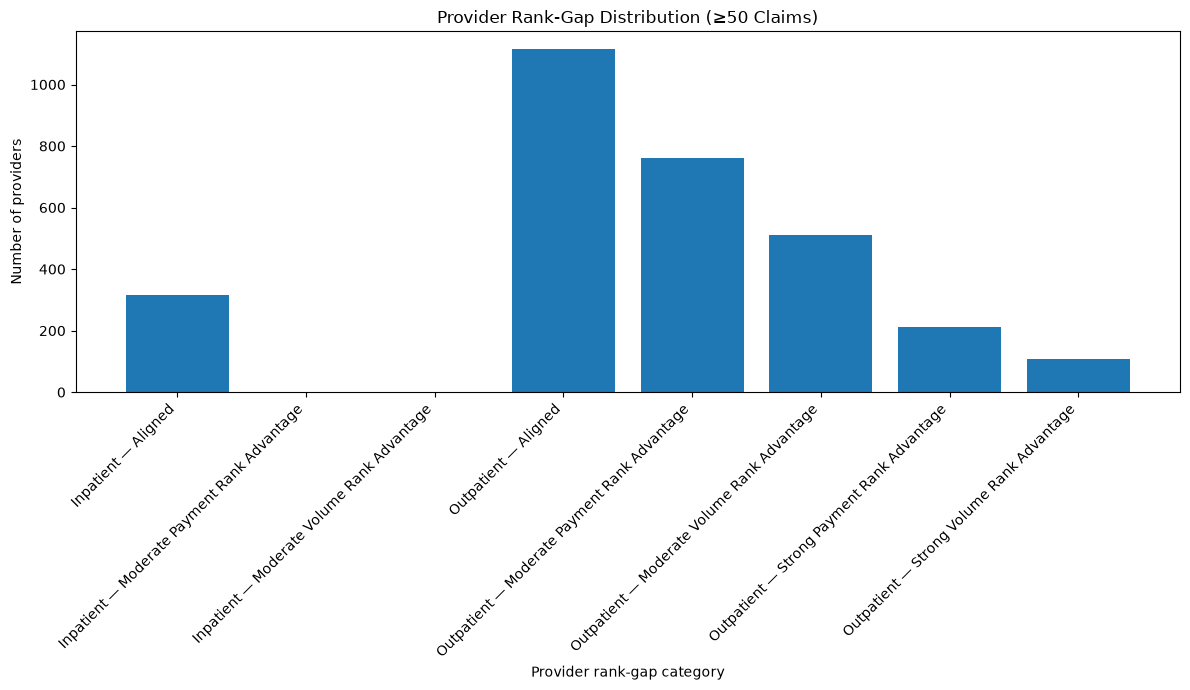

In [98]:
chart_data = provider_rank_gap_chart.copy()
chart_data["label"] = (
    chart_data["claim_type"]
    + " Ã¢â‚¬â€ "
    + chart_data["rank_gap_category"]
)
plt.figure(figsize=(12, 7))
plt.bar(
    chart_data["label"],
    chart_data["provider_count"]
)
plt.xlabel("Provider rank-gap category")
plt.ylabel("Number of providers")
plt.title("Provider Rank-Gap Distribution (Ã¢â€°Â¥50 Claims)")
plt.xticks(
    rotation=45,
    ha="right"
)
plt.tight_layout()
plt.show()

## Provider Rank-Gap Visualization Ã¢â‚¬â€ Interpretation

The chart shows the distribution of providers across volume-versus-payment
rank-gap categories among providers with at least 50 claims.

### Key Takeaways

- Inpatient providers are overwhelmingly concentrated in the **Aligned**
  category, indicating that claim volume and total payment rankings are
  generally similar.
- Outpatient providers show substantially greater variation between claim
  volume and payment rankings.
- **211 outpatient providers** show a strong payment-rank advantage, while
  **107** show a strong volume-rank advantage.
- This demonstrates that provider volume alone does not fully describe
  financial contribution.
- The difference can be influenced by payment per claim, service mix, and
  utilization characteristics.

The visualization is a descriptive profiling tool and should not be
interpreted as evidence of inappropriate billing, fraud, or payment error.

In [99]:
rank_gap_reconciliation = con.execute("""
    SELECT
        COUNT(*) AS provider_count,
        SUM(provider_count) AS category_provider_count
    FROM provider_rank_gap_summary
""").fetchdf()
display(rank_gap_reconciliation)
expected_provider_count = len(provider_rank_gap_50)
actual_provider_count = int(
    rank_gap_reconciliation.loc[0, "category_provider_count"]
)
print("Expected providers:", expected_provider_count)
print("Categorized providers:", actual_provider_count)
print(
    "Exact reconciliation:",
    expected_provider_count == actual_provider_count
)

,provider_count,category_provider_count
0,8,3026.0


Expected providers: 3026
Categorized providers: 3026
Exact reconciliation: True


In [100]:
beneficiary_financial_segments = con.execute("""
    SELECT
        CASE
            WHEN total_payment < 5000
                THEN 'Low Payment'
            WHEN total_payment < 25000
                THEN 'Moderate Payment'
            WHEN total_payment < 50000
                THEN 'High Payment'
            ELSE 'Very High Payment'
        END AS payment_segment,
        COUNT(*) AS beneficiary_count,
        SUM(claim_count) AS claim_count,
        ROUND(SUM(total_payment), 2) AS total_payment,
        ROUND(AVG(claim_count), 2) AS average_claims_per_beneficiary,
        ROUND(AVG(total_payment), 2) AS average_payment_per_beneficiary
    FROM beneficiary_summary
    GROUP BY payment_segment
    ORDER BY
        CASE payment_segment
            WHEN 'Low Payment' THEN 1
            WHEN 'Moderate Payment' THEN 2
            WHEN 'High Payment' THEN 3
            WHEN 'Very High Payment' THEN 4
        END
""").fetchdf()
display(beneficiary_financial_segments)
print("Segments:", len(beneficiary_financial_segments))
print("Beneficiaries:", beneficiary_financial_segments["beneficiary_count"].sum())
print("Claims:", beneficiary_financial_segments["claim_count"].sum())
print("Total payment:", beneficiary_financial_segments["total_payment"].sum())

,payment_segment,beneficiary_count,claim_count,total_payment,average_claims_per_beneficiary,average_payment_per_beneficiary
0,Low Payment,49191,311912.0,67923500.0,6.34,1380.81
1,Moderate Payment,28142,365415.0,335351020.0,12.98,11916.39
2,High Payment,6106,100654.0,209849540.0,16.48,34367.76
3,Very High Payment,3299,79582.0,250660830.0,24.12,75980.85


Segments: 4
Beneficiaries: 86738
Claims: 857563.0
Total payment: 863784890.0


In [101]:
beneficiary_financial_segments_path = (
    SQL_DIR / "beneficiary_financial_segments.csv"
)
beneficiary_financial_segments.to_csv(
    beneficiary_financial_segments_path,
    index=False
)
print(
    f"Saved: {beneficiary_financial_segments_path}"
)
print(
    "Rows:",
    len(beneficiary_financial_segments)
)
print(
    "Total beneficiaries:",
    int(beneficiary_financial_segments["beneficiary_count"].sum())
)
print(
    "Total claims:",
    int(beneficiary_financial_segments["claim_count"].sum())
)
print(
    "Total payment:",
    beneficiary_financial_segments["total_payment"].sum()
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\beneficiary_financial_segments.csv
Rows: 4
Total beneficiaries: 86738
Total claims: 857563
Total payment: 863784890.0


## Beneficiary Financial Segmentation Ã¢â‚¬â€ Business Interpretation

Beneficiaries were grouped into four project-defined payment segments based on
their total claim payments:

- **Low Payment:** less than Ã¢â€šÂ¹5,000
- **Moderate Payment:** Ã¢â€šÂ¹5,000 to less than Ã¢â€šÂ¹25,000
- **High Payment:** Ã¢â€šÂ¹25,000 to less than Ã¢â€šÂ¹50,000
- **Very High Payment:** Ã¢â€šÂ¹50,000 or more

### Key Findings

- 49,191 beneficiaries (56.71%) were in the Low Payment segment.
- 28,142 beneficiaries (32.44%) were in the Moderate Payment segment.
- 6,106 beneficiaries (7.04%) were in the High Payment segment.
- 3,299 beneficiaries (3.80%) were in the Very High Payment segment.
- The Very High Payment segment represented only 3.80% of beneficiaries but
  accounted for approximately 29.02% of total payments.
- Average claims per beneficiary increased progressively across payment
  segments, from 6.34 in the Low Payment segment to 24.12 in the Very High
  Payment segment.
- Average payment per beneficiary increased substantially across the segments.

### Business Interpretation

The distribution indicates that healthcare payments are concentrated among a
relatively small group of beneficiaries.

The Very High Payment segment can therefore be used as a population for
further descriptive analysis of utilization, inpatient/outpatient service mix,
diagnosis patterns, and payment concentration.

This segmentation is an analytical prioritization method only. It does not
represent clinical risk, patient severity, fraud, or inappropriate utilization.

Because CMS DE-SynPUF is synthetic data, these payment patterns should not be
generalized to the real Medicare population.

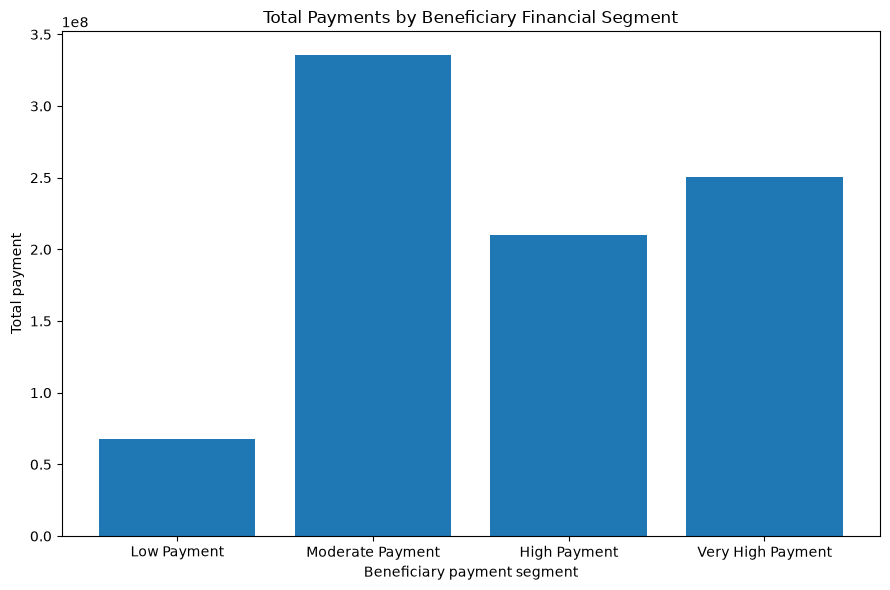

In [102]:
chart_data = beneficiary_financial_segments.copy()
plt.figure(figsize=(9, 6))
plt.bar(
    chart_data["payment_segment"],
    chart_data["total_payment"]
)
plt.xlabel("Beneficiary payment segment")
plt.ylabel("Total payment")
plt.title("Total Payments by Beneficiary Financial Segment")
plt.tight_layout()
plt.show()

## Beneficiary Financial Segmentation Ã¢â‚¬â€ Visualization Interpretation

The visualization shows a strong concentration of total payments in the
higher-payment beneficiary segments.

### Key Takeaways

- The **Low Payment** segment contains the largest number of beneficiaries,
  but contributes the smallest total payment amount.
- The **Moderate Payment** segment contributes a substantially larger share of
  total payments despite representing fewer beneficiaries.
- The **High Payment** and **Very High Payment** segments contain relatively
  few beneficiaries but account for a large proportion of total payments.
- The **Very High Payment** segment contains only 3.80% of beneficiaries but
  contributes approximately 29.02% of total payments.
- This demonstrates why beneficiary counts alone are insufficient for
  understanding healthcare financial exposure.

The segmentation is descriptive and project-defined. It should not be
interpreted as a clinical risk classification, fraud indicator, or measure of
inappropriate utilization.

Because the underlying CMS DE-SynPUF data is synthetic, these payment
concentration patterns should not be generalized to the real Medicare
population.

In [103]:
beneficiary_financial_reconciliation = con.execute("""
    SELECT
        COUNT(*) AS segment_count,
        SUM(beneficiary_count) AS segmented_beneficiaries,
        SUM(claim_count) AS segmented_claims,
        SUM(total_payment) AS segmented_payment
    FROM beneficiary_financial_segments
""").fetchdf()
display(beneficiary_financial_reconciliation)
expected_beneficiaries = len(beneficiary_summary)
expected_claims = int(beneficiary_summary["claim_count"].sum())
expected_payment = beneficiary_summary["total_payment"].sum()
actual_beneficiaries = int(
    beneficiary_financial_reconciliation.loc[
        0, "segmented_beneficiaries"
    ]
)
actual_claims = int(
    beneficiary_financial_reconciliation.loc[
        0, "segmented_claims"
    ]
)
actual_payment = float(
    beneficiary_financial_reconciliation.loc[
        0, "segmented_payment"
    ]
)
print("Expected beneficiaries:", expected_beneficiaries)
print("Segmented beneficiaries:", actual_beneficiaries)
print("Expected claims:", expected_claims)
print("Segmented claims:", actual_claims)
print("Expected payment:", expected_payment)
print("Segmented payment:", actual_payment)
print(
    "Exact beneficiary reconciliation:",
    expected_beneficiaries == actual_beneficiaries
)
print(
    "Exact claim reconciliation:",
    expected_claims == actual_claims
)
print(
    "Exact payment reconciliation:",
    expected_payment == actual_payment
)

,segment_count,segmented_beneficiaries,segmented_claims,segmented_payment
0,4,86738.0,857563.0,863784890.0


Expected beneficiaries: 86738
Segmented beneficiaries: 86738
Expected claims: 857563
Segmented claims: 857563
Expected payment: 863784890.0
Segmented payment: 863784890.0
Exact beneficiary reconciliation: True
Exact claim reconciliation: True
Exact payment reconciliation: True


In [104]:
beneficiary_financial_mix = beneficiary_financial_segments.copy()
total_beneficiaries = beneficiary_financial_mix[
    "beneficiary_count"
].sum()
total_claims = beneficiary_financial_mix[
    "claim_count"
].sum()
total_payment = beneficiary_financial_mix[
    "total_payment"
].sum()
beneficiary_financial_mix["beneficiary_share_pct"] = (
    beneficiary_financial_mix["beneficiary_count"]
    / total_beneficiaries
    * 100
)
beneficiary_financial_mix["claim_share_pct"] = (
    beneficiary_financial_mix["claim_count"]
    / total_claims
    * 100
)
beneficiary_financial_mix["payment_share_pct"] = (
    beneficiary_financial_mix["total_payment"]
    / total_payment
    * 100
)
beneficiary_financial_mix[
    [
        "payment_segment",
        "beneficiary_count",
        "beneficiary_share_pct",
        "claim_count",
        "claim_share_pct",
        "total_payment",
        "payment_share_pct"
    ]
]

,payment_segment,beneficiary_count,beneficiary_share_pct,claim_count,claim_share_pct,total_payment,payment_share_pct
0,Low Payment,49191,56.712168,311912.0,36.371905,67923500.0,7.863474
1,Moderate Payment,28142,32.444834,365415.0,42.610864,335351020.0,38.823441
2,High Payment,6106,7.039590,100654.0,11.737213,209849540.0,24.294190
3,Very High Payment,3299,3.803408,79582.0,9.280018,250660830.0,29.018895


In [105]:
beneficiary_financial_mix_path = (
    SQL_DIR / "beneficiary_financial_mix.csv"
)
beneficiary_financial_mix.to_csv(
    beneficiary_financial_mix_path,
    index=False
)
print(
    f"Saved: {beneficiary_financial_mix_path}"
)
print(
    "Rows:",
    len(beneficiary_financial_mix)
)
print(
    "Beneficiary share:",
    round(
        beneficiary_financial_mix["beneficiary_share_pct"].sum(),
        4
    )
)
print(
    "Claim share:",
    round(
        beneficiary_financial_mix["claim_share_pct"].sum(),
        4
    )
)
print(
    "Payment share:",
    round(
        beneficiary_financial_mix["payment_share_pct"].sum(),
        4
    )
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\beneficiary_financial_mix.csv
Rows: 4
Beneficiary share: 100.0
Claim share: 100.0
Payment share: 100.0


## Beneficiary Financial Mix Ã¢â‚¬â€ Business Interpretation

The beneficiary financial segmentation shows a strong concentration of
healthcare payments among a relatively small proportion of beneficiaries.

### Key Findings

- The **Low Payment** segment contains 56.71% of beneficiaries but accounts
  for only 7.86% of total payments.
- The **Moderate Payment** segment contains 32.44% of beneficiaries and
  accounts for 38.82% of total payments.
- The **High Payment** segment contains 7.04% of beneficiaries but accounts
  for 24.29% of total payments.
- The **Very High Payment** segment contains only 3.80% of beneficiaries but
  accounts for 29.02% of total payments.
- The High Payment and Very High Payment segments together represent only
  10.84% of beneficiaries but account for 53.31% of total payments.

### Business Interpretation

The results indicate that beneficiary counts alone do not describe the
financial exposure of a healthcare claims population.

A relatively small group of beneficiaries accounts for a disproportionately
large share of total payments. This makes the higher-payment segments useful
for further descriptive analysis of:

- inpatient and outpatient service mix
- claim utilization
- diagnosis patterns
- provider utilization
- payment concentration
- length of stay
- payment-integrity investigation signals

These segments should be treated as **financial prioritization groups**, not
clinical risk categories.

### Analytical Limitation

The payment thresholds used in this analysis are project-defined analytical
thresholds:

- Low Payment: < Ã¢â€šÂ¹5,000
- Moderate Payment: Ã¢â€šÂ¹5,000Ã¢â‚¬â€œ< Ã¢â€šÂ¹25,000
- High Payment: Ã¢â€šÂ¹25,000Ã¢â‚¬â€œ< Ã¢â€šÂ¹50,000
- Very High Payment: Ã¢â€°Â¥ Ã¢â€šÂ¹50,000

They are not official CMS classifications or reimbursement standards.

CMS DE-SynPUF is synthetic data, so these payment concentration patterns
should not be generalized to the real Medicare population.

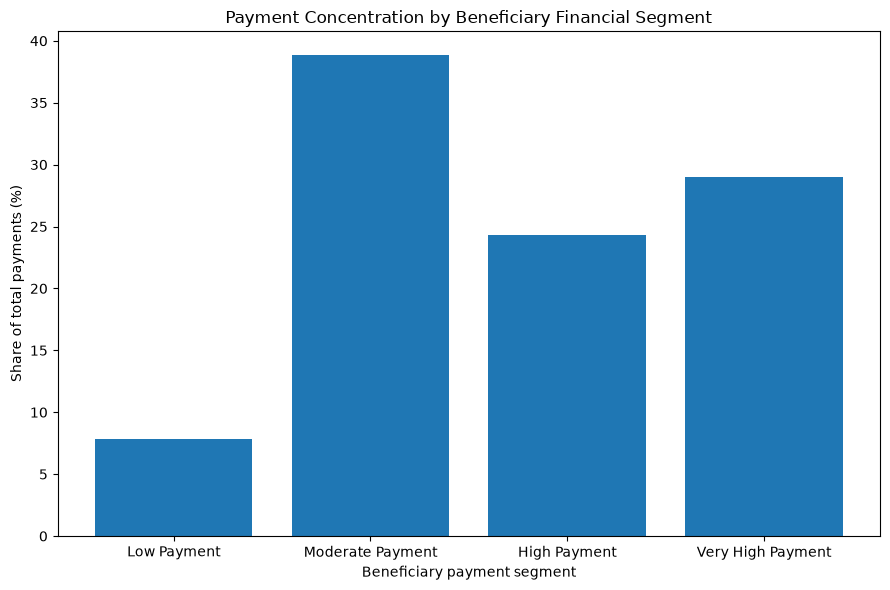

In [106]:
chart_data = beneficiary_financial_mix.copy()
plt.figure(figsize=(9, 6))
plt.bar(
    chart_data["payment_segment"],
    chart_data["payment_share_pct"]
)
plt.xlabel("Beneficiary payment segment")
plt.ylabel("Share of total payments (%)")
plt.title("Payment Concentration by Beneficiary Financial Segment")
plt.tight_layout()
plt.show()

## Beneficiary Financial Mix Ã¢â‚¬â€ Visualization Interpretation

The visualization demonstrates that healthcare payment exposure is not evenly
distributed across beneficiaries.

### Key Takeaways

- The **Low Payment** segment represents the majority of beneficiaries
  (56.71%) but contributes only 7.86% of total payments.
- The **Moderate Payment** segment contributes the largest individual share
  of total payments at 38.82%.
- The **High Payment** and **Very High Payment** segments together account for
  53.31% of total payments while representing only 10.84% of beneficiaries.
- The **Very High Payment** segment alone represents just 3.80% of
  beneficiaries but accounts for 29.02% of total payments.

### Business Interpretation

This concentration suggests that financial exposure is substantially
concentrated among higher-payment beneficiaries.

For healthcare revenue analytics, these segments can therefore support
prioritization of further analysis around utilization, service mix, provider
patterns, length of stay, and payment-integrity signals.

The visualization is descriptive and does not establish clinical risk,
medical necessity, fraud, or inappropriate utilization.

The thresholds are project-defined analytical segments and are not official
CMS classifications.

In [107]:
top_payment_beneficiaries = con.execute("""
    SELECT
        beneficiary_id,
        claim_count,
        inpatient_claims,
        outpatient_claims,
        total_payment,
        average_payment_per_claim
    FROM beneficiary_summary
    ORDER BY total_payment DESC
    LIMIT 25
""").fetchdf()
display(top_payment_beneficiaries)
print("Rows:", len(top_payment_beneficiaries))

,beneficiary_id,claim_count,inpatient_claims,outpatient_claims,total_payment,average_payment_per_claim
0,E2D39E24FCF427D5,52,9.0,43.0,244180.0,4695.77
1,CD57573A5B77AAFE,60,14.0,46.0,243890.0,4064.83
2,AEF310232161AC91,48,9.0,39.0,216480.0,4510.00
3,3A9D94388C426924,34,12.0,22.0,214020.0,6294.71
4,F8F72B475A3381DC,54,8.0,46.0,212890.0,3942.41
5,11B3642EFC2521EB,42,8.0,34.0,210420.0,5010.00
6,7E00D9D78DAA008D,30,9.0,21.0,199280.0,6642.67
7,8FBF91DCA969CB07,47,5.0,42.0,198880.0,4231.49
8,FC02104A9F15D57C,37,13.0,24.0,194930.0,5268.38
9,893882C572AC525E,48,6.0,42.0,193850.0,4038.54


Rows: 25


In [108]:
top_payment_beneficiaries_path = (
    SQL_DIR / "top_payment_beneficiaries.csv"
)
top_payment_beneficiaries.to_csv(
    top_payment_beneficiaries_path,
    index=False
)
print(
    f"Saved: {top_payment_beneficiaries_path}"
)
print("Rows:", len(top_payment_beneficiaries))
print(
    "Highest payment:",
    top_payment_beneficiaries["total_payment"].max()
)
print(
    "Highest claim count:",
    top_payment_beneficiaries["claim_count"].max()
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\top_payment_beneficiaries.csv
Rows: 25
Highest payment: 244180.0
Highest claim count: 60


In [109]:
beneficiary_payment_intensity = con.execute("""
    SELECT
        beneficiary_id,
        claim_count,
        inpatient_claims,
        outpatient_claims,
        total_payment,
        ROUND(
            total_payment / NULLIF(claim_count, 0),
            2
        ) AS payment_per_claim
    FROM beneficiary_summary
    WHERE claim_count >= 5
    ORDER BY payment_per_claim DESC
    LIMIT 25
""").fetchdf()

display(beneficiary_payment_intensity)

print("Rows:", len(beneficiary_payment_intensity))

,beneficiary_id,claim_count,inpatient_claims,outpatient_claims,total_payment,payment_per_claim
0,5FA0857576075DD2,5,3.0,2.0,136480.0,27296.00
1,A09A706AF34D7BE2,5,4.0,1.0,122000.0,24400.00
2,851DCC18E6E5A344,5,4.0,1.0,117040.0,23408.00
3,94218B2DE0A4B9F3,5,4.0,1.0,114090.0,22818.00
4,A2439711FC1AEA1D,5,5.0,0.0,113000.0,22600.00
5,A749E556441565B6,5,4.0,1.0,112100.0,22420.00
6,C092BE06E3B0CE59,7,7.0,0.0,148000.0,21142.86
7,EA2E48302CA2A0F5,5,4.0,1.0,104040.0,20808.00
8,D66CC4F9349632C4,6,5.0,1.0,118200.0,19700.00
9,14BB045B56502AEF,8,7.0,1.0,153200.0,19150.00


Rows: 25


In [110]:
beneficiary_payment_intensity_path = (
    SQL_DIR / "beneficiary_payment_intensity.csv"
)

beneficiary_payment_intensity.to_csv(
    beneficiary_payment_intensity_path,
    index=False
)

print(
    f"Saved: {beneficiary_payment_intensity_path}"
)

print("Rows:", len(beneficiary_payment_intensity))

print(
    "Highest payment per claim:",
    beneficiary_payment_intensity["payment_per_claim"].max()
)

print(
    "Minimum claim threshold:",
    beneficiary_payment_intensity["claim_count"].min()
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\beneficiary_payment_intensity.csv
Rows: 25
Highest payment per claim: 27296.0
Minimum claim threshold: 5


In [111]:
beneficiary_intensity_benchmark = con.execute("""
    SELECT
        ROUND(AVG(payment), 2) AS overall_avg_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS overall_median_payment_per_claim
    FROM claims_all
    WHERE payment IS NOT NULL
""").fetchdf()

display(beneficiary_intensity_benchmark)

benchmark = float(
    beneficiary_intensity_benchmark.loc[
        0,
        "overall_avg_payment_per_claim"
    ]
)

beneficiary_payment_intensity["vs_overall_avg_pct"] = (
    (
        beneficiary_payment_intensity["payment_per_claim"]
        - benchmark
    )
    / benchmark
    * 100
)

display(
    beneficiary_payment_intensity.head(25)
)

,overall_avg_payment_per_claim,overall_median_payment_per_claim
0,1007.26,80.0


,beneficiary_id,claim_count,inpatient_claims,outpatient_claims,total_payment,payment_per_claim,vs_overall_avg_pct
0,5FA0857576075DD2,5,3.0,2.0,136480.0,27296.00,2609.925938
1,A09A706AF34D7BE2,5,4.0,1.0,122000.0,24400.00,2322.413280
2,851DCC18E6E5A344,5,4.0,1.0,117040.0,23408.00,2223.928281
3,94218B2DE0A4B9F3,5,4.0,1.0,114090.0,22818.00,2165.353533
4,A2439711FC1AEA1D,5,5.0,0.0,113000.0,22600.00,2143.710661
5,A749E556441565B6,5,4.0,1.0,112100.0,22420.00,2125.840399
6,C092BE06E3B0CE59,7,7.0,0.0,148000.0,21142.86,1999.046919
7,EA2E48302CA2A0F5,5,4.0,1.0,104040.0,20808.00,1965.802275
8,D66CC4F9349632C4,6,5.0,1.0,118200.0,19700.00,1855.800886
9,14BB045B56502AEF,8,7.0,1.0,153200.0,19150.00,1801.197308


In [112]:
beneficiary_payment_intensity_benchmark_path = (
    SQL_DIR / "beneficiary_payment_intensity_benchmark.csv"
)

beneficiary_payment_intensity.to_csv(
    beneficiary_payment_intensity_benchmark_path,
    index=False
)

print(
    f"Saved: {beneficiary_payment_intensity_benchmark_path}"
)

print("Rows:", len(beneficiary_payment_intensity))

print(
    "Benchmark average:",
    benchmark
)

print(
    "Maximum vs-average percentage:",
    round(
        beneficiary_payment_intensity["vs_overall_avg_pct"].max(),
        2
    )
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\beneficiary_payment_intensity_benchmark.csv
Rows: 25
Benchmark average: 1007.26
Maximum vs-average percentage: 2609.93


## Beneficiary Payment Intensity Ã¢â‚¬â€ Business Interpretation

Payment per claim provides a complementary view to total beneficiary
payments. It identifies beneficiaries whose average payment per claim is
substantially higher than the overall claims benchmark.

### Benchmark

Across all claims:

- Overall average payment per claim: **Ã¢â€šÂ¹1,007.26**
- Overall median payment per claim: **Ã¢â€šÂ¹80**

The large difference between the mean and median indicates substantial
right-skew in claim payments.

### Key Findings

Among beneficiaries with at least 5 claims:

- The highest payment per claim was **Ã¢â€šÂ¹27,296**.
- The highest-intensity beneficiary was approximately **2,609.93% above the
  overall average payment per claim**.
- Several high-intensity beneficiaries had relatively few claims but high
  average payments per claim.
- Many of the highest-intensity beneficiaries had an inpatient-dominant
  service mix.

### Business Interpretation

Payment intensity helps identify beneficiaries with high financial exposure
per claim even when their total claim count is relatively modest.

This measure can complement total-payment and utilization analysis when
prioritizing populations for deeper descriptive review.

High payment intensity should **not** be interpreted as evidence of fraud,
overbilling, inappropriate care, or clinical severity. Payment differences
may reflect service mix, inpatient utilization, claim characteristics, or
other features of the synthetic dataset.

### Analytical Limitation

The overall mean is used only as a descriptive benchmark. It is not a
reimbursement standard or CMS benchmark.

The minimum threshold of 5 claims is a project-defined analytical choice
designed to reduce instability from very small claim counts.

CMS DE-SynPUF is synthetic data, so these beneficiary-level patterns should
not be generalized to the real Medicare population.

In [113]:
beneficiary_service_mix = con.execute("""
    SELECT
        beneficiary_id,
        claim_count,
        inpatient_claims,
        outpatient_claims,
        total_payment,
        ROUND(
            inpatient_claims * 100.0
            / NULLIF(claim_count, 0),
            2
        ) AS inpatient_claim_share_pct,
        ROUND(
            outpatient_claims * 100.0
            / NULLIF(claim_count, 0),
            2
        ) AS outpatient_claim_share_pct,
        ROUND(
            inpatient_claims * 1.0
            / NULLIF(outpatient_claims, 0),
            2
        ) AS inpatient_to_outpatient_ratio
    FROM beneficiary_summary
    WHERE claim_count >= 5
    ORDER BY total_payment DESC
""").fetchdf()

display(beneficiary_service_mix.head(25))

print("Rows:", len(beneficiary_service_mix))

,beneficiary_id,claim_count,inpatient_claims,outpatient_claims,total_payment,inpatient_claim_share_pct,outpatient_claim_share_pct,inpatient_to_outpatient_ratio
0,E2D39E24FCF427D5,52,9.0,43.0,244180.0,17.31,82.69,0.21
1,CD57573A5B77AAFE,60,14.0,46.0,243890.0,23.33,76.67,0.30
2,AEF310232161AC91,48,9.0,39.0,216480.0,18.75,81.25,0.23
3,3A9D94388C426924,34,12.0,22.0,214020.0,35.29,64.71,0.55
4,F8F72B475A3381DC,54,8.0,46.0,212890.0,14.81,85.19,0.17
5,11B3642EFC2521EB,42,8.0,34.0,210420.0,19.05,80.95,0.24
6,7E00D9D78DAA008D,30,9.0,21.0,199280.0,30.00,70.00,0.43
7,8FBF91DCA969CB07,47,5.0,42.0,198880.0,10.64,89.36,0.12
8,FC02104A9F15D57C,37,13.0,24.0,194930.0,35.14,64.86,0.54
9,893882C572AC525E,48,6.0,42.0,193850.0,12.50,87.50,0.14


Rows: 56382


In [114]:
beneficiary_service_mix_path = (
    SQL_DIR / "beneficiary_service_mix.csv"
)

beneficiary_service_mix.to_csv(
    beneficiary_service_mix_path,
    index=False
)

print(f"Saved: {beneficiary_service_mix_path}")
print("Rows:", len(beneficiary_service_mix))
print(
    "Beneficiaries with >=5 claims:",
    len(beneficiary_service_mix)
)

print(
    "Inpatient-dominant beneficiaries:",
    (
        beneficiary_service_mix["inpatient_claim_share_pct"] >= 50
    ).sum()
)

print(
    "Outpatient-dominant beneficiaries:",
    (
        beneficiary_service_mix["outpatient_claim_share_pct"] >= 75
    ).sum()
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\beneficiary_service_mix.csv
Rows: 56382
Beneficiaries with >=5 claims: 56382
Inpatient-dominant beneficiaries: 616
Outpatient-dominant beneficiaries: 52957


In [115]:
beneficiary_service_mix_summary = con.execute("""
    SELECT
        CASE
            WHEN inpatient_claim_share_pct >= 50
                THEN 'Inpatient-dominant'
            WHEN outpatient_claim_share_pct >= 75
                THEN 'Outpatient-dominant'
            ELSE 'Mixed'
        END AS service_mix,
        COUNT(*) AS beneficiaries,
        SUM(claim_count) AS total_claims,
        ROUND(SUM(total_payment), 2) AS total_payment,
        ROUND(AVG(claim_count), 2) AS avg_claims_per_beneficiary,
        ROUND(AVG(total_payment), 2) AS avg_payment_per_beneficiary
    FROM beneficiary_service_mix
    GROUP BY 1
    ORDER BY total_payment DESC
""").fetchdf()

display(beneficiary_service_mix_summary)

print("Total beneficiaries:", beneficiary_service_mix_summary["beneficiaries"].sum())
print("Total claims:", beneficiary_service_mix_summary["total_claims"].sum())
print("Total payment:", beneficiary_service_mix_summary["total_payment"].sum())

,service_mix,beneficiaries,total_claims,total_payment,avg_claims_per_beneficiary,avg_payment_per_beneficiary
0,Outpatient-dominant,52957,755718.0,632274550.0,14.27,11939.40
1,Mixed,2809,29457.0,99530820.0,10.49,35432.83
2,Inpatient-dominant,616,4274.0,27997240.0,6.94,45450.06


Total beneficiaries: 56382
Total claims: 789449.0
Total payment: 759802610.0


In [116]:
beneficiary_service_mix_summary["beneficiary_share_pct"] = (
    beneficiary_service_mix_summary["beneficiaries"]
    / beneficiary_service_mix_summary["beneficiaries"].sum()
    * 100
).round(2)

beneficiary_service_mix_summary["claim_share_pct"] = (
    beneficiary_service_mix_summary["total_claims"]
    / beneficiary_service_mix_summary["total_claims"].sum()
    * 100
).round(2)

beneficiary_service_mix_summary["payment_share_pct"] = (
    beneficiary_service_mix_summary["total_payment"]
    / beneficiary_service_mix_summary["total_payment"].sum()
    * 100
).round(2)

display(beneficiary_service_mix_summary)

print(
    "Beneficiary share total:",
    beneficiary_service_mix_summary["beneficiary_share_pct"].sum()
)

print(
    "Claim share total:",
    beneficiary_service_mix_summary["claim_share_pct"].sum()
)

print(
    "Payment share total:",
    beneficiary_service_mix_summary["payment_share_pct"].sum()
)

,service_mix,beneficiaries,total_claims,total_payment,avg_claims_per_beneficiary,avg_payment_per_beneficiary,beneficiary_share_pct,claim_share_pct,payment_share_pct
0,Outpatient-dominant,52957,755718.0,632274550.0,14.27,11939.40,93.93,95.73,83.22
1,Mixed,2809,29457.0,99530820.0,10.49,35432.83,4.98,3.73,13.10
2,Inpatient-dominant,616,4274.0,27997240.0,6.94,45450.06,1.09,0.54,3.68


Beneficiary share total: 100.00000000000001
Claim share total: 100.00000000000001
Payment share total: 100.0


In [117]:
beneficiary_service_mix_summary_path = (
    SQL_DIR / "beneficiary_service_mix_summary.csv"
)

beneficiary_service_mix_summary.to_csv(
    beneficiary_service_mix_summary_path,
    index=False
)

print(f"Saved: {beneficiary_service_mix_summary_path}")
print("Rows:", len(beneficiary_service_mix_summary))

print(
    "Payment share total:",
    beneficiary_service_mix_summary["payment_share_pct"].sum()
)

print(
    "Highest payment-share segment:",
    beneficiary_service_mix_summary.loc[
        beneficiary_service_mix_summary["payment_share_pct"].idxmax(),
        "service_mix"
    ]
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\beneficiary_service_mix_summary.csv
Rows: 3
Payment share total: 100.0
Highest payment-share segment: Outpatient-dominant


## Beneficiary Service-Mix Ã¢â‚¬â€ Business Interpretation

Among beneficiaries with at least 5 claims, outpatient services dominate the
observed claim volume and payment distribution.

### Key Findings

- **Outpatient-dominant:** 52,957 beneficiaries (93.93%), representing
  95.73% of claims and 83.22% of payments.
- **Mixed:** 2,809 beneficiaries (4.98%), representing 3.73% of claims but
  13.10% of payments.
- **Inpatient-dominant:** 616 beneficiaries (1.09%), representing only
  0.54% of claims but 3.68% of payments.

The inpatient-dominant group has the highest average payment per beneficiary
at approximately **Ã¢â€šÂ¹45,450**, compared with approximately **Ã¢â€šÂ¹11,939** for the
outpatient-dominant group.

### Business Interpretation

Claim volume is strongly concentrated among outpatient-dominant beneficiaries,
but the financial intensity of beneficiaries differs substantially by service
mix.

The relatively small mixed and inpatient-dominant groups have higher average
payments per beneficiary and therefore may warrant additional descriptive
financial analysis.

This demonstrates why healthcare revenue analytics should evaluate both
**utilization volume and financial intensity**, rather than relying on claim
counts alone.

### Analytical Limitation

Service-mix categories are based on **claim counts**, not clinical severity
or medical necessity.

The Ã¢â€°Â¥5-claim threshold and the 50% / 75% category boundaries are
project-defined analytical rules.

These results describe the synthetic DE-SynPUF Sample 1 dataset and should
not be interpreted as representative of the real Medicare population.

In [118]:
provider_financial_intensity = con.execute("""
    SELECT
        provider_id,
        claim_type,
        claim_count,
        total_payment,
        ROUND(
            total_payment / NULLIF(claim_count, 0),
            2
        ) AS payment_per_claim
    FROM provider_financial_summary
    WHERE claim_count >= 50
    ORDER BY payment_per_claim DESC
""").fetchdf()

display(provider_financial_intensity.head(25))

print("Rows:", len(provider_financial_intensity))
print(
    "Providers with >=50 claims:",
    provider_financial_intensity["provider_id"].nunique()
)

,provider_id,claim_type,claim_count,total_payment,payment_per_claim
0,1500KD,Inpatient,57,816000.0,14315.79
1,3600VA,Inpatient,50,668000.0,13360.00
2,3100GR,Inpatient,56,727000.0,12982.14
3,10S0NQ,Inpatient,52,657000.0,12634.62
4,33038A,Inpatient,73,885600.0,12131.51
5,0600PR,Inpatient,79,955000.0,12088.61
6,0506TS,Inpatient,55,650000.0,11818.18
7,67006C,Inpatient,58,683000.0,11775.86
8,2801QQ,Inpatient,62,727000.0,11725.81
9,3302VG,Inpatient,210,2444600.0,11640.95


Rows: 3026
Providers with >=50 claims: 2782


In [119]:
provider_intensity_benchmark = con.execute("""
    WITH provider_data AS (
        SELECT
            provider_id,
            claim_type,
            claim_count,
            total_payment,
            payment_per_claim
        FROM provider_financial_intensity
    ),

    type_benchmarks AS (
        SELECT
            claim_type,
            ROUND(
                SUM(total_payment) / NULLIF(SUM(claim_count), 0),
                2
            ) AS claim_type_avg_payment
        FROM provider_data
        GROUP BY claim_type
    )

    SELECT
        p.provider_id,
        p.claim_type,
        p.claim_count,
        p.total_payment,
        p.payment_per_claim,
        b.claim_type_avg_payment,
        ROUND(
            (
                p.payment_per_claim
                - b.claim_type_avg_payment
            )
            / NULLIF(b.claim_type_avg_payment, 0)
            * 100,
            2
        ) AS vs_type_average_pct
    FROM provider_data p
    JOIN type_benchmarks b
        ON p.claim_type = b.claim_type
    ORDER BY vs_type_average_pct DESC
""").fetchdf()

display(provider_intensity_benchmark.head(25))

print("Rows:", len(provider_intensity_benchmark))

,provider_id,claim_type,claim_count,total_payment,payment_per_claim,claim_type_avg_payment,vs_type_average_pct
0,17138K,Outpatient,64,49470.0,772.97,284.68,171.52
1,1113YJ,Outpatient,119,88180.0,741.01,284.68,160.30
2,2939KV,Outpatient,50,36320.0,726.40,284.68,155.16
3,4913HH,Outpatient,73,52950.0,725.34,284.68,154.79
4,4502DJ,Outpatient,164,114520.0,698.29,284.68,145.29
5,0100JS,Outpatient,54,37110.0,687.22,284.68,141.40
6,1813DJ,Outpatient,55,36900.0,670.91,284.68,135.67
7,3701JR,Outpatient,52,34380.0,661.15,284.68,132.24
8,2313NG,Outpatient,81,52410.0,647.04,284.68,127.29
9,1413GM,Outpatient,125,80860.0,646.88,284.68,127.23


Rows: 3026


In [120]:
provider_intensity_benchmark["intensity_band"] = pd.cut(
    provider_intensity_benchmark["vs_type_average_pct"],
    bins=[-float("inf"), -10, 10, 25, float("inf")],
    labels=[
        "Below Average",
        "Near Average",
        "Above Average",
        "High Intensity"
    ],
    right=True
)

provider_intensity_summary = (
    provider_intensity_benchmark
    .groupby(
        ["claim_type", "intensity_band"],
        observed=False
    )
    .agg(
        providers=("provider_id", "count"),
        total_claims=("claim_count", "sum"),
        total_payment=("total_payment", "sum"),
        avg_payment_per_claim=("payment_per_claim", "mean")
    )
    .reset_index()
)

provider_intensity_summary["avg_payment_per_claim"] = (
    provider_intensity_summary["avg_payment_per_claim"]
    .round(2)
)

display(provider_intensity_summary)

print("Rows:", len(provider_intensity_summary))

,claim_type,intensity_band,providers,total_claims,total_payment,avg_payment_per_claim
0,Inpatient,Below Average,48,4131,33770120.0,8127.78
1,Inpatient,Near Average,223,29724,283244690.0,9503.55
2,Inpatient,Above Average,42,4288,47376150.0,11068.92
3,Inpatient,High Intensity,6,367,4708600.0,12918.78
4,Outpatient,Below Average,1011,192569,44277560.0,219.09
5,Outpatient,Near Average,994,380376,107654870.0,282.23
6,Outpatient,Above Average,372,99462,32904660.0,331.77
7,Outpatient,High Intensity,330,52911,21649950.0,418.72


Rows: 8


In [121]:
provider_intensity_benchmark_path = (
    SQL_DIR / "provider_intensity_benchmark.csv"
)

provider_intensity_summary_path = (
    SQL_DIR / "provider_intensity_summary.csv"
)

provider_intensity_benchmark.to_csv(
    provider_intensity_benchmark_path,
    index=False
)

provider_intensity_summary.to_csv(
    provider_intensity_summary_path,
    index=False
)

print(
    f"Saved: {provider_intensity_benchmark_path}"
)

print(
    f"Saved: {provider_intensity_summary_path}"
)

print(
    "Benchmark rows:",
    len(provider_intensity_benchmark)
)

print(
    "Summary rows:",
    len(provider_intensity_summary)
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\provider_intensity_benchmark.csv
Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\provider_intensity_summary.csv
Benchmark rows: 3026
Summary rows: 8


## Provider Payment Intensity Ã¢â‚¬â€ Business Interpretation

Provider payment intensity compares each provider's average payment per claim
with the overall average payment per claim for the same claim type.

This service-specific benchmark prevents inpatient providers from being
directly compared with outpatient providers, whose typical payment levels
are substantially different.

### Intensity Bands

Providers with at least 50 claims were classified as:

- **Below Average:** more than 10% below the claim-type average
- **Near Average:** within Ã‚Â±10% of the claim-type average
- **Above Average:** more than 10% to 25% above the average
- **High Intensity:** more than 25% above the average

### Key Findings

#### Inpatient

- 48 providers were Below Average.
- 223 were Near Average.
- 42 were Above Average.
- 6 were classified as High Intensity.

The 6 High Intensity inpatient providers generated approximately
**Ã¢â€šÂ¹4.71 million** in payments.

#### Outpatient

- 1,011 providers were Below Average.
- 994 were Near Average.
- 372 were Above Average.
- 330 were classified as High Intensity.

The 330 High Intensity outpatient providers generated approximately
**Ã¢â€šÂ¹21.65 million** in payments.

### Business Interpretation

Provider payment intensity can be used as a screening tool to identify
providers whose average claim payment differs materially from the typical
payment level for their service type.

High intensity does not necessarily indicate inappropriate billing,
overpayment, fraud, or poor performance. Differences may result from service
mix, claim characteristics, patient populations, or the synthetic structure
of the dataset.

Provider-level investigation should therefore combine payment intensity
with claim volume, utilization, diagnosis/procedure mix, payment status, and
other available claim characteristics.

### Analytical Limitation

The Ã¢â€°Â¥50-claim minimum and intensity thresholds are project-defined analytical
rules.

Provider identifiers in DE-SynPUF are synthetic and should not be interpreted
as identifiable real-world providers.

The results are descriptive and based on synthetic Medicare claims data.

In [122]:
provider_payment_concentration = con.execute("""
    WITH provider_totals AS (
        SELECT
            provider_id,
            SUM(payment) AS total_payment
        FROM claims_all
        WHERE provider_id IS NOT NULL
        GROUP BY provider_id
    ),

    ranked AS (
        SELECT
            provider_id,
            total_payment,
            ROW_NUMBER() OVER (
                ORDER BY total_payment DESC
            ) AS provider_rank,
            COUNT(*) OVER () AS total_providers,
            SUM(total_payment) OVER () AS overall_payment
        FROM provider_totals
    ),

    thresholds AS (
        SELECT 0.01 AS percentile, 'Top 1%' AS segment
        UNION ALL
        SELECT 0.05, 'Top 5%'
        UNION ALL
        SELECT 0.10, 'Top 10%'
        UNION ALL
        SELECT 0.25, 'Top 25%'
        UNION ALL
        SELECT 0.50, 'Top 50%'
    )

    SELECT
        t.segment,
        t.percentile,
        COUNT(r.provider_id) AS providers_in_segment,
        ROUND(SUM(r.total_payment), 2) AS segment_payment,
        ROUND(
            SUM(r.total_payment)
            / NULLIF(MAX(r.overall_payment), 0)
            * 100,
            2
        ) AS payment_share_pct
    FROM thresholds t
    JOIN ranked r
        ON r.provider_rank <= CEIL(
            r.total_providers * t.percentile
        )
    GROUP BY
        t.segment,
        t.percentile
    ORDER BY
        t.percentile
""").fetchdf()

display(provider_payment_concentration)

print("Rows:", len(provider_payment_concentration))

,segment,percentile,providers_in_segment,segment_payment,payment_share_pct
0,Top 1%,0.01,69,181310050.0,20.99
1,Top 5%,0.05,341,428049010.0,49.56
2,Top 10%,0.10,681,565598460.0,65.48
3,Top 25%,0.25,1701,748873030.0,86.70
4,Top 50%,0.50,3401,840157770.0,97.26


Rows: 5


In [123]:
provider_payment_concentration_path = (
    SQL_DIR / "provider_payment_concentration.csv"
)

provider_payment_concentration.to_csv(
    provider_payment_concentration_path,
    index=False
)

print(
    f"Saved: {provider_payment_concentration_path}"
)

print(
    "Rows:",
    len(provider_payment_concentration)
)

print(
    "Top 10% payment share:",
    provider_payment_concentration.loc[
        provider_payment_concentration["segment"] == "Top 10%",
        "payment_share_pct"
    ].iloc[0],
    "%"
)

print(
    "Top 25% payment share:",
    provider_payment_concentration.loc[
        provider_payment_concentration["segment"] == "Top 25%",
        "payment_share_pct"
    ].iloc[0],
    "%"
)

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\provider_payment_concentration.csv
Rows: 5
Top 10% payment share: 65.48 %
Top 25% payment share: 86.7 %


## Provider Payment Concentration Ã¢â‚¬â€ Business Interpretation

Provider payment concentration measures how much of total claim payment is
generated by the highest-payment providers.

### Key Findings

- The **top 1% of providers** account for **20.99%** of total payments.
- The **top 5%** account for **49.56%**.
- The **top 10%** account for **65.48%**.
- The **top 25%** account for **86.70%**.
- The **top 50%** account for **97.26%**.

### Business Interpretation

Payment exposure is highly concentrated among a relatively small proportion
of providers.

The top 10% of providers generate nearly two-thirds of total payments, while
the top 25% generate more than 85%.

This concentration can help healthcare revenue and claims teams prioritize
provider-level monitoring, payment reconciliation, contract review, and
financial performance analysis.

Provider concentration should be interpreted together with claim volume,
service type, payment intensity, utilization, and claim characteristics.
High payment volume alone does not indicate poor performance or inappropriate
billing.

### Analytical Limitation

The concentration analysis ranks providers by aggregate payment. It does not
measure provider quality, clinical outcomes, medical necessity, or profitability.

Provider identifiers are synthetic in DE-SynPUF, and the dataset is synthetic.
Therefore, these findings should be treated as an analytical demonstration
rather than real-world provider benchmarking.

In [124]:
provider_reconciliation = con.execute("""
    SELECT
        COUNT(*) AS provider_count,
        ROUND(SUM(total_payment), 2) AS provider_total_payment,
        ROUND(
            (SELECT SUM(payment) FROM claims_all),
            2
        ) AS claims_total_payment,
        ROUND(
            SUM(total_payment)
            - (SELECT SUM(payment) FROM claims_all),
            2
        ) AS difference
    FROM (
        SELECT
            provider_id,
            SUM(payment) AS total_payment
        FROM claims_all
        WHERE provider_id IS NOT NULL
        GROUP BY provider_id
    )
""").fetchdf()

display(provider_reconciliation)

,provider_count,provider_total_payment,claims_total_payment,difference
0,6801,863784890.0,863784890.0,0.0


## Provider Payment Reconciliation

The provider-level payment aggregation was reconciled against the complete
claims dataset.

| Metric | Result |
|---|---:|
| Unique providers | 6,801 |
| Provider-level total payment | Ã¢â€šÂ¹863,784,890 |
| Claims-level total payment | Ã¢â€šÂ¹863,784,890 |
| Reconciliation difference | Ã¢â€šÂ¹0 |

The **Ã¢â€šÂ¹0 difference** confirms that all claims with non-missing provider IDs
are fully represented in the provider-level payment aggregation.

This provides a reliable foundation for provider concentration, provider
ranking, payment intensity, and financial monitoring analyses.

In [125]:
provider_rank_gap = con.execute("""
    WITH provider_metrics AS (
        SELECT
            provider_id,
            claim_type,
            COUNT(*) AS claim_count,
            ROUND(SUM(payment), 2) AS total_payment
        FROM claims_all
        WHERE provider_id IS NOT NULL
        GROUP BY
            provider_id,
            claim_type
    ),

    ranked AS (
        SELECT
            provider_id,
            claim_type,
            claim_count,
            total_payment,

            RANK() OVER (
                PARTITION BY claim_type
                ORDER BY claim_count DESC
            ) AS volume_rank,

            RANK() OVER (
                PARTITION BY claim_type
                ORDER BY total_payment DESC
            ) AS payment_rank

        FROM provider_metrics
        WHERE claim_count >= 50
    )

    SELECT
        provider_id,
        claim_type,
        claim_count,
        total_payment,
        volume_rank,
        payment_rank,

        volume_rank - payment_rank AS rank_gap,

        CASE
            WHEN volume_rank - payment_rank >= 25
                THEN 'Payment Rank Advantage'
            WHEN volume_rank - payment_rank <= -25
                THEN 'Volume Rank Advantage'
            ELSE 'Aligned'
        END AS rank_relationship

    FROM ranked
    ORDER BY
        rank_gap DESC
""").fetchdf()

display(provider_rank_gap)

print("Rows:", len(provider_rank_gap))

,provider_id,claim_type,claim_count,total_payment,volume_rank,payment_rank,rank_gap,rank_relationship
0,2939KV,Outpatient,50,36320.0,2680,1302,1378,Payment Rank Advantage
1,17138K,Outpatient,64,49470.0,2273,993,1280,Payment Rank Advantage
2,0100JS,Outpatient,54,37110.0,2550,1282,1268,Payment Rank Advantage
3,3701JR,Outpatient,52,34380.0,2613,1366,1247,Payment Rank Advantage
4,1813DJ,Outpatient,55,36900.0,2528,1283,1245,Payment Rank Advantage
...,...,...,...,...,...,...,...,...
3021,1100VG,Outpatient,151,23480.0,1130,1872,-742,Volume Rank Advantage
3022,3100JU,Outpatient,93,13820.0,1696,2474,-778,Volume Rank Advantage
3023,1102UR,Outpatient,123,19110.0,1341,2149,-808,Volume Rank Advantage
3024,1613NU,Outpatient,91,10460.0,1735,2643,-908,Volume Rank Advantage


Rows: 3026


In [126]:
provider_rank_gap_summary = con.execute("""
    SELECT
        claim_type,
        rank_relationship,
        COUNT(*) AS provider_count,
        ROUND(AVG(rank_gap), 2) AS average_rank_gap,
        ROUND(AVG(claim_count), 2) AS average_claim_count,
        ROUND(SUM(total_payment), 2) AS total_payment
    FROM provider_rank_gap
    GROUP BY
        claim_type,
        rank_relationship
    ORDER BY
        claim_type,
        rank_relationship
""").fetchdf()

display(provider_rank_gap_summary)

print("Rows:", len(provider_rank_gap_summary))

,claim_type,rank_relationship,provider_count,average_rank_gap,average_claim_count,total_payment
0,Inpatient,Aligned,252,-1.21,133.93,324114040.0
1,Inpatient,Payment Rank Advantage,30,45.57,64.43,21993800.0
2,Inpatient,Volume Rank Advantage,37,-40.54,76.38,22991720.0
3,Outpatient,Aligned,431,-0.24,784.41,97070480.0
4,Outpatient,Payment Rank Advantage,1032,224.80,152.57,54860720.0
5,Outpatient,Volume Rank Advantage,1244,-199.53,184.72,54555840.0


Rows: 6


In [127]:
provider_rank_gap_summary_path = (
    SQL_DIR / "provider_rank_gap_summary.csv"
)

provider_rank_gap_summary.to_csv(
    provider_rank_gap_summary_path,
    index=False
)

print(f"Saved: {provider_rank_gap_summary_path}")
print("Rows:", len(provider_rank_gap_summary))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\provider_rank_gap_summary.csv
Rows: 6


## Provider Rank Gap Ã¢â‚¬â€ Business Interpretation

Provider rank gap compares a provider's ranking by **claim volume** with its
ranking by **total payment**.

### Method

Only providers with at least **50 claims** were included.

- **Payment Rank Advantage:** payment rank is substantially better than
  volume rank (rank gap Ã¢â€°Â¥ 25).
- **Volume Rank Advantage:** volume rank is substantially better than
  payment rank (rank gap Ã¢â€°Â¤ -25).
- **Aligned:** the two rankings are relatively close.

### Key Findings

#### Inpatient

- 252 providers were classified as **Aligned**.
- 30 providers showed a **Payment Rank Advantage**.
- 37 providers showed a **Volume Rank Advantage**.

Inpatient provider rankings are therefore generally aligned between claim
volume and total payment.

#### Outpatient

- 431 providers were **Aligned**.
- 1,032 providers showed a **Payment Rank Advantage**.
- 1,244 providers showed a **Volume Rank Advantage**.

Outpatient providers show substantially greater divergence between claim
volume and total payment rankings.

### Business Interpretation

A provider with a payment rank substantially higher than its volume rank may
have a relatively higher payment per claim. Conversely, a provider with a
stronger volume rank than payment rank may generate many claims with
relatively lower payments per claim.

This analysis can help revenue and claims teams prioritize providers for
further review of service mix, payment intensity, utilization, and contract
patterns.

### Limitation

A rank gap is a **screening metric**, not evidence of inappropriate billing,
fraud, overpayment, or poor provider performance.

The threshold of 50 claims and rank-gap thresholds are project-defined.
Provider identifiers are synthetic, and the underlying DE-SynPUF data is
synthetic.

In [128]:
display(monthly_financial_trend)
print("Rows:", len(monthly_financial_trend))
print("Columns:", list(monthly_financial_trend.columns))

,claim_month,claim_type,claim_count,unique_beneficiaries,unique_providers,total_payment,average_payment_per_claim,median_payment_per_claim
0,2007-11-01,Inpatient,2,2,2,65000.0,32500.00,32500.0
1,2007-12-01,Inpatient,222,212,187,2705000.0,12184.68,8000.0
2,2007-12-01,Outpatient,312,292,263,265120.0,849.74,250.0
3,2008-01-01,Inpatient,1535,1373,788,14510480.0,9453.08,7000.0
4,2008-01-01,Outpatient,10256,8181,2778,2808150.0,273.81,70.0
...,...,...,...,...,...,...,...,...
70,2010-10-01,Outpatient,9461,7850,2777,2610450.0,275.92,80.0
71,2010-11-01,Inpatient,398,387,308,4147500.0,10420.85,8000.0
72,2010-11-01,Outpatient,8007,6678,2527,2247200.0,280.65,80.0
73,2010-12-01,Inpatient,257,257,216,2329700.0,9064.98,6000.0


Rows: 75
Columns: ['claim_month', 'claim_type', 'claim_count', 'unique_beneficiaries', 'unique_providers', 'total_payment', 'average_payment_per_claim', 'median_payment_per_claim']


In [129]:
monthly_coverage = con.execute("""
    SELECT
        MIN(DATE_TRUNC('month', claim_from_date)) AS first_claim_month,
        MAX(DATE_TRUNC('month', claim_from_date)) AS last_claim_month,
        COUNT(
            DISTINCT DATE_TRUNC('month', claim_from_date)
        ) AS distinct_months,
        COUNT(DISTINCT claim_type) AS claim_types
    FROM claims_all
    WHERE claim_from_date IS NOT NULL
""").fetchdf()

display(monthly_coverage)

print("Expected claim types: 2")
print(
    "Claim types found:",
    monthly_coverage["claim_types"].iloc[0]
)

,first_claim_month,last_claim_month,distinct_months,claim_types
0,2007-11-01,2010-12-01,38,2


Expected claim types: 2
Claim types found: 2


In [130]:
monthly_gaps = con.execute("""
    WITH months AS (
        SELECT DISTINCT
            DATE_TRUNC('month', claim_from_date) AS claim_month
        FROM claims_all
        WHERE claim_from_date IS NOT NULL
    ),

    calendar AS (
        SELECT
            month_start
        FROM generate_series(
            DATE '2007-11-01',
            DATE '2010-12-01',
            INTERVAL '1 month'
        ) AS t(month_start)
    )

    SELECT
        month_start AS missing_month
    FROM calendar
    LEFT JOIN months
        ON calendar.month_start = months.claim_month
    WHERE months.claim_month IS NULL
    ORDER BY month_start
""").fetchdf()

display(monthly_gaps)

print("Missing months:", len(monthly_gaps))

,missing_month


Missing months: 0


In [131]:
monthly_combined = con.execute("""
    SELECT
        DATE_TRUNC('month', claim_from_date) AS claim_month,

        COUNT(*) AS claim_count,

        COUNT(DISTINCT beneficiary_id)
            AS unique_beneficiaries,

        COUNT(DISTINCT provider_id)
            AS unique_providers,

        ROUND(SUM(payment), 2)
            AS total_payment,

        ROUND(AVG(payment), 2)
            AS average_payment_per_claim,

        ROUND(
            SUM(
                CASE
                    WHEN claim_type = 'Inpatient'
                    THEN 1
                    ELSE 0
                END
            ),
            0
        ) AS inpatient_claims,

        ROUND(
            SUM(
                CASE
                    WHEN claim_type = 'Outpatient'
                    THEN 1
                    ELSE 0
                END
            ),
            0
        ) AS outpatient_claims,

        ROUND(
            SUM(
                CASE
                    WHEN claim_type = 'Inpatient'
                    THEN payment
                    ELSE 0
                END
            ),
            2
        ) AS inpatient_payment,

        ROUND(
            SUM(
                CASE
                    WHEN claim_type = 'Outpatient'
                    THEN payment
                    ELSE 0
                END
            ),
            2
        ) AS outpatient_payment

    FROM claims_all
    WHERE claim_from_date IS NOT NULL
    GROUP BY
        DATE_TRUNC('month', claim_from_date)
    ORDER BY
        claim_month
""").fetchdf()

display(monthly_combined)

print("Rows:", len(monthly_combined))
print("Columns:", list(monthly_combined.columns))

,claim_month,claim_count,unique_beneficiaries,unique_providers,total_payment,average_payment_per_claim,inpatient_claims,outpatient_claims,inpatient_payment,outpatient_payment
0,2007-11-01,2,2,2,65000.0,32500.00,2.0,0.0,65000.0,0.0
1,2007-12-01,534,502,435,2970120.0,5562.02,222.0,312.0,2705000.0,265120.0
2,2008-01-01,11791,9197,3141,17318630.0,1468.80,1535.0,10256.0,14510480.0,2808150.0
3,2008-02-01,17187,13008,3622,20382330.0,1185.92,1804.0,15383.0,16260110.0,4122220.0
4,2008-03-01,23352,17361,4011,26172380.0,1120.78,2301.0,21051.0,20918530.0,5253850.0
5,2008-04-01,25479,18863,4203,27633010.0,1084.54,2315.0,23164.0,21652870.0,5980140.0
6,2008-05-01,27505,20213,4309,30676160.0,1115.29,2587.0,24918.0,24263340.0,6412820.0
7,2008-06-01,27516,20475,4298,29475680.0,1071.22,2453.0,25063.0,23039910.0,6435770.0
8,2008-07-01,28884,21364,4358,29649550.0,1026.50,2470.0,26414.0,22948390.0,6701160.0
9,2008-08-01,29789,22103,4400,30816580.0,1034.50,2586.0,27203.0,23900310.0,6916270.0


Rows: 38
Columns: ['claim_month', 'claim_count', 'unique_beneficiaries', 'unique_providers', 'total_payment', 'average_payment_per_claim', 'inpatient_claims', 'outpatient_claims', 'inpatient_payment', 'outpatient_payment']


In [132]:
monthly_reconciliation = monthly_combined[
    [
        "claim_month",
        "total_payment",
        "inpatient_payment",
        "outpatient_payment"
    ]
].copy()

monthly_reconciliation["calculated_total"] = (
    monthly_reconciliation["inpatient_payment"]
    + monthly_reconciliation["outpatient_payment"]
)

monthly_reconciliation["difference"] = (
    monthly_reconciliation["total_payment"]
    - monthly_reconciliation["calculated_total"]
)

display(
    monthly_reconciliation[
        monthly_reconciliation["difference"] != 0
    ]
)

print(
    "Months checked:",
    len(monthly_reconciliation)
)

print(
    "Months with reconciliation differences:",
    (
        monthly_reconciliation["difference"] != 0
    ).sum()
)

print(
    "Maximum absolute difference:",
    monthly_reconciliation["difference"].abs().max()
)

,claim_month,total_payment,inpatient_payment,outpatient_payment,calculated_total,difference


Months checked: 38
Months with reconciliation differences: 0
Maximum absolute difference: 0.0


In [133]:
monthly_combined_path = (
    SQL_DIR / "monthly_combined_trend.csv"
)

monthly_combined.to_csv(
    monthly_combined_path,
    index=False
)

print(f"Saved: {monthly_combined_path}")
print("Rows:", len(monthly_combined))
print("Columns:", len(monthly_combined.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\monthly_combined_trend.csv
Rows: 38
Columns: 10


In [134]:
monthly_change = con.execute("""
    WITH monthly AS (
        SELECT
            DATE_TRUNC('month', claim_from_date) AS claim_month,
            COUNT(*) AS claim_count,
            ROUND(SUM(payment), 2) AS total_payment
        FROM claims_all
        WHERE claim_from_date IS NOT NULL
        GROUP BY
            DATE_TRUNC('month', claim_from_date)
    )

    SELECT
        claim_month,
        claim_count,
        total_payment,

        LAG(claim_count) OVER (
            ORDER BY claim_month
        ) AS previous_month_claims,

        LAG(total_payment) OVER (
            ORDER BY claim_month
        ) AS previous_month_payment,

        ROUND(
            (
                claim_count
                - LAG(claim_count) OVER (
                    ORDER BY claim_month
                )
            )
            * 100.0
            / NULLIF(
                LAG(claim_count) OVER (
                    ORDER BY claim_month
                ),
                0
            ),
            2
        ) AS claims_mom_change_pct,

        ROUND(
            (
                total_payment
                - LAG(total_payment) OVER (
                    ORDER BY claim_month
                )
            )
            * 100.0
            / NULLIF(
                LAG(total_payment) OVER (
                    ORDER BY claim_month
                ),
                0
            ),
            2
        ) AS payment_mom_change_pct

    FROM monthly
    ORDER BY claim_month
""").fetchdf()

display(monthly_change)

print("Rows:", len(monthly_change))
print("Columns:", list(monthly_change.columns))

,claim_month,claim_count,total_payment,previous_month_claims,previous_month_payment,claims_mom_change_pct,payment_mom_change_pct
0,2007-11-01,2,65000.0,<NA>,NaN,NaN,NaN
1,2007-12-01,534,2970120.0,2,65000.0,26600.00,4469.42
2,2008-01-01,11791,17318630.0,534,2970120.0,2108.05,483.10
3,2008-02-01,17187,20382330.0,11791,17318630.0,45.76,17.69
4,2008-03-01,23352,26172380.0,17187,20382330.0,35.87,28.41
5,2008-04-01,25479,27633010.0,23352,26172380.0,9.11,5.58
6,2008-05-01,27505,30676160.0,25479,27633010.0,7.95,11.01
7,2008-06-01,27516,29475680.0,27505,30676160.0,0.04,-3.91
8,2008-07-01,28884,29649550.0,27516,29475680.0,4.97,0.59
9,2008-08-01,29789,30816580.0,28884,29649550.0,3.13,3.94


Rows: 38
Columns: ['claim_month', 'claim_count', 'total_payment', 'previous_month_claims', 'previous_month_payment', 'claims_mom_change_pct', 'payment_mom_change_pct']


In [135]:
meaningful_mom_changes = monthly_change[
    monthly_change["claim_month"] >= "2008-02-01"
].copy()

top_claim_increases = (
    meaningful_mom_changes
    .nlargest(5, "claims_mom_change_pct")
    [
        [
            "claim_month",
            "claim_count",
            "claims_mom_change_pct",
            "payment_mom_change_pct"
        ]
    ]
)

top_claim_decreases = (
    meaningful_mom_changes
    .nsmallest(5, "claims_mom_change_pct")
    [
        [
            "claim_month",
            "claim_count",
            "claims_mom_change_pct",
            "payment_mom_change_pct"
        ]
    ]
)

top_payment_increases = (
    meaningful_mom_changes
    .nlargest(5, "payment_mom_change_pct")
    [
        [
            "claim_month",
            "total_payment",
            "claims_mom_change_pct",
            "payment_mom_change_pct"
        ]
    ]
)

top_payment_decreases = (
    meaningful_mom_changes
    .nsmallest(5, "payment_mom_change_pct")
    [
        [
            "claim_month",
            "total_payment",
            "claims_mom_change_pct",
            "payment_mom_change_pct"
        ]
    ]
)

print("Top 5 claim-volume increases:")
display(top_claim_increases)

print("Top 5 claim-volume decreases:")
display(top_claim_decreases)

print("Top 5 payment increases:")
display(top_payment_increases)

print("Top 5 payment decreases:")
display(top_payment_decreases)

Top 5 claim-volume increases:


,claim_month,claim_count,claims_mom_change_pct,payment_mom_change_pct
3,2008-02-01,17187,45.76,17.69
4,2008-03-01,23352,35.87,28.41
16,2009-03-01,30725,9.79,10.32
5,2008-04-01,25479,9.11,5.58
6,2008-05-01,27505,7.95,11.01


Top 5 claim-volume decreases:


,claim_month,claim_count,claims_mom_change_pct,payment_mom_change_pct
36,2010-11-01,8405,-16.67,-24.40
37,2010-12-01,7069,-15.90,-36.75
27,2010-02-01,20799,-14.68,-17.51
34,2010-09-01,11644,-13.82,-16.42
35,2010-10-01,10087,-13.37,-27.46


Top 5 payment increases:


,claim_month,total_payment,claims_mom_change_pct,payment_mom_change_pct
4,2008-03-01,26172380.0,35.87,28.41
3,2008-02-01,20382330.0,45.76,17.69
6,2008-05-01,30676160.0,7.95,11.01
16,2009-03-01,29725010.0,9.79,10.32
28,2010-03-01,21509610.0,4.39,8.51


Top 5 payment decreases:


,claim_month,total_payment,claims_mom_change_pct,payment_mom_change_pct
37,2010-12-01,4044610.0,-15.90,-36.75
35,2010-10-01,8458450.0,-13.37,-27.46
36,2010-11-01,6394700.0,-16.67,-24.40
27,2010-02-01,19823560.0,-14.68,-17.51
34,2010-09-01,11659790.0,-13.82,-16.42


In [136]:
monthly_change_path = (
    SQL_DIR / "monthly_mom_change.csv"
)
monthly_change.to_csv(
    monthly_change_path,
    index=False
)
print(f"Saved: {monthly_change_path}")
print("Rows:", len(monthly_change))
print("Columns:", len(monthly_change.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\monthly_mom_change.csv
Rows: 38
Columns: 7


In [137]:
print("Top 5 payment increases:")

display(
    monthly_change[
        monthly_change["claim_month"] >= "2008-02-01"
    ]
    .nlargest(5, "payment_mom_change_pct")
    [
        [
            "claim_month",
            "total_payment",
            "claims_mom_change_pct",
            "payment_mom_change_pct"
        ]
    ]
)

print("\nTop 5 payment decreases:")

display(
    monthly_change[
        monthly_change["claim_month"] >= "2008-02-01"
    ]
    .nsmallest(5, "payment_mom_change_pct")
    [
        [
            "claim_month",
            "total_payment",
            "claims_mom_change_pct",
            "payment_mom_change_pct"
        ]
    ]
)

Top 5 payment increases:


,claim_month,total_payment,claims_mom_change_pct,payment_mom_change_pct
4,2008-03-01,26172380.0,35.87,28.41
3,2008-02-01,20382330.0,45.76,17.69
6,2008-05-01,30676160.0,7.95,11.01
16,2009-03-01,29725010.0,9.79,10.32
28,2010-03-01,21509610.0,4.39,8.51



Top 5 payment decreases:


,claim_month,total_payment,claims_mom_change_pct,payment_mom_change_pct
37,2010-12-01,4044610.0,-15.90,-36.75
35,2010-10-01,8458450.0,-13.37,-27.46
36,2010-11-01,6394700.0,-16.67,-24.40
27,2010-02-01,19823560.0,-14.68,-17.51
34,2010-09-01,11659790.0,-13.82,-16.42


In [138]:
monthly_payment_intensity = con.execute("""
    SELECT
        DATE_TRUNC('month', claim_from_date) AS claim_month,

        COUNT(*) AS claim_count,

        ROUND(
            SUM(payment),
            2
        ) AS total_payment,

        ROUND(
            AVG(payment),
            2
        ) AS average_payment_per_claim,

        ROUND(
            MEDIAN(payment),
            2
        ) AS median_payment_per_claim,

        ROUND(
            SUM(payment)
            / NULLIF(COUNT(*), 0),
            2
        ) AS payment_per_claim

    FROM claims_all

    WHERE claim_from_date IS NOT NULL

    GROUP BY
        DATE_TRUNC('month', claim_from_date)

    ORDER BY
        claim_month
""").fetchdf()

display(monthly_payment_intensity)

,claim_month,claim_count,total_payment,average_payment_per_claim,median_payment_per_claim,payment_per_claim
0,2007-11-01,2,65000.0,32500.00,32500.0,32500.00
1,2007-12-01,534,2970120.0,5562.02,2150.0,5562.02
2,2008-01-01,11791,17318630.0,1468.80,90.0,1468.80
3,2008-02-01,17187,20382330.0,1185.92,80.0,1185.92
4,2008-03-01,23352,26172380.0,1120.78,80.0,1120.78
5,2008-04-01,25479,27633010.0,1084.54,80.0,1084.54
6,2008-05-01,27505,30676160.0,1115.29,80.0,1115.29
7,2008-06-01,27516,29475680.0,1071.22,80.0,1071.22
8,2008-07-01,28884,29649550.0,1026.50,80.0,1026.50
9,2008-08-01,29789,30816580.0,1034.50,80.0,1034.50


In [139]:
monthly_payment_intensity["calculated_payment_per_claim"] = (
    monthly_payment_intensity["total_payment"]
    / monthly_payment_intensity["claim_count"]
)

monthly_payment_intensity["difference"] = (
    monthly_payment_intensity["payment_per_claim"]
    - monthly_payment_intensity["calculated_payment_per_claim"]
)

print(
    "Maximum absolute difference:",
    monthly_payment_intensity["difference"].abs().max()
)

print(
    "Rows with material difference (> Ã¢â€šÂ¹0.01):",
    (
        monthly_payment_intensity["difference"].abs() > 0.01
    ).sum()
)

print("\nPayment intensity range:")
print(
    "Minimum:",
    monthly_payment_intensity["payment_per_claim"].min()
)

print(
    "Maximum:",
    monthly_payment_intensity["payment_per_claim"].max()
)

Maximum absolute difference: 0.0048872638635657495
Rows with material difference (> Ã¢â€šÂ¹0.01): 0

Payment intensity range:
Minimum: 572.16
Maximum: 32500.0


In [140]:
monthly_payment_intensity_output = monthly_payment_intensity[
    [
        "claim_month",
        "claim_count",
        "total_payment",
        "average_payment_per_claim",
        "median_payment_per_claim",
        "payment_per_claim"
    ]
].copy()

monthly_payment_intensity_path = (
    SQL_DIR / "monthly_payment_intensity.csv"
)

monthly_payment_intensity_output.to_csv(
    monthly_payment_intensity_path,
    index=False
)

print(f"Saved: {monthly_payment_intensity_path}")
print("Rows:", len(monthly_payment_intensity_output))
print("Columns:", len(monthly_payment_intensity_output.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\monthly_payment_intensity.csv
Rows: 38
Columns: 6


In [141]:
diagnosis_financial_summary = con.execute("""
    SELECT
        claim_type,
        primary_diagnosis,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        ROUND(SUM(payment), 2) AS total_payment,
        ROUND(AVG(payment), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim
    FROM claims_all
    WHERE primary_diagnosis IS NOT NULL
      AND TRIM(primary_diagnosis) <> ''
    GROUP BY
        claim_type,
        primary_diagnosis
    ORDER BY
        claim_type,
        total_payment DESC
""").fetchdf()

print("Rows:", len(diagnosis_financial_summary))
print("Columns:", len(diagnosis_financial_summary.columns))

display(
    diagnosis_financial_summary.head(20)
)

Rows: 13873
Columns: 7


,claim_type,primary_diagnosis,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim
0,Inpatient,V5789,1807,1744,28421550.0,15728.58,15000.0
1,Inpatient,0389,1648,1603,24408390.0,14810.92,11000.0
2,Inpatient,41401,1675,1634,23847800.0,14237.49,11000.0
3,Inpatient,486,2453,2368,17101860.0,6971.81,6000.0
4,Inpatient,41071,1170,1135,14809630.0,12657.80,10000.0
5,Inpatient,51881,817,799,14232900.0,17420.93,12000.0
6,Inpatient,71536,1154,1132,13133020.0,11380.43,11000.0
7,Inpatient,4280,1419,1381,11069900.0,7801.20,6000.0
8,Inpatient,49121,1558,1490,9999100.0,6417.91,5000.0
9,Inpatient,5070,705,694,8624900.0,12233.90,10000.0


In [142]:
diagnosis_reconciliation = con.execute("""
    WITH diagnosis_totals AS (
        SELECT
            claim_type,
            SUM(total_payment) AS diagnosis_payment
        FROM (
            SELECT
                claim_type,
                primary_diagnosis,
                SUM(payment) AS total_payment
            FROM claims_all
            WHERE primary_diagnosis IS NOT NULL
              AND TRIM(primary_diagnosis) <> ''
            GROUP BY
                claim_type,
                primary_diagnosis
        )
        GROUP BY claim_type
    ),

    claim_totals AS (
        SELECT
            claim_type,
            SUM(payment) AS claim_payment
        FROM claims_all
        WHERE primary_diagnosis IS NOT NULL
          AND TRIM(primary_diagnosis) <> ''
        GROUP BY claim_type
    )

    SELECT
        c.claim_type,
        ROUND(c.claim_payment, 2) AS claim_level_payment,
        ROUND(d.diagnosis_payment, 2) AS diagnosis_level_payment,
        ROUND(
            c.claim_payment - d.diagnosis_payment,
            2
        ) AS reconciliation_difference
    FROM claim_totals c
    JOIN diagnosis_totals d
        ON c.claim_type = d.claim_type
    ORDER BY c.claim_type
""").fetchdf()

display(diagnosis_reconciliation)

print(
    "\nMaximum absolute reconciliation difference:",
    diagnosis_reconciliation[
        "reconciliation_difference"
    ].abs().max()
)

,claim_type,claim_level_payment,diagnosis_level_payment,reconciliation_difference
0,Inpatient,637339480.0,637339480.0,0.0
1,Outpatient,217026060.0,217026060.0,0.0



Maximum absolute reconciliation difference: 0.0


In [143]:
diagnosis_financial_path = (
    SQL_DIR / "diagnosis_financial_summary.csv"
)

diagnosis_financial_summary.to_csv(
    diagnosis_financial_path,
    index=False
)

print(f"Saved: {diagnosis_financial_path}")
print("Rows:", len(diagnosis_financial_summary))
print("Columns:", len(diagnosis_financial_summary.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\diagnosis_financial_summary.csv
Rows: 13873
Columns: 7


In [144]:
top_diagnoses_by_payment = con.execute("""
    WITH ranked AS (
        SELECT
            claim_type,
            primary_diagnosis,
            claim_count,
            unique_beneficiaries,
            total_payment,
            average_payment_per_claim,
            median_payment_per_claim,

            ROW_NUMBER() OVER (
                PARTITION BY claim_type
                ORDER BY total_payment DESC
            ) AS payment_rank

        FROM diagnosis_financial_summary
    )

    SELECT
        claim_type,
        payment_rank,
        primary_diagnosis,
        claim_count,
        unique_beneficiaries,
        total_payment,
        average_payment_per_claim,
        median_payment_per_claim
    FROM ranked
    WHERE payment_rank <= 10
    ORDER BY
        claim_type,
        payment_rank
""").fetchdf()

display(top_diagnoses_by_payment)

,claim_type,payment_rank,primary_diagnosis,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim
0,Inpatient,1,V5789,1807,1744,28421550.0,15728.58,15000.0
1,Inpatient,2,0389,1648,1603,24408390.0,14810.92,11000.0
2,Inpatient,3,41401,1675,1634,23847800.0,14237.49,11000.0
3,Inpatient,4,486,2453,2368,17101860.0,6971.81,6000.0
4,Inpatient,5,41071,1170,1135,14809630.0,12657.80,10000.0
5,Inpatient,6,51881,817,799,14232900.0,17420.93,12000.0
6,Inpatient,7,71536,1154,1132,13133020.0,11380.43,11000.0
7,Inpatient,8,4280,1419,1381,11069900.0,7801.20,6000.0
8,Inpatient,9,49121,1558,1490,9999100.0,6417.91,5000.0
9,Inpatient,10,5070,705,694,8624900.0,12233.90,10000.0


In [145]:
top_diagnoses_by_volume = con.execute("""
    WITH ranked AS (
        SELECT
            claim_type,
            primary_diagnosis,
            claim_count,
            unique_beneficiaries,
            total_payment,
            average_payment_per_claim,
            median_payment_per_claim,

            ROW_NUMBER() OVER (
                PARTITION BY claim_type
                ORDER BY
                    claim_count DESC,
                    total_payment DESC
            ) AS volume_rank

        FROM diagnosis_financial_summary
    )

    SELECT
        claim_type,
        volume_rank,
        primary_diagnosis,
        claim_count,
        unique_beneficiaries,
        total_payment,
        average_payment_per_claim,
        median_payment_per_claim
    FROM ranked
    WHERE volume_rank <= 10
    ORDER BY
        claim_type,
        volume_rank
""").fetchdf()

display(top_diagnoses_by_volume)

,claim_type,volume_rank,primary_diagnosis,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim
0,Inpatient,1,486,2453,2368,17101860.0,6971.81,6000.0
1,Inpatient,2,V5789,1807,1744,28421550.0,15728.58,15000.0
2,Inpatient,3,41401,1675,1634,23847800.0,14237.49,11000.0
3,Inpatient,4,0389,1648,1603,24408390.0,14810.92,11000.0
4,Inpatient,5,49121,1558,1490,9999100.0,6417.91,5000.0
5,Inpatient,6,4280,1419,1381,11069900.0,7801.20,6000.0
6,Inpatient,7,5990,1374,1345,7543360.0,5490.07,5000.0
7,Inpatient,8,42731,1253,1227,7781500.0,6210.30,4000.0
8,Inpatient,9,41071,1170,1135,14809630.0,12657.80,10000.0
9,Inpatient,10,71536,1154,1132,13133020.0,11380.43,11000.0


In [146]:
top_diagnosis_analysis = pd.concat(
    [
        top_diagnoses_by_payment.assign(
            ranking_type="Payment"
        ),
        top_diagnoses_by_volume.assign(
            ranking_type="Volume"
        )
    ],
    ignore_index=True
)

top_diagnosis_path = (
    SQL_DIR / "top_diagnosis_analysis.csv"
)

top_diagnosis_analysis.to_csv(
    top_diagnosis_path,
    index=False
)

print(f"Saved: {top_diagnosis_path}")
print("Rows:", len(top_diagnosis_analysis))
print("Columns:", len(top_diagnosis_analysis.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\top_diagnosis_analysis.csv
Rows: 40
Columns: 10


In [147]:
procedure_financial_summary = con.execute("""
    SELECT
        'Inpatient' AS claim_type,
        CAST(ICD9_PRCDR_CD_1 AS VARCHAR) AS procedure_code,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT DESYNPUF_ID) AS unique_beneficiaries,
        ROUND(SUM(CLM_PMT_AMT), 2) AS total_payment,
        ROUND(AVG(CLM_PMT_AMT), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(CLM_PMT_AMT), 2) AS median_payment_per_claim
    FROM inpatient_claims
    WHERE ICD9_PRCDR_CD_1 IS NOT NULL
      AND TRIM(CAST(ICD9_PRCDR_CD_1 AS VARCHAR)) <> ''
    GROUP BY
        ICD9_PRCDR_CD_1
    ORDER BY
        total_payment DESC
""").fetchdf()

print("Rows:", len(procedure_financial_summary))
print("Columns:", len(procedure_financial_summary.columns))

display(
    procedure_financial_summary.head(20)
)

Rows: 1294
Columns: 7


,claim_type,procedure_code,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim
0,Inpatient,8154,1646,1593,19140920.0,11628.75,11000.0
1,Inpatient,0066,1401,1363,18478200.0,13189.29,12000.0
2,Inpatient,9672,472,461,15643000.0,33141.95,33000.0
3,Inpatient,9904,1861,1800,13239850.0,7114.37,6000.0
4,Inpatient,3893,1424,1389,12409200.0,8714.33,8000.0
5,Inpatient,3995,1284,1215,11496690.0,8953.81,8000.0
6,Inpatient,9671,707,698,8783000.0,12422.91,12000.0
7,Inpatient,8151,678,668,7826500.0,11543.51,11000.0
8,Inpatient,3722,982,968,7029200.0,7158.04,6000.0
9,Inpatient,4516,1049,1031,6713910.0,6400.30,5000.0


In [148]:
procedure_reconciliation = con.execute("""
    WITH procedure_totals AS (
        SELECT
            SUM(CLM_PMT_AMT) AS procedure_payment
        FROM inpatient_claims
        WHERE ICD9_PRCDR_CD_1 IS NOT NULL
          AND TRIM(CAST(ICD9_PRCDR_CD_1 AS VARCHAR)) <> ''
    ),

    claim_totals AS (
        SELECT
            SUM(CLM_PMT_AMT) AS claim_payment
        FROM inpatient_claims
        WHERE ICD9_PRCDR_CD_1 IS NOT NULL
          AND TRIM(CAST(ICD9_PRCDR_CD_1 AS VARCHAR)) <> ''
    )

    SELECT
        ROUND(c.claim_payment, 2) AS claim_level_payment,
        ROUND(p.procedure_payment, 2) AS procedure_level_payment,
        ROUND(
            c.claim_payment - p.procedure_payment,
            2
        ) AS reconciliation_difference
    FROM claim_totals c
    CROSS JOIN procedure_totals p
""").fetchdf()

display(procedure_reconciliation)

print(
    "\nMaximum absolute reconciliation difference:",
    procedure_reconciliation[
        "reconciliation_difference"
    ].abs().max()
)

,claim_level_payment,procedure_level_payment,reconciliation_difference
0,457767840.0,457767840.0,0.0



Maximum absolute reconciliation difference: 0.0


In [149]:
procedure_financial_path = (
    SQL_DIR / "procedure_financial_summary.csv"
)

procedure_financial_summary.to_csv(
    procedure_financial_path,
    index=False
)

print(f"Saved: {procedure_financial_path}")
print("Rows:", len(procedure_financial_summary))
print("Columns:", len(procedure_financial_summary.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\procedure_financial_summary.csv
Rows: 1294
Columns: 7


In [150]:
hcpcs_financial_summary = con.execute("""
    SELECT
        'Outpatient' AS claim_type,
        CAST(HCPCS_CD_1 AS VARCHAR) AS hcpcs_code,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT DESYNPUF_ID) AS unique_beneficiaries,
        ROUND(SUM(CAST(CLM_PMT_AMT AS DOUBLE)), 2) AS total_payment,
        ROUND(AVG(CAST(CLM_PMT_AMT AS DOUBLE)), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(CAST(CLM_PMT_AMT AS DOUBLE)), 2) AS median_payment_per_claim
    FROM outpatient_claims
    WHERE HCPCS_CD_1 IS NOT NULL
      AND TRIM(CAST(HCPCS_CD_1 AS VARCHAR)) <> ''
    GROUP BY
        HCPCS_CD_1
    ORDER BY
        total_payment DESC
""").fetchdf()

print("Rows:", len(hcpcs_financial_summary))
print("Columns:", len(hcpcs_financial_summary.columns))

display(
    hcpcs_financial_summary.head(20)
)

Rows: 2533
Columns: 7


,claim_type,hcpcs_code,claim_count,unique_beneficiaries,total_payment,average_payment_per_claim,median_payment_per_claim
0,Outpatient,A4657,20237,2414,38757960.0,1915.20,2000.0
1,Outpatient,36415,161373,57974,26543690.0,164.49,60.0
2,Outpatient,97110,18410,15052,6164830.0,334.86,200.0
3,Outpatient,99213,31792,24248,5918100.0,186.15,70.0
4,Outpatient,99212,23658,19215,4448470.0,188.03,70.0
5,Outpatient,80053,22883,18664,4358430.0,190.47,60.0
6,Outpatient,99214,14890,12996,2878340.0,193.31,70.0
7,Outpatient,99211,11512,10340,2715300.0,235.87,70.0
8,Outpatient,80048,13866,12225,2612220.0,188.39,60.0
9,Outpatient,71020,12244,10939,2502580.0,204.39,80.0


In [151]:
hcpcs_reconciliation = con.execute("""
    WITH hcpcs_totals AS (
        SELECT
            SUM(CAST(CLM_PMT_AMT AS DOUBLE)) AS hcpcs_payment
        FROM outpatient_claims
        WHERE HCPCS_CD_1 IS NOT NULL
          AND TRIM(CAST(HCPCS_CD_1 AS VARCHAR)) <> ''
    ),

    claim_totals AS (
        SELECT
            SUM(CAST(CLM_PMT_AMT AS DOUBLE)) AS claim_payment
        FROM outpatient_claims
        WHERE HCPCS_CD_1 IS NOT NULL
          AND TRIM(CAST(HCPCS_CD_1 AS VARCHAR)) <> ''
    )

    SELECT
        ROUND(c.claim_payment, 2) AS claim_level_payment,
        ROUND(h.hcpcs_payment, 2) AS hcpcs_level_payment,
        ROUND(
            c.claim_payment - h.hcpcs_payment,
            2
        ) AS reconciliation_difference
    FROM claim_totals c
    CROSS JOIN hcpcs_totals h
""").fetchdf()

display(hcpcs_reconciliation)

print(
    "\nMaximum absolute reconciliation difference:",
    hcpcs_reconciliation[
        "reconciliation_difference"
    ].abs().max()
)

,claim_level_payment,hcpcs_level_payment,reconciliation_difference
0,171085040.0,171085040.0,0.0



Maximum absolute reconciliation difference: 0.0


In [152]:
hcpcs_financial_path = (
    SQL_DIR / "hcpcs_financial_summary.csv"
)

hcpcs_financial_summary.to_csv(
    hcpcs_financial_path,
    index=False
)

print(f"Saved: {hcpcs_financial_path}")
print("Rows:", len(hcpcs_financial_summary))
print("Columns:", len(hcpcs_financial_summary.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\hcpcs_financial_summary.csv
Rows: 2533
Columns: 7


In [153]:
payment_status_summary = con.execute("""
    SELECT
        claim_type,
        CASE
            WHEN payment > 0 THEN 'Positive Payment'
            WHEN payment = 0 THEN 'Zero Payment'
            WHEN payment < 0 THEN 'Negative Payment'
            ELSE 'Missing Payment'
        END AS payment_status,
        COUNT(*) AS claim_count,
        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,
        COUNT(DISTINCT provider_id) AS unique_providers,
        ROUND(SUM(payment), 2) AS total_payment,
        ROUND(AVG(payment), 2) AS average_payment_per_claim,
        ROUND(MEDIAN(payment), 2) AS median_payment_per_claim
    FROM claims_all
    GROUP BY
        claim_type,
        payment_status
    ORDER BY
        claim_type,
        CASE payment_status
            WHEN 'Positive Payment' THEN 1
            WHEN 'Zero Payment' THEN 2
            WHEN 'Negative Payment' THEN 3
            WHEN 'Missing Payment' THEN 4
        END
""").fetchdf()

print("Rows:", len(payment_status_summary))
print("Columns:", len(payment_status_summary.columns))

display(payment_status_summary)

Rows: 6
Columns: 8


,claim_type,payment_status,claim_count,unique_beneficiaries,unique_providers,total_payment,average_payment_per_claim,median_payment_per_claim
0,Inpatient,Positive Payment,64558,37048,2669,639293720.0,9902.63,7000.0
1,Inpatient,Zero Payment,2160,2074,974,0.0,0.00,0.0
2,Inpatient,Negative Payment,55,55,52,-33540.0,-609.82,-200.0
3,Outpatient,Positive Payment,758119,84788,6281,224605120.0,296.27,80.0
4,Outpatient,Zero Payment,30105,23298,4165,0.0,0.00,0.0
5,Outpatient,Negative Payment,2566,2508,1357,-80410.0,-31.34,-30.0


In [154]:
payment_status_path = (
    SQL_DIR / "payment_status_summary.csv"
)

payment_status_summary.to_csv(
    payment_status_path,
    index=False
)

print(f"Saved: {payment_status_path}")
print("Rows:", len(payment_status_summary))
print("Columns:", len(payment_status_summary.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\payment_status_summary.csv
Rows: 6
Columns: 8


In [155]:
negative_payment_provider_analysis = con.execute("""
    SELECT
        claim_type,
        provider_id,
        COUNT(*) AS claim_count,
        SUM(CASE WHEN payment < 0 THEN 1 ELSE 0 END) AS negative_payment_claims,
        ROUND(
            100.0 * SUM(CASE WHEN payment < 0 THEN 1 ELSE 0 END)
            / COUNT(*),
            2
        ) AS negative_payment_rate_pct,
        ROUND(
            SUM(CASE WHEN payment < 0 THEN payment ELSE 0 END),
            2
        ) AS total_negative_payment,
        ROUND(
            AVG(
                CASE
                    WHEN payment < 0 THEN payment
                    ELSE NULL
                END
            ),
            2
        ) AS average_negative_payment,
        ROUND(SUM(payment), 2) AS total_provider_payment
    FROM claims_all
    WHERE provider_id IS NOT NULL
    GROUP BY
        claim_type,
        provider_id
    HAVING COUNT(*) >= 10
       AND SUM(CASE WHEN payment < 0 THEN 1 ELSE 0 END) > 0
    ORDER BY
        negative_payment_rate_pct DESC,
        total_negative_payment ASC
""").fetchdf()

print("Rows:", len(negative_payment_provider_analysis))
print("Columns:", len(negative_payment_provider_analysis.columns))

display(
    negative_payment_provider_analysis.head(25)
)

Rows: 1384
Columns: 8


,claim_type,provider_id,claim_count,negative_payment_claims,negative_payment_rate_pct,total_negative_payment,average_negative_payment,total_provider_payment
0,Outpatient,4001BR,12,2.0,16.67,-50.0,-25.0,770.0
1,Outpatient,4000JP,19,2.0,10.53,-140.0,-70.0,6340.0
2,Outpatient,2100VB,10,1.0,10.00,-20.0,-20.0,3350.0
3,Outpatient,1426ZB,11,1.0,9.09,-80.0,-80.0,2230.0
4,Outpatient,5525HJ,22,2.0,9.09,-60.0,-30.0,2070.0
5,Outpatient,2300JR,11,1.0,9.09,-40.0,-40.0,2830.0
6,Outpatient,4025BR,11,1.0,9.09,-10.0,-10.0,910.0
7,Outpatient,18256V,11,1.0,9.09,-10.0,-10.0,490.0
8,Inpatient,2700KR,12,1.0,8.33,-200.0,-200.0,89800.0
9,Outpatient,1410DP,12,1.0,8.33,-50.0,-50.0,4340.0


In [156]:
negative_payment_screen = con.execute("""
    SELECT
        claim_type,
        provider_id,
        claim_count,
        negative_payment_claims,
        negative_payment_rate_pct,
        total_negative_payment,
        average_negative_payment,
        total_provider_payment,

        CASE
            WHEN negative_payment_rate_pct < 5
                THEN 'Low Rate'
            WHEN negative_payment_rate_pct < 10
                THEN 'Moderate Rate'
            ELSE 'High Rate'
        END AS negative_payment_rate_band,

        ROUND(
            100.0 * ABS(total_negative_payment)
            / NULLIF(ABS(total_provider_payment), 0),
            2
        ) AS negative_payment_exposure_pct

    FROM negative_payment_provider_analysis

    ORDER BY
        negative_payment_exposure_pct DESC,
        ABS(total_negative_payment) DESC
""").fetchdf()

print("Rows:", len(negative_payment_screen))
print("Columns:", len(negative_payment_screen.columns))

display(
    negative_payment_screen.head(25)
)

Rows: 1384
Columns: 10


,claim_type,provider_id,claim_count,negative_payment_claims,negative_payment_rate_pct,total_negative_payment,average_negative_payment,total_provider_payment,negative_payment_rate_band,negative_payment_exposure_pct
0,Outpatient,4001BR,12,2.0,16.67,-50.0,-25.0,770.0,High Rate,6.49
1,Outpatient,1426ZB,11,1.0,9.09,-80.0,-80.0,2230.0,Moderate Rate,3.59
2,Outpatient,2413VQ,17,1.0,5.88,-60.0,-60.0,2000.0,Moderate Rate,3.00
3,Outpatient,5525HJ,22,2.0,9.09,-60.0,-30.0,2070.0,Moderate Rate,2.90
4,Outpatient,0925BC,21,1.0,4.76,-60.0,-60.0,2100.0,Low Rate,2.86
5,Inpatient,0502XT,14,1.0,7.14,-2000.0,-2000.0,77000.0,Moderate Rate,2.60
6,Outpatient,3625MP,21,1.0,4.76,-50.0,-50.0,2090.0,Low Rate,2.39
7,Outpatient,4000JP,19,2.0,10.53,-140.0,-70.0,6340.0,High Rate,2.21
8,Outpatient,3901RH,17,1.0,5.88,-50.0,-50.0,2430.0,Moderate Rate,2.06
9,Outpatient,18256V,11,1.0,9.09,-10.0,-10.0,490.0,Moderate Rate,2.04


In [157]:
negative_payment_screen_path = (
    SQL_DIR / "negative_payment_screen.csv"
)

negative_payment_screen.to_csv(
    negative_payment_screen_path,
    index=False
)

print(f"Saved: {negative_payment_screen_path}")
print("Rows:", len(negative_payment_screen))
print("Columns:", len(negative_payment_screen.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\negative_payment_screen.csv
Rows: 1384
Columns: 10


In [158]:
final_sql_reconciliation = con.execute("""
    SELECT
        COUNT(*) AS total_claims,

        COUNT(DISTINCT beneficiary_id) AS unique_beneficiaries,

        COUNT(DISTINCT
            claim_type || '|' ||
            beneficiary_id || '|' ||
            claim_id || '|' ||
            segment
        ) AS unique_claim_keys,

        SUM(
            CASE
                WHEN claim_type = 'Inpatient' THEN 1
                ELSE 0
            END
        ) AS inpatient_claims,

        SUM(
            CASE
                WHEN claim_type = 'Outpatient' THEN 1
                ELSE 0
            END
        ) AS outpatient_claims,

        ROUND(
            SUM(
                CASE
                    WHEN claim_type = 'Inpatient'
                    THEN payment
                    ELSE 0
                END
            ),
            2
        ) AS inpatient_payment,

        ROUND(
            SUM(
                CASE
                    WHEN claim_type = 'Outpatient'
                    THEN payment
                    ELSE 0
                END
            ),
            2
        ) AS outpatient_payment,

        ROUND(SUM(payment), 2) AS total_payment,

        SUM(
            CASE
                WHEN payment < 0 THEN 1
                ELSE 0
            END
        ) AS negative_payment_claims,

        SUM(
            CASE
                WHEN payment = 0 THEN 1
                ELSE 0
            END
        ) AS zero_payment_claims,

        SUM(
            CASE
                WHEN payment IS NULL THEN 1
                ELSE 0
            END
        ) AS missing_payment_claims

    FROM claims_all
""").fetchdf()

display(final_sql_reconciliation)

,total_claims,unique_beneficiaries,unique_claim_keys,inpatient_claims,outpatient_claims,inpatient_payment,outpatient_payment,total_payment,negative_payment_claims,zero_payment_claims,missing_payment_claims
0,857563,86738,857563,66773.0,790790.0,639260180.0,224524710.0,863784890.0,2621.0,32265.0,0.0


In [159]:
final_reconciliation_path = (
    SQL_DIR / "final_sql_reconciliation.csv"
)
final_sql_reconciliation.to_csv(
    final_reconciliation_path,
    index=False
)
print(f"Saved: {final_reconciliation_path}")
print("Rows:", len(final_sql_reconciliation))
print("Columns:", len(final_sql_reconciliation.columns))

Saved: C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL\final_sql_reconciliation.csv
Rows: 1
Columns: 11


In [160]:
from pathlib import Path

sql_output_dir = Path(
    r"C:\Users\acharya\Desktop\Healthcare_Claims_Revenue_Analytics\04_SQL"
)

output_files = sorted(
    p for p in sql_output_dir.glob("*.csv")
    if p.name != "healthcare_claims_analytics.duckdb"
)

for file in output_files:
    print(f"{file.name:<50} {file.stat().st_size:,} bytes")
    
print(f"\nTotal CSV outputs: {len(output_files)}")

beneficiary_financial_mix.csv                      626 bytes
beneficiary_financial_segments.csv                 350 bytes
beneficiary_payment_intensity.csv                  1,214 bytes
beneficiary_payment_intensity_benchmark.csv        1,703 bytes
beneficiary_service_mix.csv                        2,904,011 bytes
beneficiary_service_mix_summary.csv                377 bytes
claim_payment_bands.csv                            784 bytes
claim_payment_concentration.csv                    338 bytes
claims_financial_summary.csv                       494 bytes
diagnosis_financial_summary.csv                    589,525 bytes
final_sql_reconciliation.csv                       299 bytes
hcpcs_financial_summary.csv                        106,030 bytes
inpatient_diagnosis_high_value.csv                 957 bytes
inpatient_diagnosis_payment.csv                    960 bytes
maximum_payment_patterns.csv                       331 bytes
monthly_combined_trend.csv                         3,275 bytes
mont